# risk factors for death and long hospitalisation for different nosologies
we need to split our dataset into 2: proximal fracture and distal fracture. then we need to find the risk factors and build tables and graphs. 

### first, we download everithing we need

In [6]:
#libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import re
from datetime import datetime
from scipy import stats

import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap

# setting up graphs
sns.set_style('whitegrid')
sns.set_palette('pastel')
%matplotlib inline

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)

In [58]:
!pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ----- ---------------------------------- 1.3/9.6 MB 10.3 MB/s eta 0:00:01
   ---------------- ----------------------- 3.9/9.6 MB 11.3 MB/s eta 0:00:01
   -------------------------- ------------- 6.3/9.6 MB 11.4 MB/s eta 0:00:01
   ------------------------------------- -- 8.9/9.6 MB 11.5 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 10.3 MB/s  0:00:01

   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmode


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### downloading and splitting the dataset

In [7]:
df= pd.read_excel('dataset_11351ppl_withallinformation.xlsx', engine='openpyxl')
df.head()

,ehr_case_id_dashb,ib_number_dashb,emias_id_dashb,age_dashb,facility_name_dashb,date_hosp_dashb,orit_dashb,one_prof_bed_dashb,leave_date_dashb,main_diagnosis_dashb,time_to_oper_dashb,oper_code_dashb,oper_v_tech_cel_perioda_dashb,is_oper_dashb,operations_dashb,bed_days_dashb,bed_days_orit_dashb,death_dashb,epicrisis_diagnosis_dashb,hospitalization_id,facility_id,lpu_name,last_dept_name,dept_name_list,emias_id,erz_number,birth,age,sex,ib_number,hospitalization_type,channel,input_date,leave_date,bed_days,hospitalization_result,hospitalization_outcome,transfer_flag,death_in_hospitalization,death_date_in_hospitalization,death_within_30_days,death_date_within_30_days,epicrisis_main_diagnoses,epicrisis_complication_diagnoses,epicrisis_competing_diagnoses,epicrisis_concomitant_diagnoses,cad,dad,chss,repeat_hosp_30d_info,first_operation_start_dt,first_operation_end_dt,operation_osteo_flag,operation_endoprotez_flag,other_operation_flag,operations_timeline,repeated_operations_one_hosp,repeated_operations_others_hosp_30d,repeated_operations_ambulat_30d,has_analgesics,analgesics_given_cnt,analgesics_unique_mnn_cnt,analgesics_mnn_list,has_opioids,opioids_given_cnt,opioids_unique_mnn_cnt,opioids_mnn_list,has_antibiotics,antibiotics_given_cnt,antibiotics_unique_mnn_cnt,antibiotics_mnn_list,has_anticoagulants,anticoagulants_given_cnt,anticoagulants_unique_mnn_cnt,anticoagulants_mnn_list,has_blockers,blockers_given_cnt,blockers_unique_mnn_cnt,blockers_mnn_list,has_urine_biomaterial,has_blood_biomaterial,has_wound_biomaterial,has_op_material_biomaterial,has_other_biomaterial,has_pseudomonas,has_klebsiella,has_staphylococcus,has_microorg_list,microorg_details,koe_urine,koe_urine_name_microorg_list,koe_blood,koe_blood_name_microorg_list,koe_wound,koe_wound_name_microorg_list,koe_op_material,koe_op_material_name_microorg_list,koe_others_biomaterial,koe_others_biomaterial_name_microorg_list,run_dt
0,6b97a12f-35fb-436c-8006-33ae75f4cd12,13348-2026,3.121440e+07,69,НИИ СП им. Н.В. Склифосовского,"2026-02-06 04:48:01,000",NaN,Травматолого-ортопедические,2026-02-11,S72.10,19.0,A16.03.022.006,Да,Да,2026-02-06 23:14:44 | A16.03.022.006 | Интраме...,"5,232569",NaN,Нет,NaN,6b97a12f-35fb-436c-8006-33ae75f4cd12,10394853,ГБУЗ «НИИ СП им. Н.В.Склифосовского ДЗМ»,Травматологическое отделение №2,Травматологическое отделение №2,3.121440e+07,6921280,1956-06-18,70,Ж,13348-2026,Экстренно,103,2026-02-06 04:44:55.000 +0300,2026-02-11 10:22:55.000 +0300,5,Выписан из стационара,улучшение,0,0,NaN,0,NaN,S72.10,NaN,NaN,NaN,130.0,80.0,80.0,NaN,2026-02-06 23:14:44.000 +0300,2026-02-07 00:28:38.000 +0300,1,0,0,"(2026-02-06 23:14:44, A16.03.022.006, Остеосин...",NaN,NaN,NaN,1,1,1,Кетопрофен,1,1,1,Тримеперидин,0,0,0,NaN,1,4,1,Ривароксабан,0,0,0,NaN,0,0,0,0,0,0,0,0,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,2026-06-05 14:49:29.000 +0300
1,aefa01d2-f1e4-4390-8007-ef8b3efe13d0,14197-2026,2.423619e+07,89,НИИ СП им. Н.В. Склифосовского,"2026-02-08 15:00:24,000",NaN,Травматолого-ортопедические,2026-02-19,S72.0,42.0,A16.03.063.003,Да,Да,2026-02-10 08:40:00 | A16.03.063.003 | Эндопро...,"10,6565275",NaN,Нет,NaN,aefa01d2-f1e4-4390-8007-ef8b3efe13d0,10394853,ГБУЗ «НИИ СП им. Н.В.Склифосовского ДЗМ»,Травматологическое отделение №1,Травматологическое отделение №1,2.423619e+07,16882912,1936-02-28,90,Ж,14197-2026,Экстренно,103,2026-02-08 14:56:42.000 +0300,2026-02-19 06:45:48.000 +0300,11,Выписан из стационара,улучшение,0,0,NaN,0,NaN,S72.0,NaN,NaN,NaN,130.0,80.0,80.0,NaN,2026-02-10 08:40:00.000 +0300,2026-02-10 09:05:00.000 +0300,0,1,0,"(2026-02-10 08:40:00, A16.03.063.003, Эндопрот...",NaN,NaN,NaN,1,18,1,Кетопрофен,1,1,1,Тримеперидин,1,1,1,Цефтриаксон,1,32,1,Гепарин натрия,1,1,1,Ропивакаин,0,0,0,0,0,0,0,0,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,2026-06-05 14:49:29.000 +0300
2,0c4a9172-e528-49c3-800c-dde8d2b2f99a,69155-2025,1.864118e+07,92,НИИ СП им. Н.В. Склифосовского,"2025-10-11 16:04:40,000",NaN,Травматолого-ортопедические,2025-10-16,S72.10,7.0,A16.03.022.006,Да,Да,2025-10-11 22:00:00 | A16.03.022.00

In [8]:
# correction of bed_days_dashb format
df['bed_days_dashb'] = df['bed_days_dashb'].astype(str).str.replace(',','.')
df['bed_days_dashb'] = pd.to_numeric(df['bed_days_dashb'], errors='coerce')

# data cleaning
for col in ['date_hosp_dashb', 'leave_date_dashb', 'first_operation_start_dt']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

numeric_cols = ['bed_days_dashb', 'time_to_oper_dashb', 'age_dashb', 'cad', 'dad', 'chss']
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors = 'coerce')

print("done!")

done!


In [9]:
def extract_diagnoses(text):
    # 1. if the text is empty or not a string -> NaN
    if pd.isna(text) or not isinstance(text, str):
        return pd.Series([np.nan, np.nan, np.nan])
    
    # 2.code for normal rows
    t = str(text).lower().strip()
    
    match_comp = re.search(r'осложнение основного[:\s]*(.*?)(?=сопутствующий|фоновое заболевание|конкурирующий|$)', t)
    comp = match_comp.group(1).strip() if match_comp else np.nan
        
    match_compet = re.search(r'конкурирующий[:\s]*(.*?)(?=осложнение основного|сопутствующий|фоновое заболевание|$)', t)
    compet = match_compet.group(1).strip() if match_compet else np.nan
        
    concom_parts = []
    pattern_concom = r'(?:сопутствующий|фоновое заболевание)[:\s]*(.*?)(?=осложнение основного|конкурирующий|сопутствующий|фоновое заболевание|$)'
    
    for match in re.finditer(pattern_concom, t):
        part = match.group(1).strip()
        if part and part not in concom_parts:
            concom_parts.append(part)
            
    # 3. comma separation
    concom = ", ".join(concom_parts) if concom_parts else np.nan
        
    return pd.Series([comp, concom, compet])


# apply and check
if 'epicrisis_diagnosis_dashb' in df.columns:
    df[['epicrisis_complication_diagnoses',
        'epicrisis_concomitant_diagnoses',
        'epicrisis_competing_diagnoses']] = df['epicrisis_diagnosis_dashb'].apply(extract_diagnoses)
    print("columns are saved successfully.")
else:
    print("column 'epicrisis_diagnosis_dashb' doesn't exist")
    df['epicrisis_complication_diagnoses'] = np.nan
    df['epicrisis_concomitant_diagnoses'] = np.nan
    df['epicrisis_competing_diagnoses'] = np.nan

columns are saved successfully.


In [10]:
# show 5 random rows and what was extracted from
cols_to_check = ['epicrisis_diagnosis_dashb', 'epicrisis_complication_diagnoses', 'epicrisis_concomitant_diagnoses', 'epicrisis_competing_diagnoses']
print(df[df['epicrisis_diagnosis_dashb'].notna()][cols_to_check].sample(5).to_string())

         epicrisis_diagnosis_dashb epicrisis_complication_diagnoses epicrisis_concomitant_diagnoses epicrisis_competing_diagnoses
10513         Сопутствующий: E11.7                              NaN                           e11.7                           NaN
4180            Сопутствующий: I10                              NaN                             i10                           NaN
2204                                                            NaN                             NaN                           NaN
10636  Сопутствующий: I25.5; T88.8                              NaN                    i25.5; t88.8                           NaN
9699          Сопутствующий: M86.6                              NaN                           m86.6                           NaN


In [11]:
# creating flags: 1 if there is a diagnosis and 0 if NaN
df['has_complication'] = df['epicrisis_complication_diagnoses'].notna().astype(int)
df['has_concomitant'] = df['epicrisis_concomitant_diagnoses'].notna().astype(int)
df['has_competing'] = df['epicrisis_competing_diagnoses'].notna().astype(int)

# final check
print("\n final statistics on flags:")
print(f"number of patients with complications {df['has_complication'].sum()}")
print(f"number of patients with concomitant: {df['has_concomitant'].sum()}")
print(f"number of patients with competing: {df['has_competing'].sum()}")


 final statistics on flags:
number of patients with complications 1159
number of patients with concomitant: 7229
number of patients with competing: 789


In [12]:
#icd -> ICD
def clean_icd_codes(text):
    if pd.isna(text):
        return np.nan
    
    # separate by commas or semicolons
    codes = re.split(r'[,;]', str(text))
    
    # delete spaces, make upper case
    # delete duplicates ans arrange in alphabetical order
    clean_codes = sorted(list(set([c.strip().upper() for c in codes if c.strip()])))
    
    # put it back into a string
    return ", ".join(clean_codes) if clean_codes else np.nan

# apply
cols_to_clean = [
    'epicrisis_complication_diagnoses', 
    'epicrisis_concomitant_diagnoses', 
    'epicrisis_competing_diagnoses'
]

for col in cols_to_clean:
    df[col] = df[col].apply(clean_icd_codes)

print("icd codes have been converted to uppercase, duplicates have been removed")

icd codes have been converted to uppercase, duplicates have been removed


In [13]:
#check!
# filter only complex cases
mask_complex = (
    df['epicrisis_complication_diagnoses'].notna() & 
    df['epicrisis_concomitant_diagnoses'].notna() & 
    df['epicrisis_competing_diagnoses'].notna()
)

complex_cases = df[mask_complex][cols_to_check]

print(f"complex cases. total number: {len(complex_cases)}) \n")

# show 5 random cases
for idx, row in complex_cases.sample(min(5, len(complex_cases))).iterrows():
    text = str(row['epicrisis_diagnosis_dashb'])
    # show only first 100 characters
    if len(text) > 100:
        text = text[:100] + "..."
    
    print(f"row {idx}:")
    print(f" source: {text}")
    print(f"  complication: {row['epicrisis_complication_diagnoses']}")
    print(f"  comcomitant: {row['epicrisis_concomitant_diagnoses']}")
    print(f"  competing: {row['epicrisis_competing_diagnoses']}")


complex cases. total number: 387) 

row 7055:
 source: Конкурирующий: K22.2 Осложнение основного: J95.5 Сопутствующий: I67.8
  complication: J95.5
  comcomitant: I67.8
  competing: K22.2
row 2577:
 source: Конкурирующий: I67.8 Осложнение основного: D62; E87.2; G93.6; I26.0; I48.0; J96.0; N17.9; R65.3; T79...
  complication: D62, E87.2, G93.6, I26.0, I48.0, J96.0, N17.9, R65.3, T79.1
  comcomitant: E04.2, I11.9, I35.0, I50.0, J18.9
  competing: I67.8
row 683:
 source: Конкурирующий: I48.9 Осложнение основного: K92.2 Сопутствующий: G93.4
  complication: K92.2
  comcomitant: G93.4
  competing: I48.9
row 6203:
 source: Конкурирующий: I67.8 Осложнение основного: I48.0 Сопутствующий: K64.8
  complication: I48.0
  comcomitant: K64.8
  competing: I67.8
row 7544:
 source: Конкурирующий: I25.8 Осложнение основного: I50.9 Сопутствующий: C20 Фоновое заболевание: I11.9
  complication: I50.9
  comcomitant: C20, I11.9
  competing: I25.8


In [14]:
# name the new files
output_dist_file = 'dist_dataset.xlsx'
output_prox_file = 'prox_dataset.xlsx'

# proprocessing and returning nan
df['main_diagnosis_dashb'] = df['main_diagnosis_dashb'].astype(str).str.strip().str.upper()
df['main_diagnosis_dashb'] = df['main_diagnosis_dashb'].replace('NAN', np.nan)

# which icd is for dist and which icd is for prox
dist_codes = [
    'S72.2', 'S72.3', 'S72.4', 'S72.7' , 'S72.8', 'S72.9',
    'S72.20' , 'S72.30' , 'S72.40' , 'S72.70' , 'S72.80', 'S72.90',
    'S72.21' , 'S72.31', 'S72.41', 'S72.71', 'S72.81', 'S72.91'
]

prox_codes = [
    'S72.0', 'S72.00', 'S72.1', 'S72.10', 'S72.11', 'S72'
]


# time zone removal
for col in df.columns:
    # if datetime
    if pd.api.types.is_datetime64_any_dtype(df[col]):
        # delete timezone
        if df[col].dt.tz is not None:
            df[col] = df[col].dt.tz_localize(None)
            
print("time zones have been removed")

output_file_with_diagn = 'dataset_with_diagn.xlsx'
df.to_excel(output_file_with_diagn, index=False)
print("total dataset with diagnoses have been saved")

# create the copies 
df_dist = df[df['main_diagnosis_dashb'].isin(dist_codes)].copy()
df_prox = df[df['main_diagnosis_dashb'].isin(prox_codes)].copy()

# save
df_dist.to_excel(output_dist_file, index=False)
df_prox.to_excel(output_prox_file, index=False)
print("separate datasets have been saved")

all_known_codes = dist_codes + prox_codes
missing_df = df[~df['main_diagnosis_dashb'].isin(all_known_codes)]
print(f" number of missing rows: {len(missing_df)}")

time zones have been removed
total dataset with diagnoses have been saved
separate datasets have been saved
 number of missing rows: 0


In [15]:
df = pd.read_excel('prox_dataset.xlsx', engine = 'openpyxl')
df.head()

,ehr_case_id_dashb,ib_number_dashb,emias_id_dashb,age_dashb,facility_name_dashb,date_hosp_dashb,orit_dashb,one_prof_bed_dashb,leave_date_dashb,main_diagnosis_dashb,time_to_oper_dashb,oper_code_dashb,oper_v_tech_cel_perioda_dashb,is_oper_dashb,operations_dashb,bed_days_dashb,bed_days_orit_dashb,death_dashb,epicrisis_diagnosis_dashb,hospitalization_id,facility_id,lpu_name,last_dept_name,dept_name_list,emias_id,erz_number,birth,age,sex,ib_number,hospitalization_type,channel,input_date,leave_date,bed_days,hospitalization_result,hospitalization_outcome,transfer_flag,death_in_hospitalization,death_date_in_hospitalization,death_within_30_days,death_date_within_30_days,epicrisis_main_diagnoses,epicrisis_complication_diagnoses,epicrisis_competing_diagnoses,epicrisis_concomitant_diagnoses,cad,dad,chss,repeat_hosp_30d_info,first_operation_start_dt,first_operation_end_dt,operation_osteo_flag,operation_endoprotez_flag,other_operation_flag,operations_timeline,repeated_operations_one_hosp,repeated_operations_others_hosp_30d,repeated_operations_ambulat_30d,has_analgesics,analgesics_given_cnt,analgesics_unique_mnn_cnt,analgesics_mnn_list,has_opioids,opioids_given_cnt,opioids_unique_mnn_cnt,opioids_mnn_list,has_antibiotics,antibiotics_given_cnt,antibiotics_unique_mnn_cnt,antibiotics_mnn_list,has_anticoagulants,anticoagulants_given_cnt,anticoagulants_unique_mnn_cnt,anticoagulants_mnn_list,has_blockers,blockers_given_cnt,blockers_unique_mnn_cnt,blockers_mnn_list,has_urine_biomaterial,has_blood_biomaterial,has_wound_biomaterial,has_op_material_biomaterial,has_other_biomaterial,has_pseudomonas,has_klebsiella,has_staphylococcus,has_microorg_list,microorg_details,koe_urine,koe_urine_name_microorg_list,koe_blood,koe_blood_name_microorg_list,koe_wound,koe_wound_name_microorg_list,koe_op_material,koe_op_material_name_microorg_list,koe_others_biomaterial,koe_others_biomaterial_name_microorg_list,run_dt,has_complication,has_concomitant,has_competing
0,6b97a12f-35fb-436c-8006-33ae75f4cd12,13348-2026,3.121440e+07,69,НИИ СП им. Н.В. Склифосовского,2026-02-06 04:48:01,NaN,Травматолого-ортопедические,2026-02-11,S72.10,19.0,A16.03.022.006,Да,Да,2026-02-06 23:14:44 | A16.03.022.006 | Интраме...,5.232569,NaN,Нет,NaN,6b97a12f-35fb-436c-8006-33ae75f4cd12,10394853,ГБУЗ «НИИ СП им. Н.В.Склифосовского ДЗМ»,Травматологическое отделение №2,Травматологическое отделение №2,3.121440e+07,6921280,1956-06-18,70,Ж,13348-2026,Экстренно,103,2026-02-06 04:44:55.000 +0300,2026-02-11 10:22:55.000 +0300,5,Выписан из стационара,улучшение,0,0,NaN,0,NaN,S72.10,NaN,NaN,NaN,130.0,80.0,80.0,NaN,2026-02-06 23:14:44,2026-02-07 00:28:38.000 +0300,1,0,0,"(2026-02-06 23:14:44, A16.03.022.006, Остеосин...",NaN,NaN,NaN,1,1,1,Кетопрофен,1,1,1,Тримеперидин,0,0,0,NaN,1,4,1,Ривароксабан,0,0,0,NaN,0,0,0,0,0,0,0,0,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,2026-06-05 14:49:29.000 +0300,0,0,0
1,aefa01d2-f1e4-4390-8007-ef8b3efe13d0,14197-2026,2.423619e+07,89,НИИ СП им. Н.В. Склифосовского,2026-02-08 15:00:24,NaN,Травматолого-ортопедические,2026-02-19,S72.0,42.0,A16.03.063.003,Да,Да,2026-02-10 08:40:00 | A16.03.063.003 | Эндопро...,10.656527,NaN,Нет,NaN,aefa01d2-f1e4-4390-8007-ef8b3efe13d0,10394853,ГБУЗ «НИИ СП им. Н.В.Склифосовского ДЗМ»,Травматологическое отделение №1,Травматологическое отделение №1,2.423619e+07,16882912,1936-02-28,90,Ж,14197-2026,Экстренно,103,2026-02-08 14:56:42.000 +0300,2026-02-19 06:45:48.000 +0300,11,Выписан из стационара,улучшение,0,0,NaN,0,NaN,S72.0,NaN,NaN,NaN,130.0,80.0,80.0,NaN,2026-02-10 08:40:00,2026-02-10 09:05:00.000 +0300,0,1,0,"(2026-02-10 08:40:00, A16.03.063.003, Эндопрот...",NaN,NaN,NaN,1,18,1,Кетопрофен,1,1,1,Тримеперидин,1,1,1,Цефтриаксон,1,32,1,Гепарин натрия,1,1,1,Ропивакаин,0,0,0,0,0,0,0,0,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,2026-06-05 14:49:29.000 +0300,0,0,0
2,0c4a9172-e528-49c3-800c-dde8d2b2f99a,69155-2025,1.864118e+07,92,НИИ СП им. Н.В. Склифосовского,2025-10-11 16:04:40,NaN,Травматолого-ортопедические,2025-10-16,S72.10,7.0,A16.03.022.006,Да,Да,2025-10-11 22:00:00

In [16]:
print(df['death_in_hospitalization'].value_counts(dropna=False))

death_in_hospitalization
0    10226
1      380
Name: count, dtype: int64


In [17]:
# AGE

df['age_dashb'] = pd.to_numeric(df['age_dashb'], errors='coerce')
df['age_80_plus'] = (df['age_dashb'] >= 80).astype(int)

# check
print(" AGE")
print(f"   age >= 80: {df['age_80_plus'].sum()} ({df['age_80_plus'].mean()*100:.1f}%)")
print(f"   NaN age_dashb: {df['age_dashb'].isna().sum()}")
print(f"   NaN age_80_plus: {df['age_80_plus'].isna().sum()}")
print(f"   done!\n")


 AGE
   age >= 80: 5376 (50.7%)
   NaN age_dashb: 0
   NaN age_80_plus: 0
   done!



In [18]:
# OUTCOME FLAGS

df['death_flag'] = df['death_in_hospitalization'].astype(int)
df['long_stay_10'] = (df['bed_days_dashb'] > 10).astype(int)

# check 2
print("OUTCOME FLAGS")
print(f"   mortality: {df['death_flag'].sum()} ({df['death_flag'].mean()*100:.1f}%)")
print(f"   long stay >10 days: {df['long_stay_10'].sum()} ({df['long_stay_10'].mean()*100:.1f}%)")
print(f"   NaN death_flag: {df['death_flag'].isna().sum()}")
print(f"   NaN long_stay_10: {df['long_stay_10'].isna().sum()}")
print(f"   done\n")

OUTCOME FLAGS
   mortality: 380 (3.6%)
   long stay >10 days: 1391 (13.1%)
   NaN death_flag: 0
   NaN long_stay_10: 0
   done



In [19]:
#DEMOGRAPHY

df['is_male'] = (df['sex'] == 'М').astype(int)
df['was_in_orit'] = df['orit_dashb'].notna().astype(int)

# check 3
print("DEMOGRAPHY")
print(f"   male: {df['is_male'].sum()} ({df['is_male'].mean()*100:.1f}%)")
print(f"   was in ORIT: {df['was_in_orit'].sum()} ({df['was_in_orit'].mean()*100:.1f}%)")
print(f"   NaN  is_male: {df['is_male'].isna().sum()}")
print(f"   NaN  was_in_orit: {df['was_in_orit'].isna().sum()}")
print(f"   done\n")

DEMOGRAPHY
   male: 2765 (26.1%)
   was in ORIT: 665 (6.3%)
   NaN  is_male: 0
   NaN  was_in_orit: 0
   done



In [20]:
# COMPLICATION / CONCOMITANT / COMPETING FLAGS

df['has_complication'] = df['epicrisis_complication_diagnoses'].notna().astype(int)
df['has_concomitant'] = df['epicrisis_concomitant_diagnoses'].notna().astype(int)
df['has_competing'] = df['epicrisis_competing_diagnoses'].notna().astype(int)

# check

print("DIAGNOSES FLAGS")
print(f"   has complication: {df['has_complication'].sum()} ({df['has_complication'].mean()*100:.1f}%)")
print(f"   has concomitant: {df['has_concomitant'].sum()} ({df['has_concomitant'].mean()*100:.1f}%)")
print(f"   has competing: {df['has_competing'].sum()} ({df['has_competing'].mean()*100:.1f}%)")
print(f"   NaN in flags: {df[['has_complication','has_concomitant','has_competing']].isna().sum().sum()}")
print(f"   done\n")

DIAGNOSES FLAGS
   has complication: 1001 (9.4%)
   has concomitant: 6555 (61.8%)
   has competing: 690 (6.5%)
   NaN in flags: 0
   done



In [21]:
# REOPERATION

df['has_any_reoperation'] = (
    df['repeated_operations_one_hosp'].notna() | 
    df['repeated_operations_others_hosp_30d'].notna()
).astype(int)

# check
print("REOPERATION")
print(f"   has any reoperation: {df['has_any_reoperation'].sum()} ({df['has_any_reoperation'].mean()*100:.1f}%)")
print(f"   NaN has_any_reoperation: {df['has_any_reoperation'].isna().sum()}")
print(f"   done\n")

REOPERATION
   has any reoperation: 256 (2.4%)
   NaN has_any_reoperation: 0
   done



In [22]:
# MICROBIOLOGY

micro_cols = ['koe_urine', 'koe_blood', 'koe_wound', 'koe_op_material', 'koe_others_biomaterial']
existing_micro = [c for c in micro_cols if c in df.columns]
df['has_positive_culture'] = df[existing_micro].gt(0).any(axis=1).astype(int) if existing_micro else 0

# check
print("MICROBIOLOGY")
print(f"   microbiology columns: {len(existing_micro)} from {len(micro_cols)}")
print(f"   has positive culture: {df['has_positive_culture'].sum()} ({df['has_positive_culture'].mean()*100:.1f}%)")
print(f"   NaN has_positive_culture: {df['has_positive_culture'].isna().sum()}")
print(f"   done\n")


MICROBIOLOGY
   microbiology columns: 5 from 5
   has positive culture: 181 (1.7%)
   NaN has_positive_culture: 0
   done



In [23]:
# SEASON AND CATEGORIES

def get_season(m):
    if pd.isna(m): return 'unknown'
    if m in [12, 1, 2]: return 'winter'
    if m in [3, 4, 5]: return 'spring'
    if m in [6, 7, 8]: return 'summer'
    return 'fall'

df['season'] = df['date_hosp_dashb'].dt.month.apply(get_season)
df['hosp_type_clean'] = df['hospitalization_type'].fillna('unknown')
df['channel_clean'] = df['channel'].fillna('unknown')

# check
print("SEASON AND CATEGORIES")
print(f"   seasonal distribution:\n{df['season'].value_counts()}")
print(f"   types of hospitalization:\n{df['hosp_type_clean'].value_counts().head()}")
print(f"   channels:\n{df['channel_clean'].value_counts().head()}")
print(f"   done\n")

SEASON AND CATEGORIES
   seasonal distribution:
season
winter    4215
spring    2440
summer    2004
fall      1947
Name: count, dtype: int64
   types of hospitalization:
hosp_type_clean
Экстренно    10366
Планово        240
Name: count, dtype: int64
   channels:
channel_clean
103                9415
самотек             753
103 Поликлиника     318
план                120
Name: count, dtype: int64
   done



In [24]:
# CARDIOVASCULAR DISEASES concomitant + competing

cvd_prefixes = [
    'I10', 'I11', 'I12', 'I13', 'I14', 'I15',   
    'I20', 'I21', 'I22', 'I23', 'I24', 'I25',   
    'I60', 'I61', 'I62', 'I63', 'I64', 'I65', 'I66', 'I67', 'I68', 'I69'  
]

diagnosis_cols = ['epicrisis_concomitant_diagnoses', 'epicrisis_competing_diagnoses']

def has_cvd(row):
    combined = ''
    for col in diagnosis_cols:
        val = row.get(col, '')
        if pd.notna(val):
            combined += str(val).upper() + ' '
    if not combined.strip():
        return 0
    return 1 if any(p in combined for p in cvd_prefixes) else 0

df['has_cvd'] = df.apply(has_cvd, axis=1)

# check
print("CARDIOVASCULAR DISEASES")
print(f"   in columns: {diagnosis_cols}")
print(f"   has CVD: {df['has_cvd'].sum()} ({df['has_cvd'].mean()*100:.1f}%)")
print(f"   NaN в has_cvd: {df['has_cvd'].isna().sum()}")

# example
cvd_examples = df[df['has_cvd'] == 1][['epicrisis_concomitant_diagnoses', 'epicrisis_competing_diagnoses']].head(3)
print(f"\n  example CVD:")
print(cvd_examples.to_string())
print(f"   done\n")

CARDIOVASCULAR DISEASES
   in columns: ['epicrisis_concomitant_diagnoses', 'epicrisis_competing_diagnoses']
   has CVD: 5795 (54.6%)
   NaN в has_cvd: 0

  example CVD:
   epicrisis_concomitant_diagnoses epicrisis_competing_diagnoses
17                    D50.9, I11.9                         I25.1
26             E11.6, I11.9, N18.3                         I25.1
36                             NaN                         I11.9
   done



In [25]:
# color settings
plt.rcParams.update({
    'figure.facecolor': '#F5F0E8', 'axes.facecolor': '#FAF6EE',
    'axes.edgecolor': '#D4C5B0', 'axes.labelcolor': '#2C2C2C',
    'xtick.color': '#5C5C5C', 'ytick.color': '#5C5C5C',
    'text.color': '#2C2C2C', 'font.family': 'DejaVu Sans',
    'font.size': 11, 'axes.grid': True, 'grid.color': '#E8DCC4',
    'grid.linestyle': '--', 'grid.alpha': 0.5,
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.spines.left': False,
})

# Палитра
CORAL_SUNSET = '#E8927C'
SAGE_GREEN = '#7FA78C'
DUSTY_LAVENDER = '#B8A5C7'
SOFT_TEAL = '#7FB5B0'
DEEP_PLUM = '#6B4E5C'
WARM_SAND = '#D4B896'

print("colors are added")

colors are added


In [26]:
def calc_mo_table(o_col, o_name, verbose=True):
    mo_col = 'facility_name_dashb'
    if mo_col not in df.columns:
        raise ValueError("column 'facility_name_dashb' was not found")

    tot_e = df[o_col].sum()
    tot_p = len(df)
    avg_r = tot_e / tot_p if tot_p else 0

    if verbose:
        print(f"   total number of facilities: {df[mo_col].nunique()} | number of patients: {tot_p} | average frequency of {o_name}: {avg_r*100:.2f}%")

    res = []
    for mo in df[mo_col].unique():
        m = df[df[mo_col] == mo]
        n = len(m)
        ev = int(m[o_col].sum())
        rt = ev / n if n else 0

        if ev == 0 or ev == n or avg_r in (0, 1):
            or_v, ci_lo, ci_hi = np.nan, np.nan, np.nan
        else:
            mo_od = ev / (n - ev)
            av_od = avg_r / (1 - avg_r)
            or_v = mo_od / av_od
            ex_e, ex_ne = n * avg_r, n * (1 - avg_r)
            if ev > 0 and (n - ev) > 0 and ex_e > 0 and ex_ne > 0:
                se = np.sqrt(1/ev + 1/(n - ev) + 1/ex_e + 1/ex_ne)
                ln = np.log(or_v)
                ci_lo, ci_hi = np.exp(ln - 1.96 * se), np.exp(ln + 1.96 * se)
            else:
                ci_lo, ci_hi = np.nan, np.nan

        p_v = np.nan
        if n > 0 and 0 < avg_r < 1:
            try:
                p_v = stats.binomtest(ev, n, avg_r).pvalue
            except:
                pass

        if verbose and n >= 30:
            sig = "+" if p_v < 0.05 and not np.isnan(p_v) else "-"
            if not np.isnan(or_v):
                print(f"   {sig} {mo[:40]:40s} | {ev:3d}/{n:4d} ({rt*100:5.1f}%) | or={or_v:6.2f}")
            else:
                print(f"   - {mo[:40]:40s} | {ev:3d}/{n:4d} ({rt*100:5.1f}%) | or=—")

        res.append({
            'facility': mo,
            'total number of patients': n,
            f'{o_name} (abs)': ev,
            f'{o_name} (%)': f"{rt*100:.1f}%",
            'or (vs average)': f"{or_v:.2f}" if not np.isnan(or_v) else '—',
            '95% ci': f"[{ci_lo:.2f}–{ci_hi:.2f}]" if not np.isnan(ci_lo) else '—',
            'p-value': f"{p_v:.4f}" if not np.isnan(p_v) and p_v >= 0.0001 else ("<0.0001" if not np.isnan(p_v) else '—')
        })

    t = pd.DataFrame(res)
    t['_s'] = t[f'{o_name} (%)'].str.rstrip('%').astype(float)
    t = t.sort_values('_s', ascending=False).drop('_s', axis=1)

    avg_row = pd.DataFrame([{
        'facility': 'average for all facilities',
        'total number of patients': tot_p,
        f'{o_name} (abs)': int(tot_e),
        f'{o_name} (%)': f"{avg_r*100:.1f}%",
        'or (vs average)': '1.00 (ref.)',
        '95% ci': '—',
        'p-value': '—'
    }])
    return pd.concat([avg_row, t], ignore_index=True)

In [27]:
# statistical functions definition

print("step 1: statistical functions definition")

def calc_or_binary(f_col, o_col, f_name, verbose=True):
    if f_col not in df.columns:
        raise ValueError(f"column '{f_col}' was not found")
    if o_col not in df.columns:
        raise ValueError(f"column '{o_col}' was not found")

    a = ((df[f_col] == 1) & (df[o_col] == 1)).sum()
    b = ((df[f_col] == 1) & (df[o_col] == 0)).sum()
    c = ((df[f_col] == 0) & (df[o_col] == 1)).sum()
    d = ((df[f_col] == 0) & (df[o_col] == 0)).sum()

    n_w, n_wo = a + b, c + d
    pct_w = a / n_w * 100 if n_w else 0
    pct_wo = c / n_wo * 100 if n_wo else 0

    if b == 0 or c == 0:
        or_v, ci_lo, ci_hi = np.nan, np.nan, np.nan
    else:
        or_v = (a * d) / (b * c)
        se = np.sqrt(1/a + 1/b + 1/c + 1/d)
        ln_or = np.log(or_v)
        ci_lo, ci_hi = np.exp(ln_or - 1.96 * se), np.exp(ln_or + 1.96 * se)

    tab = np.array([[a, b], [c, d]])
    min_cell = min(a, b, c, d)
    if min_cell < 5:
        p_v = stats.fisher_exact(tab)[1]
        test_name = 'fisher'
    else:
        p_v = stats.chi2_contingency(tab, correction=False)[1]
        test_name = 'chi2'

    if verbose:
        print(f"   2x2 table: a={a}, b={b}, c={c}, d={d}")
        print(f"   with factor: {a}/{n_w} ({pct_w:.1f}%) | without: {c}/{n_wo} ({pct_wo:.1f}%)")
        if not np.isnan(or_v):
            print(f"   or = {or_v:.2f} | 95% ci: [{ci_lo:.2f}-{ci_hi:.2f}]")
        else:
            print(f"   or = - (undefined)")
        sig = "significant" if p_v < 0.05 else "not significant"
        p_str = f"{p_v:.4f}" if p_v >= 0.0001 else "<0.0001"
        print(f"   {test_name} | p = {p_str} -> {sig}\n")

    p_str = f"{p_v:.4f}" if p_v >= 0.0001 else "<0.0001"

    return {
        'factor': f_name,
        'with factor (total)': n_w,
        'outcome+ with factor (n, %)': f"{a} ({pct_w:.1f}%)",
        'without factor (total)': n_wo,
        'outcome+ without factor (n, %)': f"{c} ({pct_wo:.1f}%)",
        'or': f"{or_v:.2f}" if not np.isnan(or_v) else '-',
        '95% ci': f"[{ci_lo:.2f}-{ci_hi:.2f}]" if not np.isnan(ci_lo) else '-',
        'p-value': p_str,
        'test': test_name
    }


def calc_categorical(f_col, o_col, f_name, ref=None, verbose=True):
    if f_col not in df.columns or o_col not in df.columns:
        raise ValueError("one of the columns was not found")

    res = []
    cats = df[f_col].value_counts().index.tolist()
    ref = ref if ref is not None else cats[0]

    if verbose:
        print(f"   categories: {cats} | reference: '{ref}'")

    r_t = (df[f_col] == ref).sum()
    r_o = ((df[f_col] == ref) & (df[o_col] == 1)).sum()
    r_p = r_o / r_t * 100 if r_t else 0
    res.append({
        'factor': f"{f_name}: {ref} (ref.)",
        'with factor (total)': r_t,
        'outcome+ with factor (n, %)': f"{r_o} ({r_p:.1f}%)",
        'without factor (total)': '-',
        'outcome+ without factor (n, %)': '-',
        'or': '1.00 (ref.)',
        '95% ci': '-',
        'p-value': '-',
        'test': '-'
    })

    for cat in cats:
        if cat == ref:
            continue
        c_t = (df[f_col] == cat).sum()
        c_o = ((df[f_col] == cat) & (df[o_col] == 1)).sum()
        c_p = c_o / c_t * 100 if c_t else 0
        a, b, c, d = c_o, c_t - c_o, r_o, r_t - r_o

        if b == 0 or c == 0:
            or_v, ci_lo, ci_hi = np.nan, np.nan, np.nan
        else:
            or_v = (a * d) / (b * c)
            se = np.sqrt(1/a + 1/b + 1/c + 1/d)
            ln = np.log(or_v)
            ci_lo, ci_hi = np.exp(ln - 1.96 * se), np.exp(ln + 1.96 * se)

        tab = np.array([[a, b], [c, d]])
        min_cell = min(a, b, c, d)
        p_v = stats.fisher_exact(tab)[1] if min_cell < 5 else stats.chi2_contingency(tab, correction=False)[1]
        t_n = 'fisher' if min_cell < 5 else 'chi2'

        if verbose:
            sig = "+" if p_v < 0.05 else "-"
            or_str = f"or={or_v:.2f} [{ci_lo:.2f}-{ci_hi:.2f}]" if not np.isnan(or_v) else "or=-"
            p_str = f"{p_v:.4f}" if p_v >= 0.0001 else "<0.0001"
            print(f"   {sig} {cat} vs {ref}: {c_o}/{c_t} ({c_p:.1f}%) | {or_str} | p={p_str} ({t_n})")

        p_str = f"{p_v:.4f}" if p_v >= 0.0001 else "<0.0001"

        res.append({
            'factor': f"{f_name}: {cat}",
            'with factor (total)': c_t,
            'outcome+ with factor (n, %)': f"{c_o} ({c_p:.1f}%)",
            'without factor (total)': '-',
            'outcome+ without factor (n, %)': '-',
            'or': f"{or_v:.2f}" if not np.isnan(or_v) else '-',
            '95% ci': f"[{ci_lo:.2f}-{ci_hi:.2f}]" if not np.isnan(ci_lo) else '-',
            'p-value': p_str,
            'test': t_n
        })
    return res


print("functions defined: calc_or_binary, calc_categorical, calc_mo_table\n")

step 1: statistical functions definition
functions defined: calc_or_binary, calc_categorical, calc_mo_table



In [28]:
# binary factors -> mortality

print("binary factors -> mortality")

binary_factors = [
    ('age_80_plus', 'age >= 80'),
    ('is_male', 'male gender'),
    ('was_in_orit', 'stay in the icu'),
    ('has_cvd', 'cardiovascular diseases'),
    ('has_complication', 'complications'),
    ('has_concomitant', 'concomitant diseases'),
    ('has_competing', 'competing diseases'),
    ('has_any_reoperation', 'reoperation'),
    ('has_positive_culture', 'positive culture'),
]

results_death = []
for f_col, f_name in binary_factors:
    print(f"\nanalysis: {f_name}")
    try:
        res = calc_or_binary(f_col, 'death_flag', f_name, verbose=True)
        results_death.append(res)
    except Exception as e:
        print(f"  error: {e}\n")

df_death_results = pd.DataFrame(results_death)
print("\nsummary: mortality")
print(df_death_results.to_string(index=False))

binary factors -> mortality

analysis: age >= 80
   2x2 table: a=289, b=5087, c=91, d=5139
   with factor: 289/5376 (5.4%) | without: 91/5230 (1.7%)
   or = 3.21 | 95% ci: [2.53-4.07]
   chi2 | p = <0.0001 -> significant


analysis: male gender
   2x2 table: a=89, b=2676, c=291, d=7550
   with factor: 89/2765 (3.2%) | without: 291/7841 (3.7%)
   or = 0.86 | 95% ci: [0.68-1.10]
   chi2 | p = 0.2309 -> not significant


analysis: stay in the icu
   2x2 table: a=83, b=582, c=297, d=9644
   with factor: 83/665 (12.5%) | without: 297/9941 (3.0%)
   or = 4.63 | 95% ci: [3.58-5.99]
   chi2 | p = <0.0001 -> significant


analysis: cardiovascular diseases
   2x2 table: a=224, b=5571, c=156, d=4655
   with factor: 224/5795 (3.9%) | without: 156/4811 (3.2%)
   or = 1.20 | 95% ci: [0.97-1.48]
   chi2 | p = 0.0858 -> not significant


analysis: complications
   2x2 table: a=222, b=779, c=158, d=9447
   with factor: 222/1001 (22.2%) | without: 158/9605 (1.6%)
   or = 17.04 | 95% ci: [13.72-21.16]
  

In [29]:
# binary factors -> long-term hospitalization

print("binary factors -> long-term hospitalization (long_stay_10)")

results_stay = []
for f_col, f_name in binary_factors:
    print(f"\nanalysis: {f_name}")
    try:
        res = calc_or_binary(f_col, 'long_stay_10', f_name, verbose=True)
        results_stay.append(res)
        print(f"  the result has been added to the table\n")
    except Exception as e:
        print(f"  error: {e}\n")

df_stay_results = pd.DataFrame(results_stay)
print("\nsummary table: long-term hospitalization")
if len(df_stay_results) > 0:
    print(df_stay_results.to_string(index=False))
else:
    print("   table is empty! error!")

binary factors -> long-term hospitalization (long_stay_10)

analysis: age >= 80
   2x2 table: a=823, b=4553, c=568, d=4662
   with factor: 823/5376 (15.3%) | without: 568/5230 (10.9%)
   or = 1.48 | 95% ci: [1.32-1.66]
   chi2 | p = <0.0001 -> significant

  the result has been added to the table


analysis: male gender
   2x2 table: a=372, b=2393, c=1019, d=6822
   with factor: 372/2765 (13.5%) | without: 1019/7841 (13.0%)
   or = 1.04 | 95% ci: [0.92-1.18]
   chi2 | p = 0.5395 -> not significant

  the result has been added to the table


analysis: stay in the icu
   2x2 table: a=96, b=569, c=1295, d=8646
   with factor: 96/665 (14.4%) | without: 1295/9941 (13.0%)
   or = 1.13 | 95% ci: [0.90-1.41]
   chi2 | p = 0.2973 -> not significant

  the result has been added to the table


analysis: cardiovascular diseases
   2x2 table: a=817, b=4978, c=574, d=4237
   with factor: 817/5795 (14.1%) | without: 574/4811 (11.9%)
   or = 1.21 | 95% ci: [1.08-1.36]
   chi2 | p = 0.0010 -> significa

In [30]:
# other analyses

print("categorical factors -> mortality")

categorical_results_death = []

print("\nseason")
res = calc_categorical('season', 'death_flag', 'season', ref='winter', verbose=True)
categorical_results_death.extend(res)

print("\ntype of hospitalization")
res = calc_categorical('hosp_type_clean', 'death_flag', 'type of hospitalization', verbose=True)
categorical_results_death.extend(res)

print("\nchannel")
res = calc_categorical('channel_clean', 'death_flag', 'channel', verbose=True)
categorical_results_death.extend(res)

df_cat_death = pd.DataFrame(categorical_results_death)
print("\nsummary table: categorical factors -> mortality")
print(df_cat_death.to_string(index=False))


print("categorical factors -> long-term hospitalization")

categorical_results_stay = []

print("\nseason")
res = calc_categorical('season', 'long_stay_10', 'season', ref='winter', verbose=True)
categorical_results_stay.extend(res)

print("\ntype of hospitalization")
res = calc_categorical('hosp_type_clean', 'long_stay_10', 'type of hospitalization', verbose=True)
categorical_results_stay.extend(res)

print("\nchannel")
res = calc_categorical('channel_clean', 'long_stay_10', 'channel', verbose=True)
categorical_results_stay.extend(res)

df_cat_stay = pd.DataFrame(categorical_results_stay)
print("\nsummary table: categorical factors -> long-term hospitalization")
print(df_cat_stay.to_string(index=False))


print("analysis by facility -> mortality")

mo_death = calc_mo_table('death_flag', 'mortality', verbose=True)
print("\nsummary table: mortality top 15")
print(mo_death.head(16).to_string(index=False))


print("analysis: facility -> long-term hospitalization")

mo_stay = calc_mo_table('long_stay_10', 'long-term hosp', verbose=True)
print("\nsummary table: long-term hospitalization top 15")
print(mo_stay.head(16).to_string(index=False))


print("final summary")

print("\nsignificant mortality factors (p < 0.05):")
if len(df_death_results) > 0:
    sig_death = df_death_results[df_death_results['p-value'].apply(lambda x: x != '<0.0001' and float(x) < 0.05)]
    if len(sig_death) > 0:
        print(sig_death[['factor', 'or', '95% ci', 'p-value']].to_string(index=False))
    else:
        print("   there are no factors p<0.05")
else:
    print("   error: no data")

print("\nsignificant long-term hosp factors (p < 0.05):")
if len(df_stay_results) > 0:
    sig_stay = df_stay_results[df_stay_results['p-value'].apply(lambda x: x != '<0.0001' and float(x) < 0.05)]
    if len(sig_stay) > 0:
        print(sig_stay[['factor', 'or', '95% ci', 'p-value']].to_string(index=False))
    else:
        print("   there are no factors p<0.05")
else:
    print("   error: no data")

categorical factors -> mortality

season
   categories: ['winter', 'spring', 'summer', 'fall'] | reference: 'winter'
   - spring vs winter: 97/2440 (4.0%) | or=1.27 [0.97-1.66] | p=0.0776 (chi2)
   - summer vs winter: 70/2004 (3.5%) | or=1.11 [0.83-1.49] | p=0.4838 (chi2)
   - fall vs winter: 80/1947 (4.1%) | or=1.32 [0.99-1.74] | p=0.0568 (chi2)

type of hospitalization
   categories: ['Экстренно', 'Планово'] | reference: 'Экстренно'
   + Планово vs Экстренно: 0/240 (0.0%) | or=0.00 [0.00-nan] | p=0.0003 (fisher)

channel
   categories: ['103', 'самотек', '103 Поликлиника', 'план'] | reference: '103'
   + самотек vs 103: 17/753 (2.3%) | or=0.58 [0.36-0.95] | p=0.0286 (chi2)
   + 103 Поликлиника vs 103: 3/318 (0.9%) | or=0.24 [0.08-0.75] | p=0.0038 (fisher)
   + план vs 103: 0/120 (0.0%) | or=0.00 [0.00-nan] | p=0.0152 (fisher)

summary table: categorical factors -> mortality
                                   factor  with factor (total) outcome+ with factor (n, %) without factor (tota

In [31]:
# collect results for all factors

all_mort, all_ls = [], []

binary_f = [
    ('age_80_plus', 'age >= 80'),
    ('is_male', 'male gender'),
    ('was_in_orit', 'stay in icu'),
    ('has_cvd', 'cardiovascular diseases'),
    ('has_complication', 'complications'),
    ('has_concomitant', 'concomitant diseases'),
    ('has_competing', 'competing diseases'),
    ('has_positive_culture', 'positive culture'),
    ('has_any_reoperation', 'reoperation')
]

for c, n in binary_f:
    if c in df.columns:
        all_mort.append(calc_or_binary(c, 'death_flag', n))
        all_ls.append(calc_or_binary(c, 'long_stay_10', n))

cat_f = [
    ('fracture_type', 'fracture type'),
    ('time_cohort', 'time to surgery'),
    ('season', 'season'),
    ('hosp_type_clean', 'type of hospitalization'),
    ('channel_clean', 'admission channel')
]

for c, n in cat_f:
    if c in df.columns:
        all_mort.extend(calc_categorical(c, 'death_flag', n))
        all_ls.extend(calc_categorical(c, 'long_stay_10', n))

table_mortality = pd.DataFrame(all_mort)
table_longstay = pd.DataFrame(all_ls)

# check
print("checking:")
print(f"   mortality: {len(table_mortality)} rows")
print(f"   long hospitalization > 10 days: {len(table_longstay)} rows")
print("  example of rows or and p-value:")
display(table_mortality[['factor', 'or', 'p-value', 'test']].head(4))
print("factor tables are collected")

   2x2 table: a=289, b=5087, c=91, d=5139
   with factor: 289/5376 (5.4%) | without: 91/5230 (1.7%)
   or = 3.21 | 95% ci: [2.53-4.07]
   chi2 | p = <0.0001 -> significant

   2x2 table: a=823, b=4553, c=568, d=4662
   with factor: 823/5376 (15.3%) | without: 568/5230 (10.9%)
   or = 1.48 | 95% ci: [1.32-1.66]
   chi2 | p = <0.0001 -> significant

   2x2 table: a=89, b=2676, c=291, d=7550
   with factor: 89/2765 (3.2%) | without: 291/7841 (3.7%)
   or = 0.86 | 95% ci: [0.68-1.10]
   chi2 | p = 0.2309 -> not significant

   2x2 table: a=372, b=2393, c=1019, d=6822
   with factor: 372/2765 (13.5%) | without: 1019/7841 (13.0%)
   or = 1.04 | 95% ci: [0.92-1.18]
   chi2 | p = 0.5395 -> not significant

   2x2 table: a=83, b=582, c=297, d=9644
   with factor: 83/665 (12.5%) | without: 297/9941 (3.0%)
   or = 4.63 | 95% ci: [3.58-5.99]
   chi2 | p = <0.0001 -> significant

   2x2 table: a=96, b=569, c=1295, d=8646
   with factor: 96/665 (14.4%) | without: 1295/9941 (13.0%)
   or = 1.13 | 95%

,factor,or,p-value,test
0,age >= 80,3.21,<0.0001,chi2
1,male gender,0.86,0.2309,chi2
2,stay in icu,4.63,<0.0001,chi2
3,cardiovascular diseases,1.20,0.0858,chi2


factor tables are collected


In [32]:
table_mort_mo = calc_mo_table('death_flag', 'mortality')
table_ls_mo = calc_mo_table('long_stay_10', 'long-term hosp')

# check
print("checking facilities:")
assert table_mort_mo.iloc[0]['total number of patients'] == len(df), "error: the total number of patients by facilities does not match the total sample!"
print(f"   total number of patients matches: {len(df)}")
print(f"   total number of facilities: {len(table_mort_mo)-1}")
print("   top-3 mortality:")
display(table_mort_mo[table_mort_mo['facility'] != 'average for all facilities'].head(4))
print("facilities analysis completed.")

   total number of facilities: 18 | number of patients: 10606 | average frequency of mortality: 3.58%
   - НИИ СП им. Н.В. Склифосовского           |  40/1039 (  3.8%) | or=  1.08
   - ММНКЦ им. С.П. Боткина                   |  19/ 716 (  2.7%) | or=  0.73
   + ГКБ № 15 им. О.М. Филатова               |  57/ 943 (  6.0%) | or=  1.73
   + ГКБ им. Ф.И. Иноземцева                  |   6/ 621 (  1.0%) | or=  0.26
   + ГКБ им. В.М. Буянова                     |  51/ 920 (  5.5%) | or=  1.58
   - ГКБ № 1 им. Н.И. Пирогова                |  16/ 563 (  2.8%) | or=  0.79
   - ГКБ им. М.Е. Жадкевича                   |  13/ 568 (  2.3%) | or=  0.63
   - ГКБ № 29 им. Н.Э. Баумана                |   5/ 128 (  3.9%) | or=  1.09
   - ГКБ им. М.П. Кончаловского               |  13/ 330 (  3.9%) | or=  1.10
   - ММКЦ Коммунарка                          |  11/ 274 (  4.0%) | or=  1.13
   + ГКБ им. В.П. Демихова                    |  47/ 745 (  6.3%) | or=  1.81
   + ГКБ им. С.С. Юдина                 

,facility,total number of patients,mortality (abs),mortality (%),or (vs average),95% ci,p-value
1,ГКБ им. В.П. Демихова,745,47,6.3%,1.81,[1.11–2.95],0.0002
2,ГКБ № 15 им. О.М. Филатова,943,57,6.0%,1.73,[1.12–2.68],0.0002
3,ГКБ № 67 им. Л.А. Ворохобова,868,52,6.0%,1.71,[1.09–2.70],0.0005
4,ГКБ им. В.М. Буянова,920,51,5.5%,1.58,[1.01–2.47],0.0025


facilities analysis completed.


In [33]:
output_file = 'proximal_table_factor_analysis.xlsx'
with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    table_mortality.to_excel(writer, sheet_name='mortality', index=False)
    table_longstay.to_excel(writer, sheet_name='long stay >10', index=False)
    table_mort_mo.to_excel(writer, sheet_name='mortality by facilities', index=False)
    table_ls_mo.to_excel(writer, sheet_name='long stay by facilities', index=False)
print(f"file: {output_file}")

# parse function
def parse_or(s):
    if pd.isna(s) or s == '—' or 'ref.' in str(s):
        return np.nan
    try:
        return float(s)
    except:
        return np.nan

def parse_ci(s):
    if pd.isna(s) or s == '—':
        return np.nan, np.nan
    try:
        clean = s.strip('[]').replace('–', '-').replace('—', '-')
        p = clean.split('-')
        return float(p[0]), float(p[1])
    except:
        return np.nan, np.nan

def parse_p(s):
    if pd.isna(s) or s == '—':
        return np.nan
    if '<0.0001' in str(s):
        return 0.00005
    try:
        return float(s)
    except:
        return np.nan

for t in [table_mortality, table_longstay]:
    t['or_num'] = t['or'].apply(parse_or)
    ci_df = pd.DataFrame(t['95% ci'].apply(parse_ci).tolist(), index=t.index, columns=['ci_low', 'ci_high'])
    t[['ci_low', 'ci_high']] = ci_df
    t['p_num'] = t['p-value'].apply(parse_p)

# check
print("check:")
valid_or = table_mortality['or_num'].notna().sum()
print(f"  or successfully parsed: {valid_or} from {len(table_mortality)}")
print(f"  example of numerical values:\n{table_mortality[['factor', 'or_num', 'ci_low', 'ci_high', 'p_num']].dropna().head(2)}")
print("data is saved and ready for visualization.")

file: proximal_table_factor_analysis.xlsx
check:
  or successfully parsed: 16 from 19
  example of numerical values:
        factor  or_num  ci_low  ci_high    p_num
0    age >= 80    3.21    2.53     4.07  0.00005
1  male gender    0.86    0.68     1.10  0.23090
data is saved and ready for visualization.


In [34]:
print("plotting charts")

# 1. mortality
df_m = table_mortality[(table_mortality['or_num'].notna()) & (~table_mortality['factor'].str.contains(':', na=False))].copy().sort_values('or_num')
fig, ax = plt.subplots(figsize=(12, 9))
cols = [CORAL_SUNSET if v > 1 else SAGE_GREEN for v in df_m['or_num']]
y = range(len(df_m))
ax.barh(y, df_m['or_num'], color=cols, alpha=0.85, height=0.6, edgecolor='white', linewidth=1.5)
for i, r in df_m.iterrows():
    idx = df_m.index.get_loc(i)
    if pd.notna(r['ci_low']) and pd.notna(r['ci_high']):
        ax.plot([r['ci_low'], r['ci_high']], [idx, idx], color=DEEP_PLUM, linewidth=2, alpha=0.7)
        ax.plot([r['ci_low'], r['ci_high']], [idx, idx], '|', color=DEEP_PLUM, markersize=10, markeredgewidth=2)
ax.axvline(1, color='#2C2C2C', linestyle='-', linewidth=1.2, alpha=0.5)
ax.set_yticks(y)
ax.set_yticklabels(df_m['factor'])
ax.set_xlabel('or')
ax.set_title('mortality risk factors', color=DEEP_PLUM)
ax.legend(handles=[
    mpatches.Patch(facecolor=CORAL_SUNSET, label='or > 1'),
    mpatches.Patch(facecolor=SAGE_GREEN, label='or < 1'),
    plt.Line2D([0], [0], color=DEEP_PLUM, lw=2, label='95% ci')
], loc='lower right')
ax.set_xscale('log')
ax.set_xlim(max(0.05, df_m['ci_low'].min() * 0.5), df_m['ci_high'].max() * 1.5)
plt.tight_layout()
plt.savefig('mortality_prox.png', dpi=250, bbox_inches='tight')
plt.close()
print("  mortality_prox.png")

# 2. long hospitalization
df_l = table_longstay[(table_longstay['or_num'].notna()) & (~table_longstay['factor'].str.contains(':', na=False))].copy().sort_values('or_num')
fig, ax = plt.subplots(figsize=(12, 9))
cols = [CORAL_SUNSET if v > 1 else SAGE_GREEN for v in df_l['or_num']]
y = range(len(df_l))
ax.barh(y, df_l['or_num'], color=cols, alpha=0.85, height=0.6, edgecolor='white', linewidth=1.5)
for i, r in df_l.iterrows():
    idx = df_l.index.get_loc(i)
    if pd.notna(r['ci_low']) and pd.notna(r['ci_high']):
        ax.plot([r['ci_low'], r['ci_high']], [idx, idx], color=DEEP_PLUM, linewidth=2, alpha=0.7)
        ax.plot([r['ci_low'], r['ci_high']], [idx, idx], '|', color=DEEP_PLUM, markersize=10, markeredgewidth=2)
ax.axvline(1, color='#2C2C2C', linestyle='-', linewidth=1.2, alpha=0.5)
ax.set_yticks(y)
ax.set_yticklabels(df_l['factor'])
ax.set_xlabel('or')
ax.set_title('factors of long-term hospitalization (>10 days)', color=DEEP_PLUM)
ax.legend(handles=[
    mpatches.Patch(facecolor=CORAL_SUNSET, label='or > 1'),
    mpatches.Patch(facecolor=SAGE_GREEN, label='or < 1'),
    plt.Line2D([0], [0], color=DEEP_PLUM, lw=2, label='95% ci')
], loc='lower right')
ax.set_xscale('log')
ax.set_xlim(max(0.05, df_l['ci_low'].min() * 0.5), df_l['ci_high'].max() * 1.5)
plt.tight_layout()
plt.savefig('longstay_prox.png', dpi=250, bbox_inches='tight')
plt.close()
print("  longstay_prox.png")

# 3 & 4. facilities (mortality and hospital days)
for tbl, name, out_name in [
    (table_mort_mo, 'forest_mo_mort', 'mortality (%)'),
    (table_ls_mo, 'forest_mo_ls', 'long-term hosp (%)')
]:
    t = tbl[tbl['facility'] != 'average for all facilities'].copy()
    t['_or'] = t['or (vs average)'].apply(parse_or).dropna().sort_values()
    if len(t) == 0:
        continue
    fig, ax = plt.subplots(figsize=(12, 10))
    cols = [CORAL_SUNSET if v > 1 else SAGE_GREEN for v in t['_or']]
    y = range(len(t))
    ax.barh(y, t['_or'], color=cols, alpha=0.85, height=0.65, edgecolor='white', linewidth=1.5)
    for i, (_, r) in enumerate(t.iterrows()):
        c1, c2 = parse_ci(r['95% ci'])
        if pd.notna(c1) and pd.notna(c2):
            ax.plot([c1, c2], [i, i], color=DEEP_PLUM, lw=2, alpha=0.6)
            ax.plot([c1, c2], [i, i], '|', color=DEEP_PLUM, ms=10, mew=2)
        ax.text(r['_or'] * 1.05, i, r[out_name], va='center', ha='left', fontsize=10, color='#5C5C5C')
    ax.axvline(1, color='#2C2C2C', linestyle='-', linewidth=1.2, alpha=0.5)
    ax.set_yticks(y)
    ax.set_yticklabels(t['facility'])
    ax.set_xlabel('or vs average by facility')
    ax.set_title(f'{out_name} by medical facilities', color=DEEP_PLUM)
    ax.legend(handles=[
        mpatches.Patch(facecolor=CORAL_SUNSET, label='above average'),
        mpatches.Patch(facecolor=SAGE_GREEN, label='below average')
    ], loc='lower right')
    plt.tight_layout()
    plt.savefig(f'{name}.png', dpi=250, bbox_inches='tight')
    plt.close()
    print(f"  {name}.png")

# 5. heatmap
common = set(df_m['factor']) & set(df_l['factor'])
hm = []
for f in common:
    mr = df_m[df_m['factor'] == f].iloc[0]
    lr = df_l[df_l['factor'] == f].iloc[0]
    hm.append({
        'factor': f,
        'mortality: or': mr['or_num'],
        'mortality: -log10(p)': -np.log10(mr['p_num']) if mr['p_num'] > 0 else 4,
        'bed days: or': lr['or_num'],
        'bed days: -log10(p)': -np.log10(lr['p_num']) if lr['p_num'] > 0 else 4
    })
df_h = pd.DataFrame(hm).sort_values('mortality: -log10(p)')
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 9), gridspec_kw={'width_ratios': [1, 1]})
cmap1 = LinearSegmentedColormap.from_list('div', [SAGE_GREEN, '#FAF6EE', CORAL_SUNSET])
im1 = a1.imshow(np.log10(df_h[['mortality: or', 'bed days: or']].values), aspect='auto', cmap=cmap1, vmin=-0.5, vmax=1.0)
a1.set_xticks([0, 1])
a1.set_xticklabels(['mortality', 'bed days\n>10 days'])
a1.set_yticks(range(len(df_h)))
a1.set_yticklabels(df_h['factor'])
a1.set_title('effect direction (or)', color=DEEP_PLUM)
for i in range(len(df_h)):
    for j in range(2):
        v = df_h.iloc[i, j + 1]
        tc = 'white' if v > 3 or v < 0.5 else '#2C2C2C'
        a1.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=10, color=tc)
plt.colorbar(im1, ax=a1, shrink=0.7).set_label('log10(or)')

cmap2 = LinearSegmentedColormap.from_list('seq', ['#FAF6EE', DUSTY_LAVENDER, DEEP_PLUM])
im2 = a2.imshow(df_h[['mortality: -log10(p)', 'bed days: -log10(p)']].values, aspect='auto', cmap=cmap2, vmin=0, vmax=4)
a2.set_xticks([0, 1])
a2.set_xticklabels(['mortality', 'bed days\n>10 days'])
a2.set_yticks([])
a2.set_title('significance (-log10 p)', color=DEEP_PLUM)
for i in range(len(df_h)):
    for j in range(2):
        v = df_h.iloc[i, j + 3]
        tc = 'white' if v > 2.5 else '#2C2C2C'
        a2.text(j, i, f'{v:.1f}', ha='center', va='center', fontsize=10, color=tc)
plt.colorbar(im2, ax=a2, shrink=0.7).set_label('-log10(p)')
fig.suptitle('comparative significance of factors', fontsize=15, fontweight='bold', color=DEEP_PLUM, y=1.02)
plt.tight_layout()
plt.savefig('heatmap_factors.png', dpi=250, bbox_inches='tight')
plt.close()
print("  heatmap_factors.png")
print("all charts saved")

plotting charts
  mortality_prox.png
  longstay_prox.png
  forest_mo_mort.png
  forest_mo_ls.png
  heatmap_factors.png
all charts saved


displaying saved charts:

--- mortality_prox.png ---


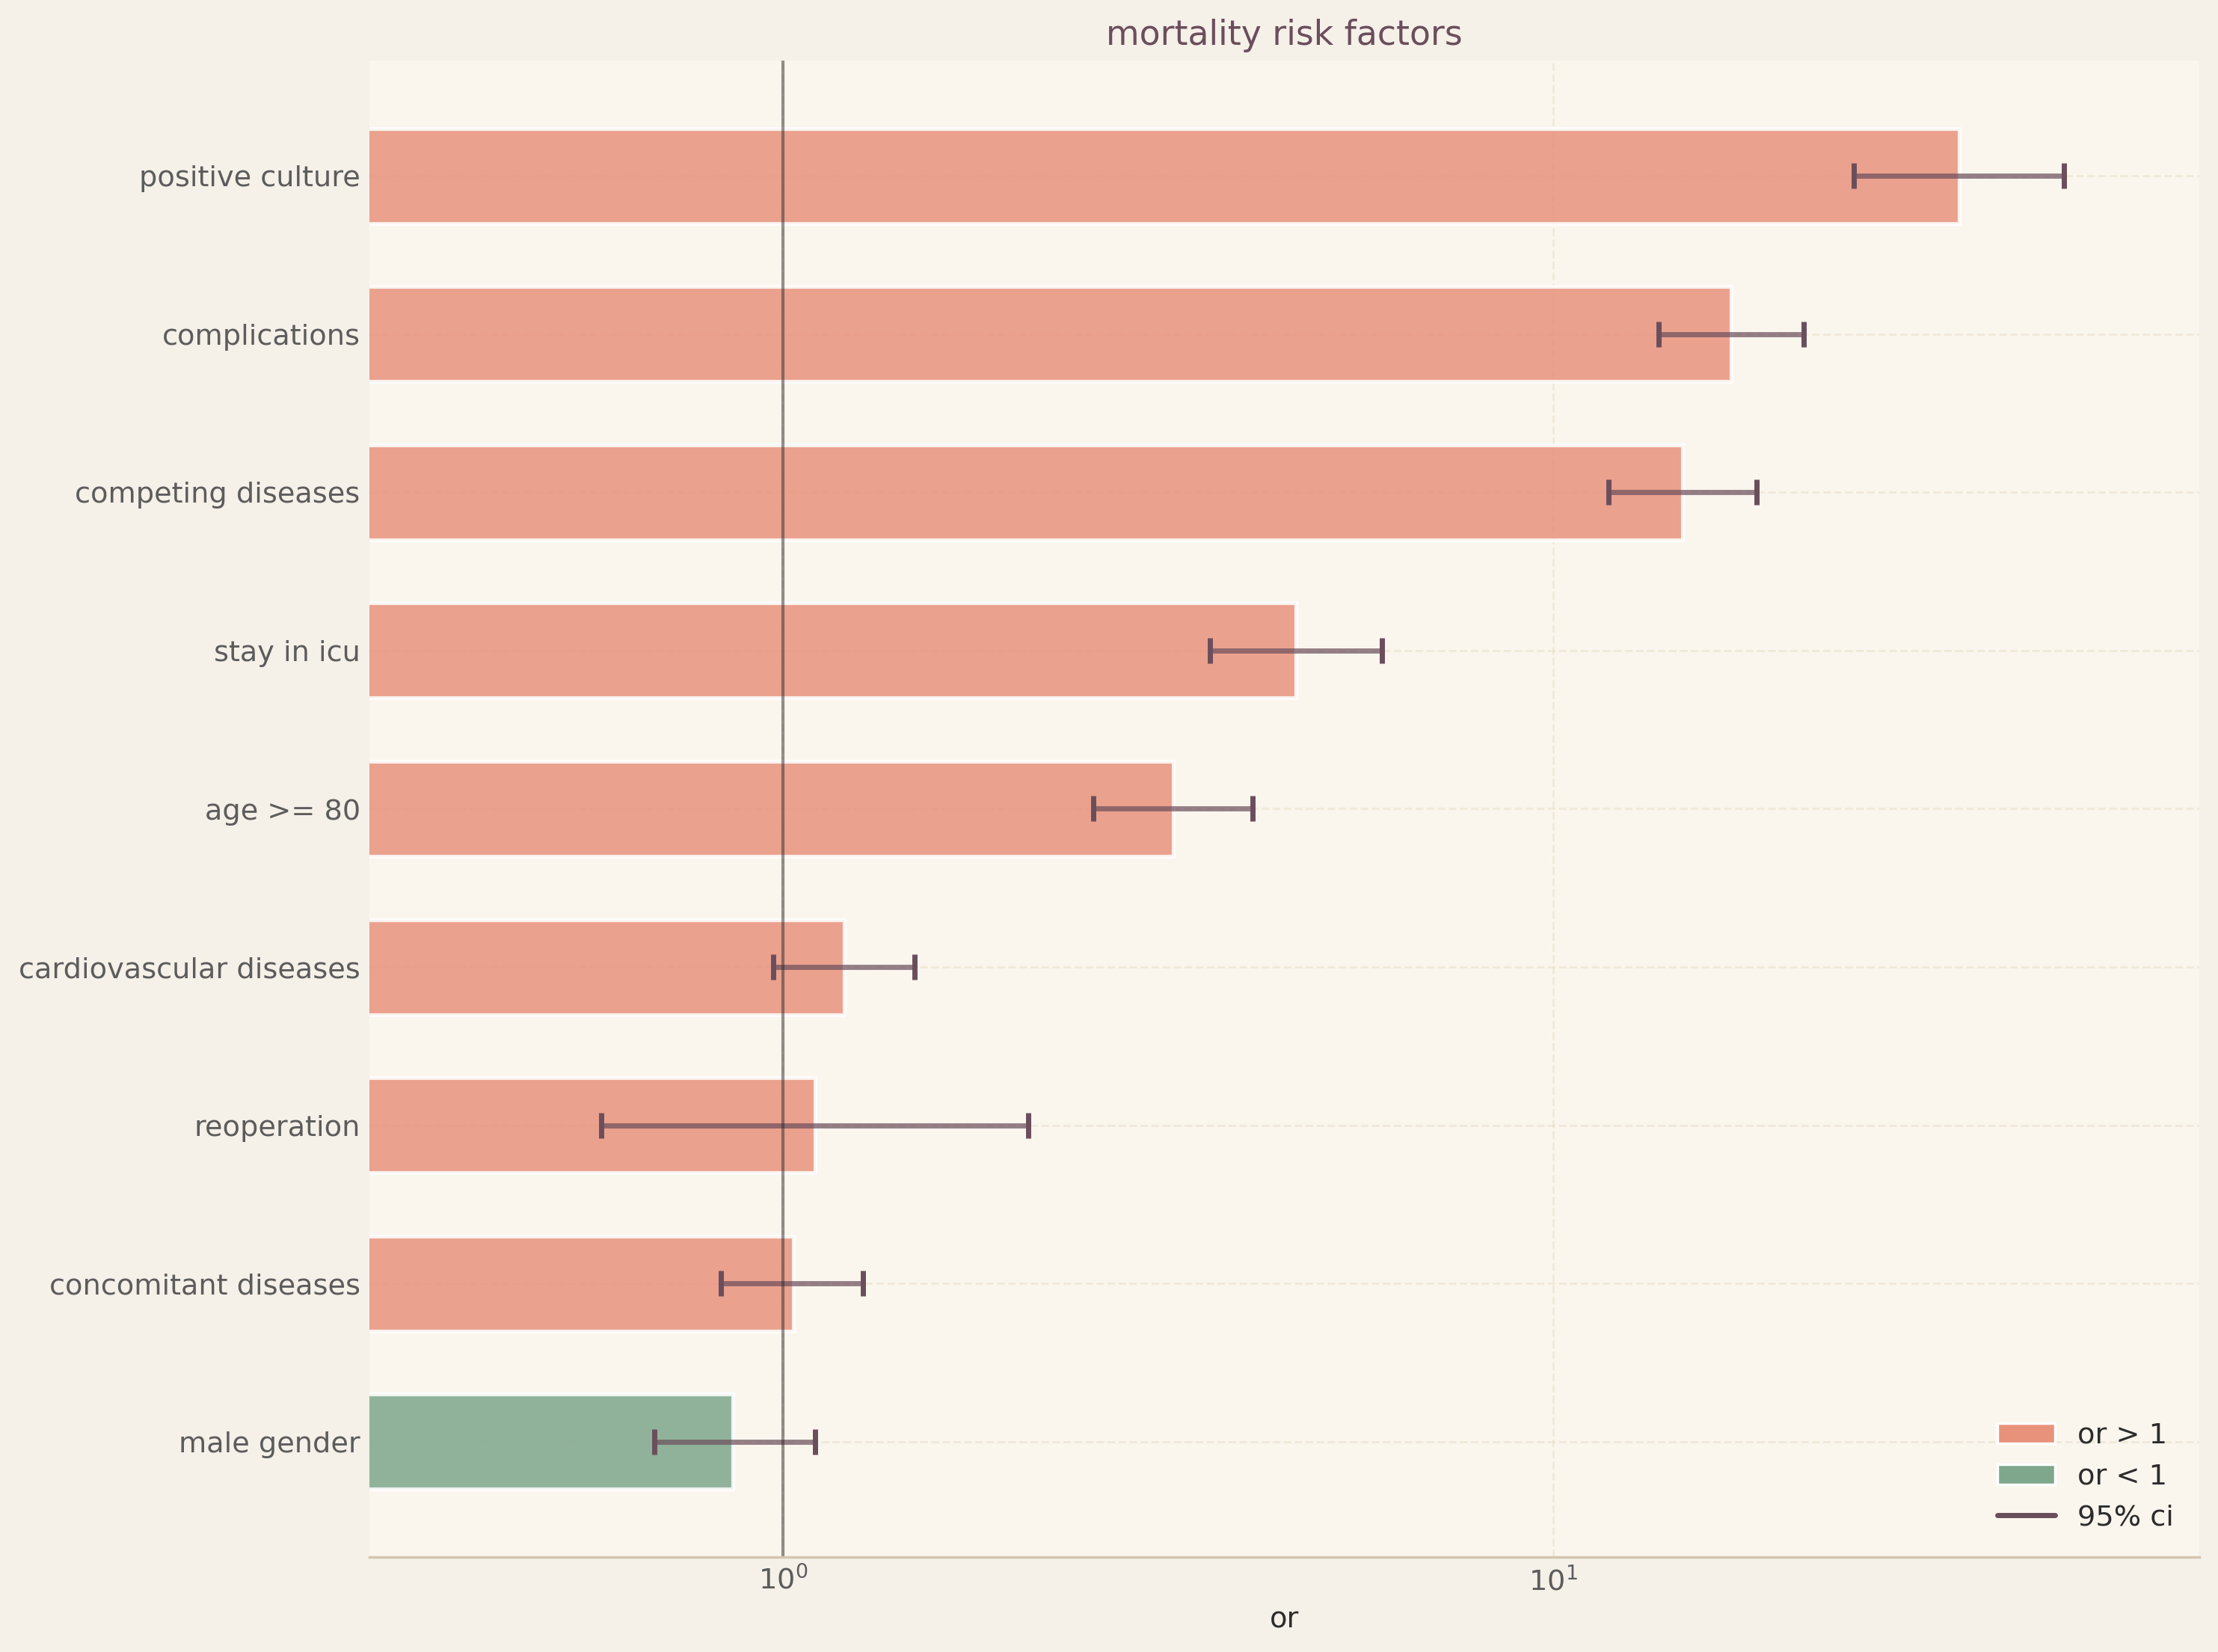


--- longstay_prox.png ---


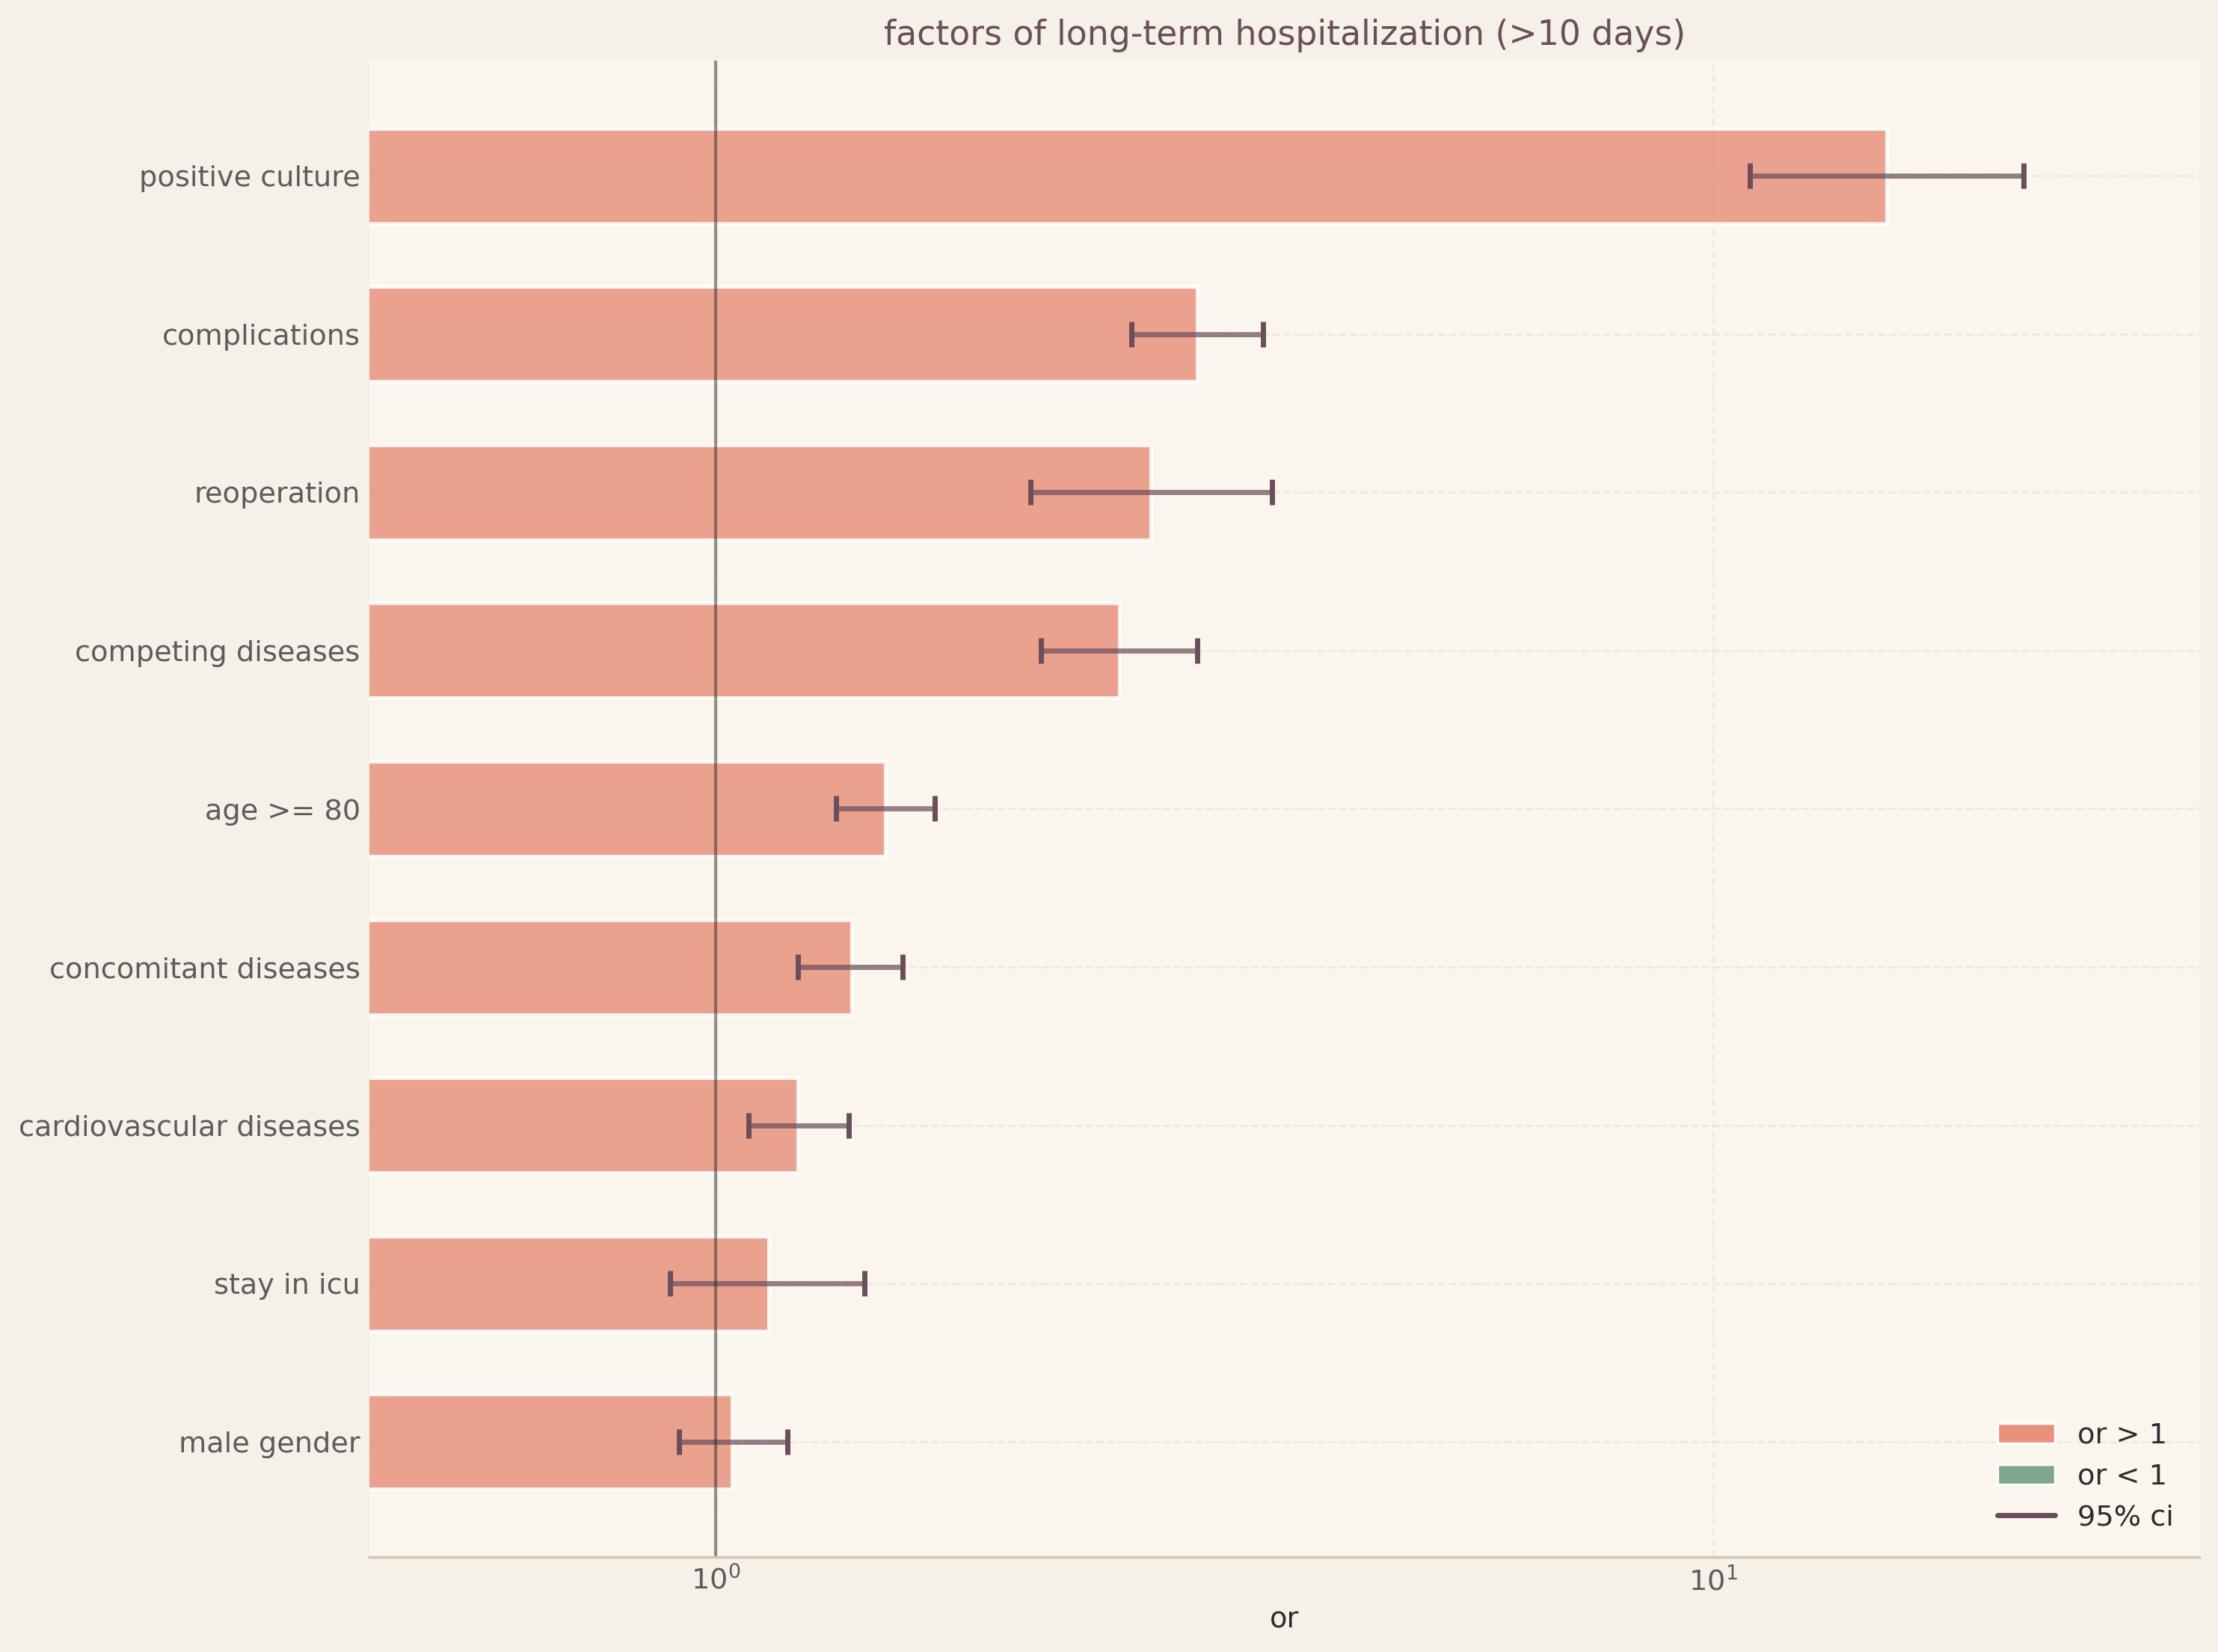


--- forest_mo_mort.png ---


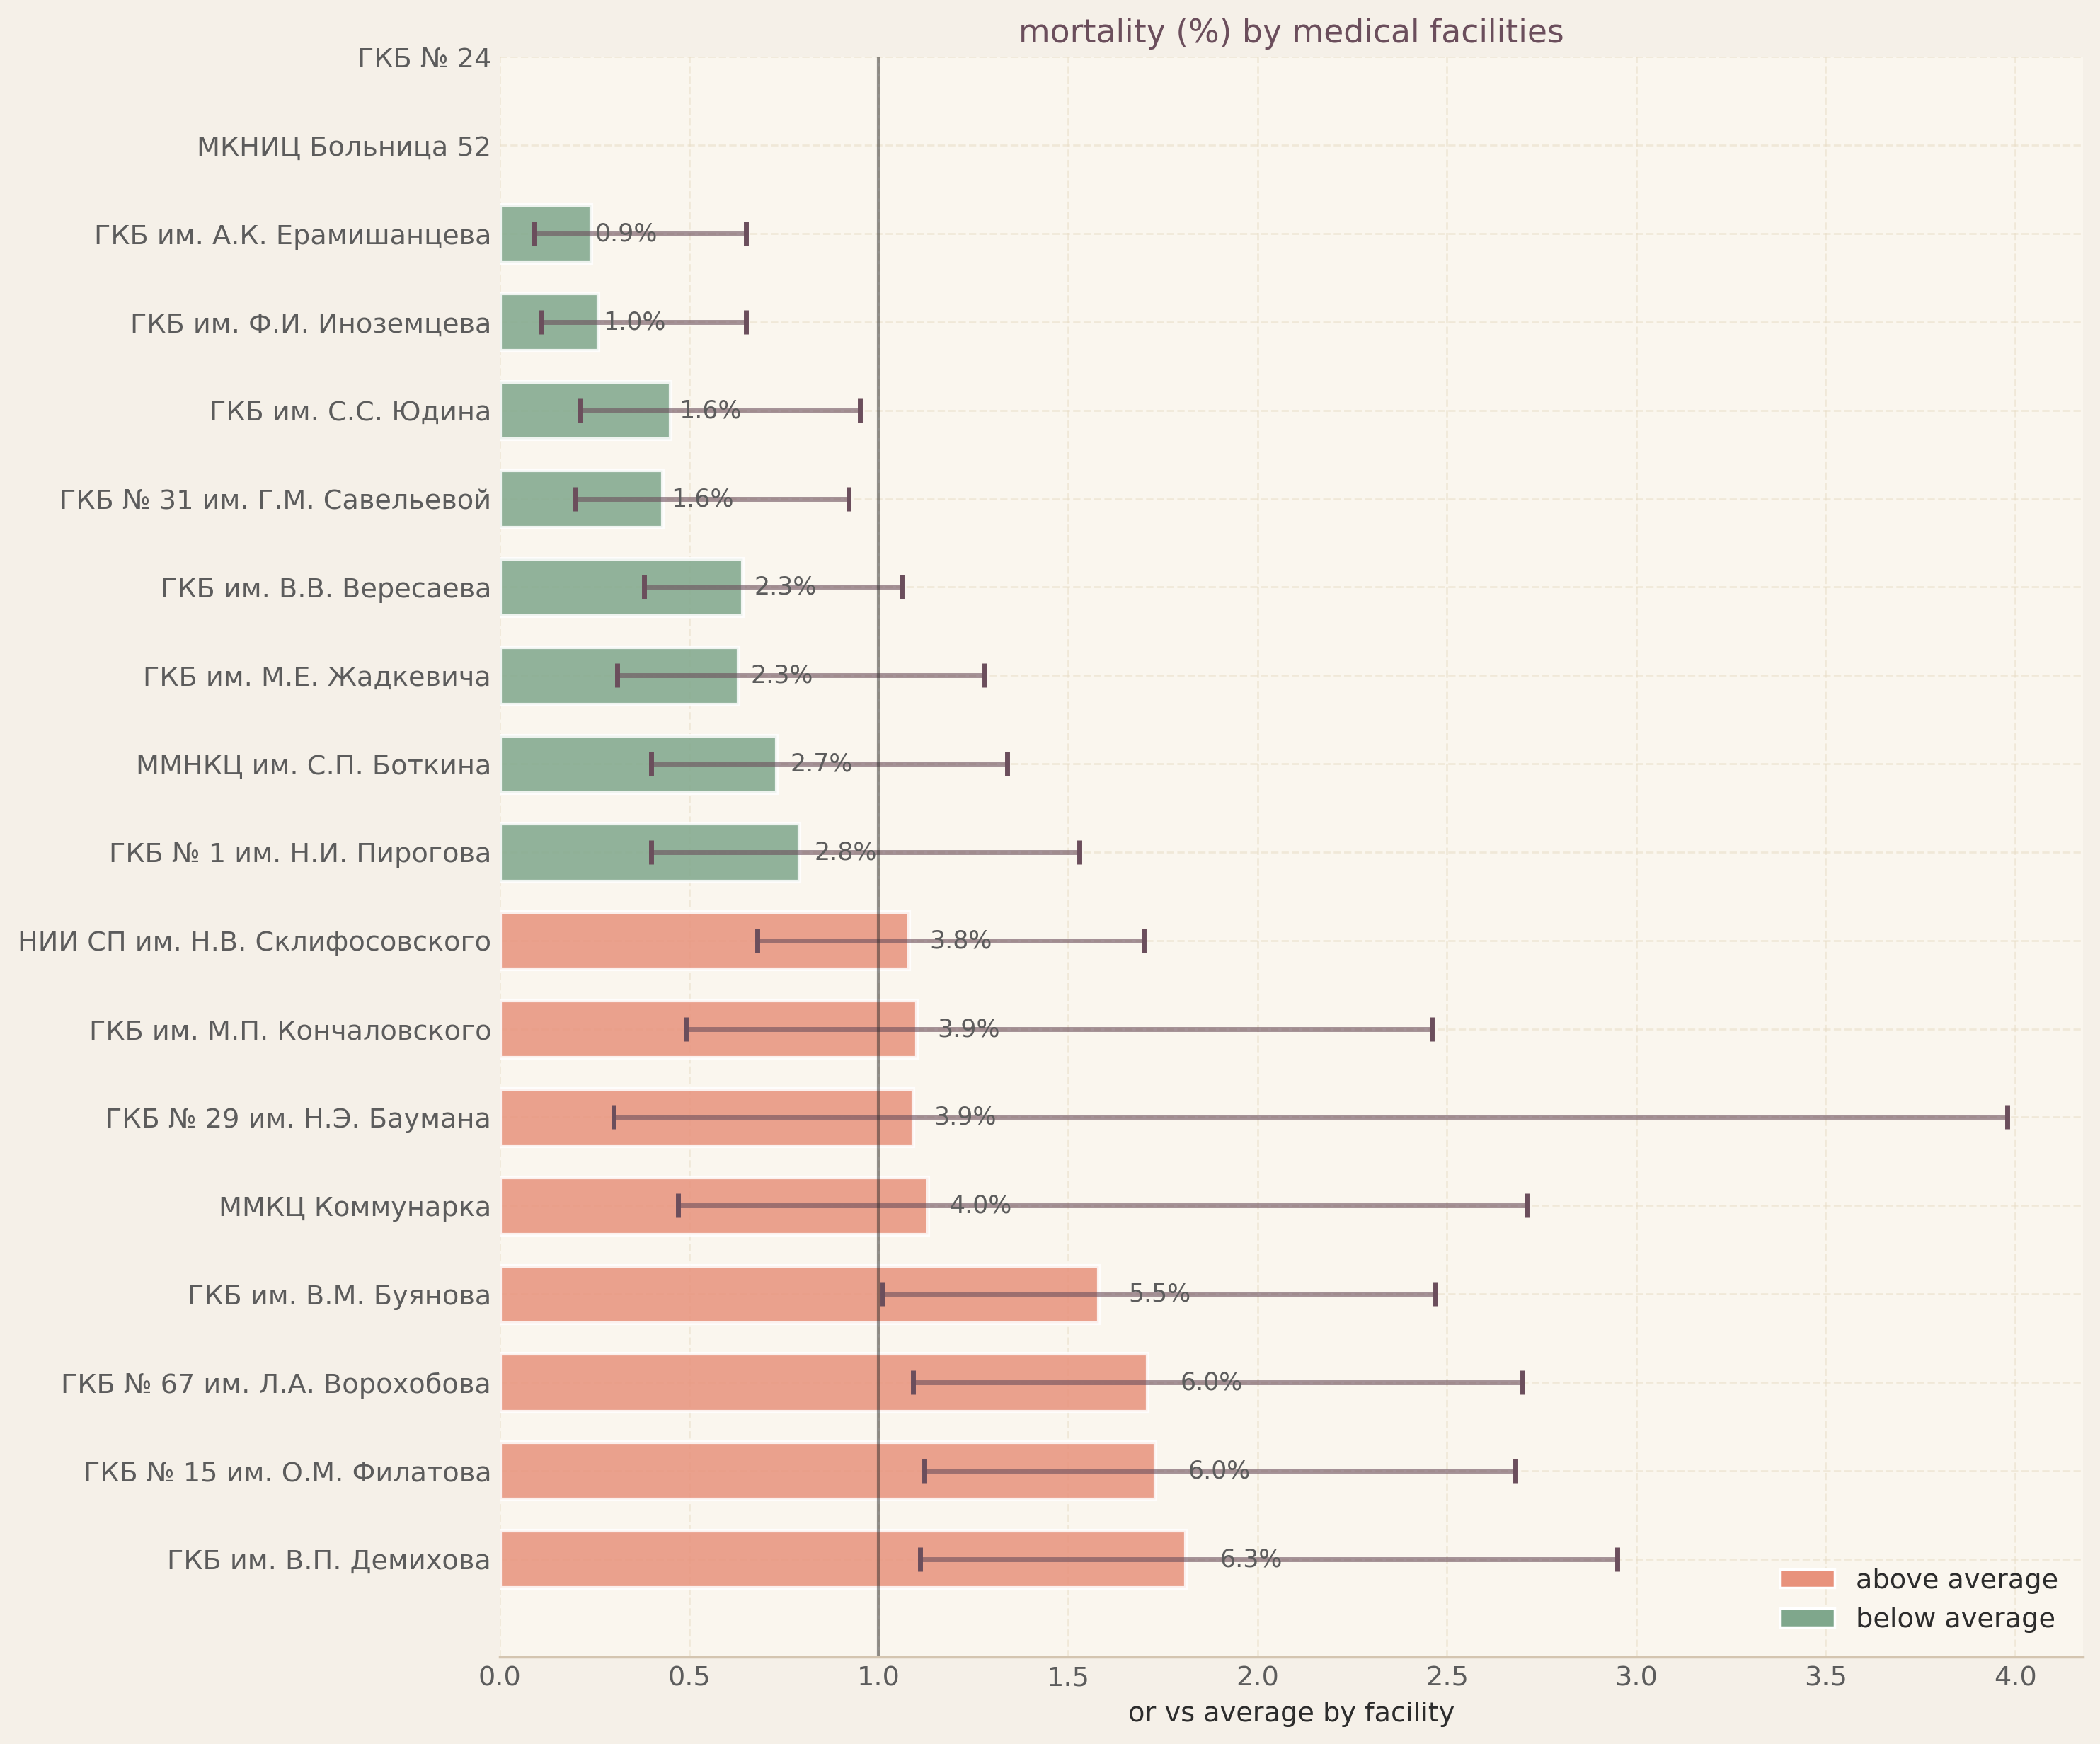


--- forest_mo_ls.png ---


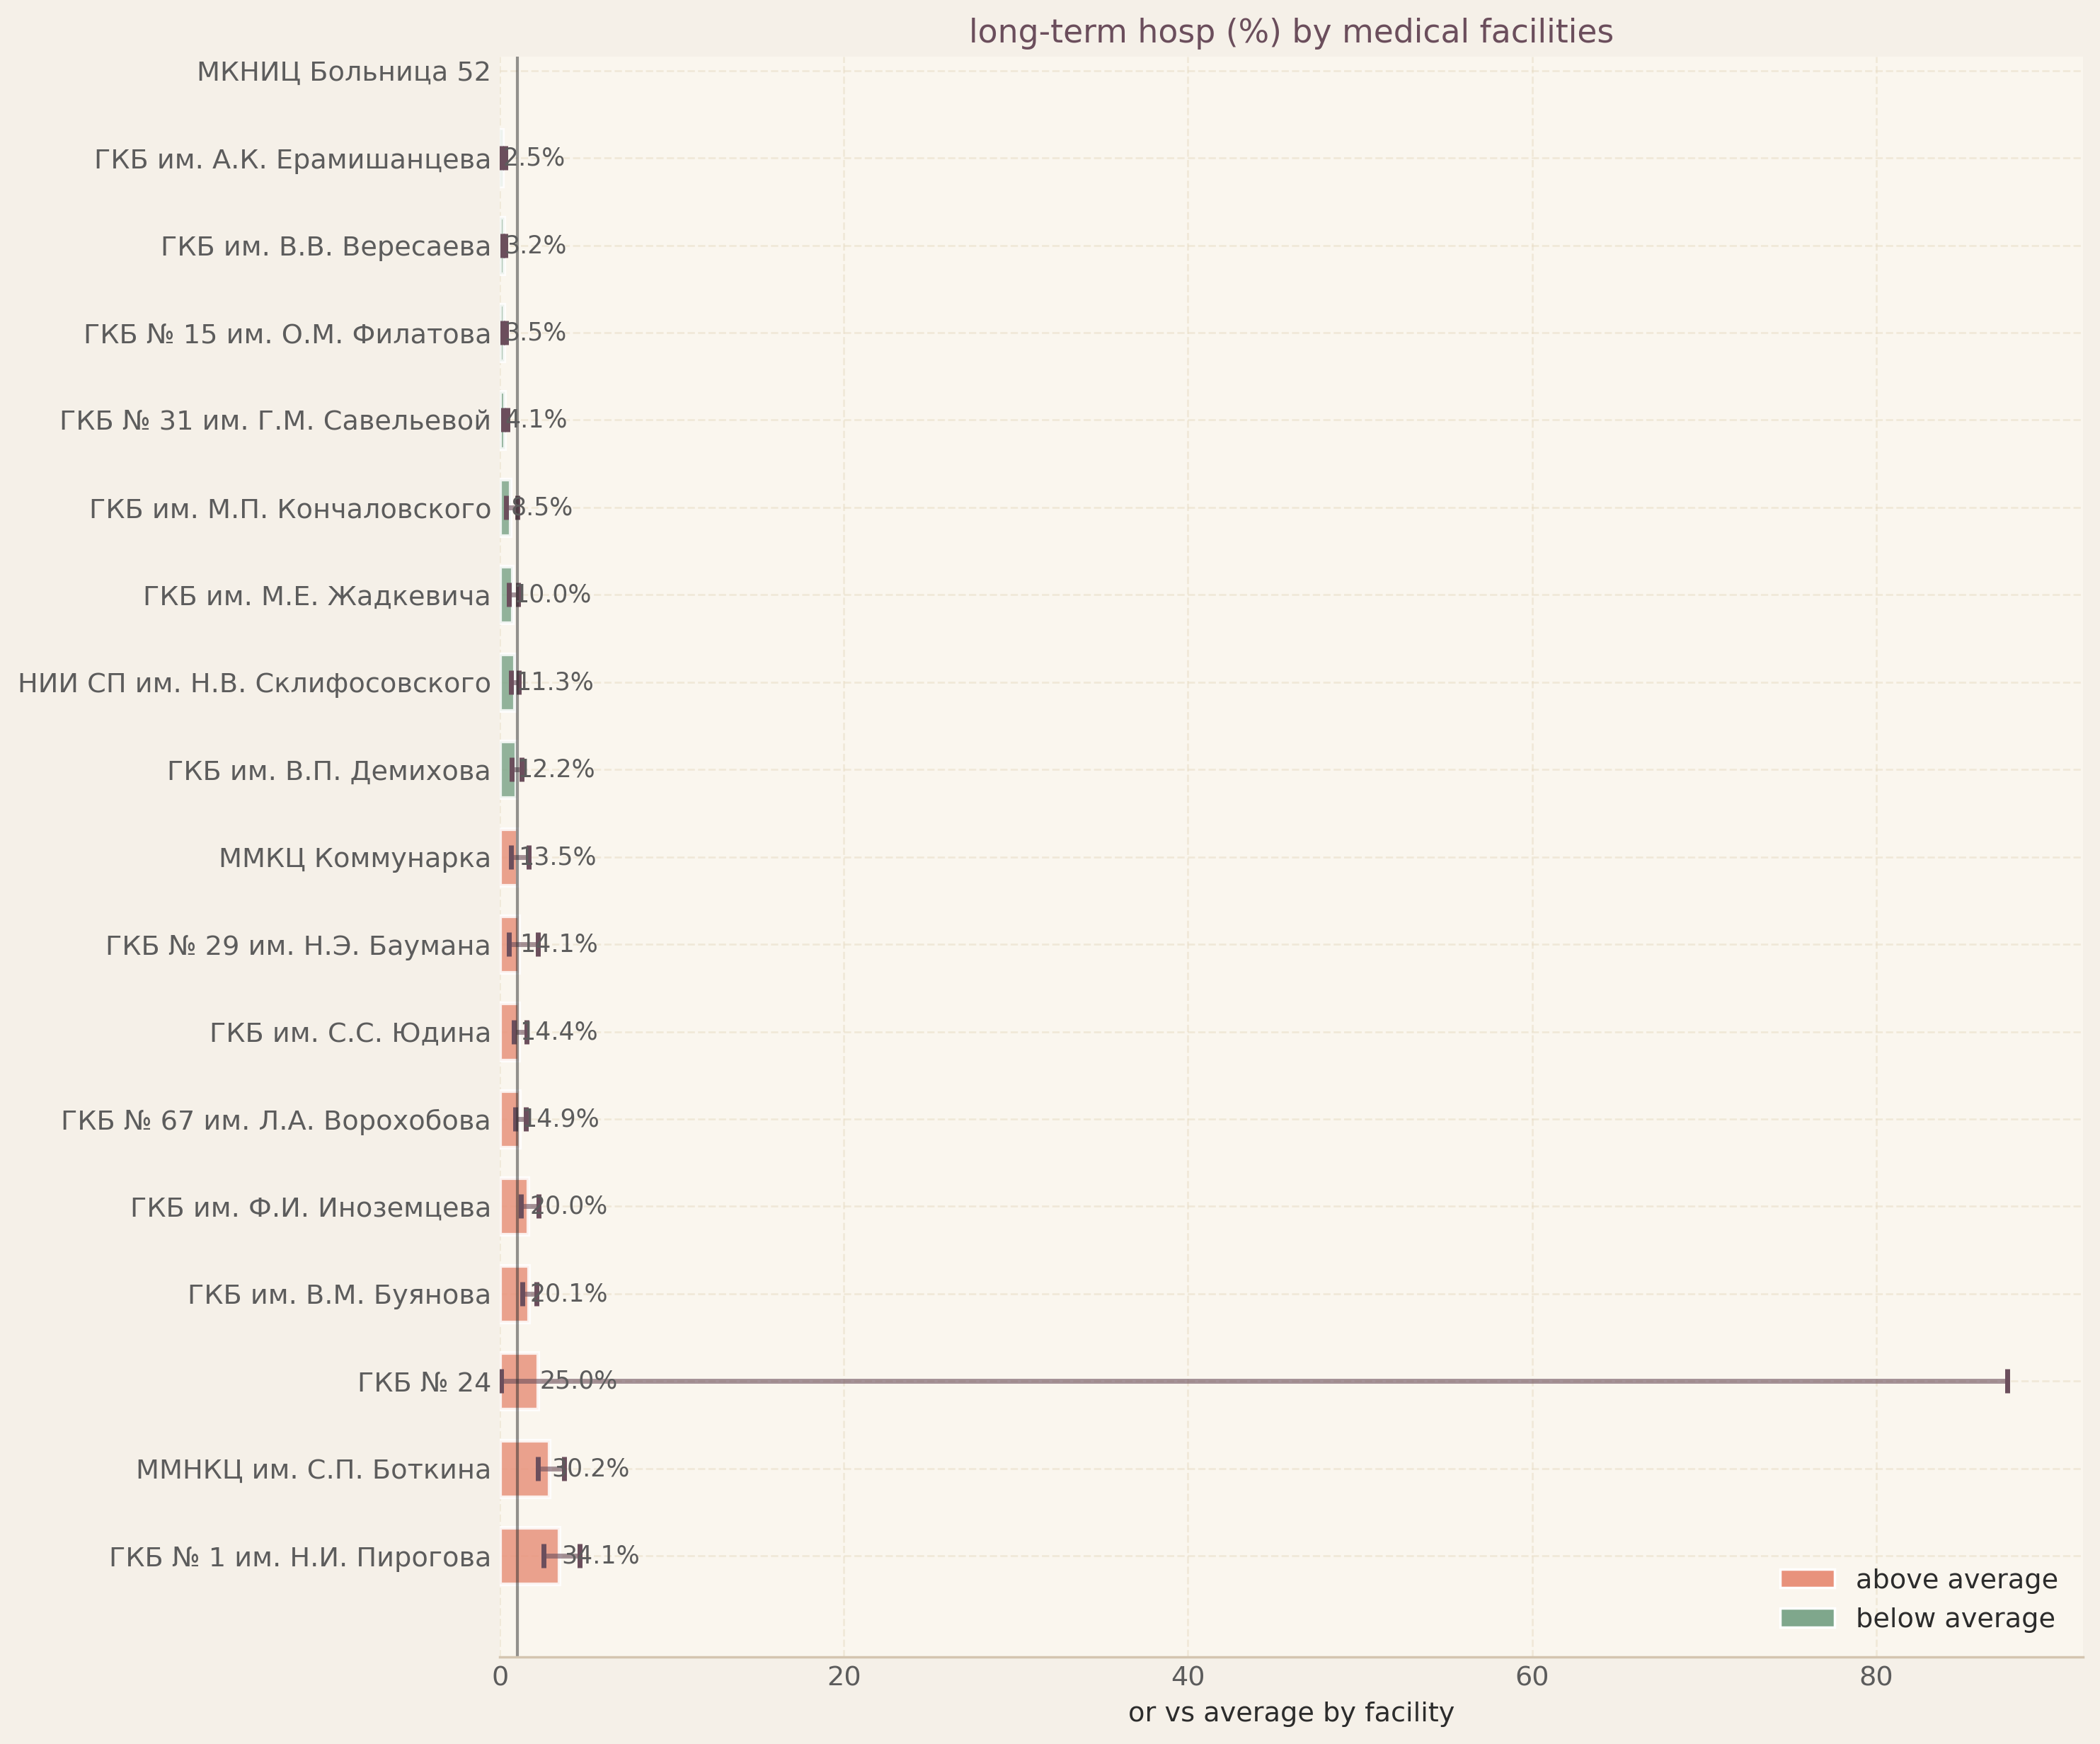


--- heatmap_factors.png ---


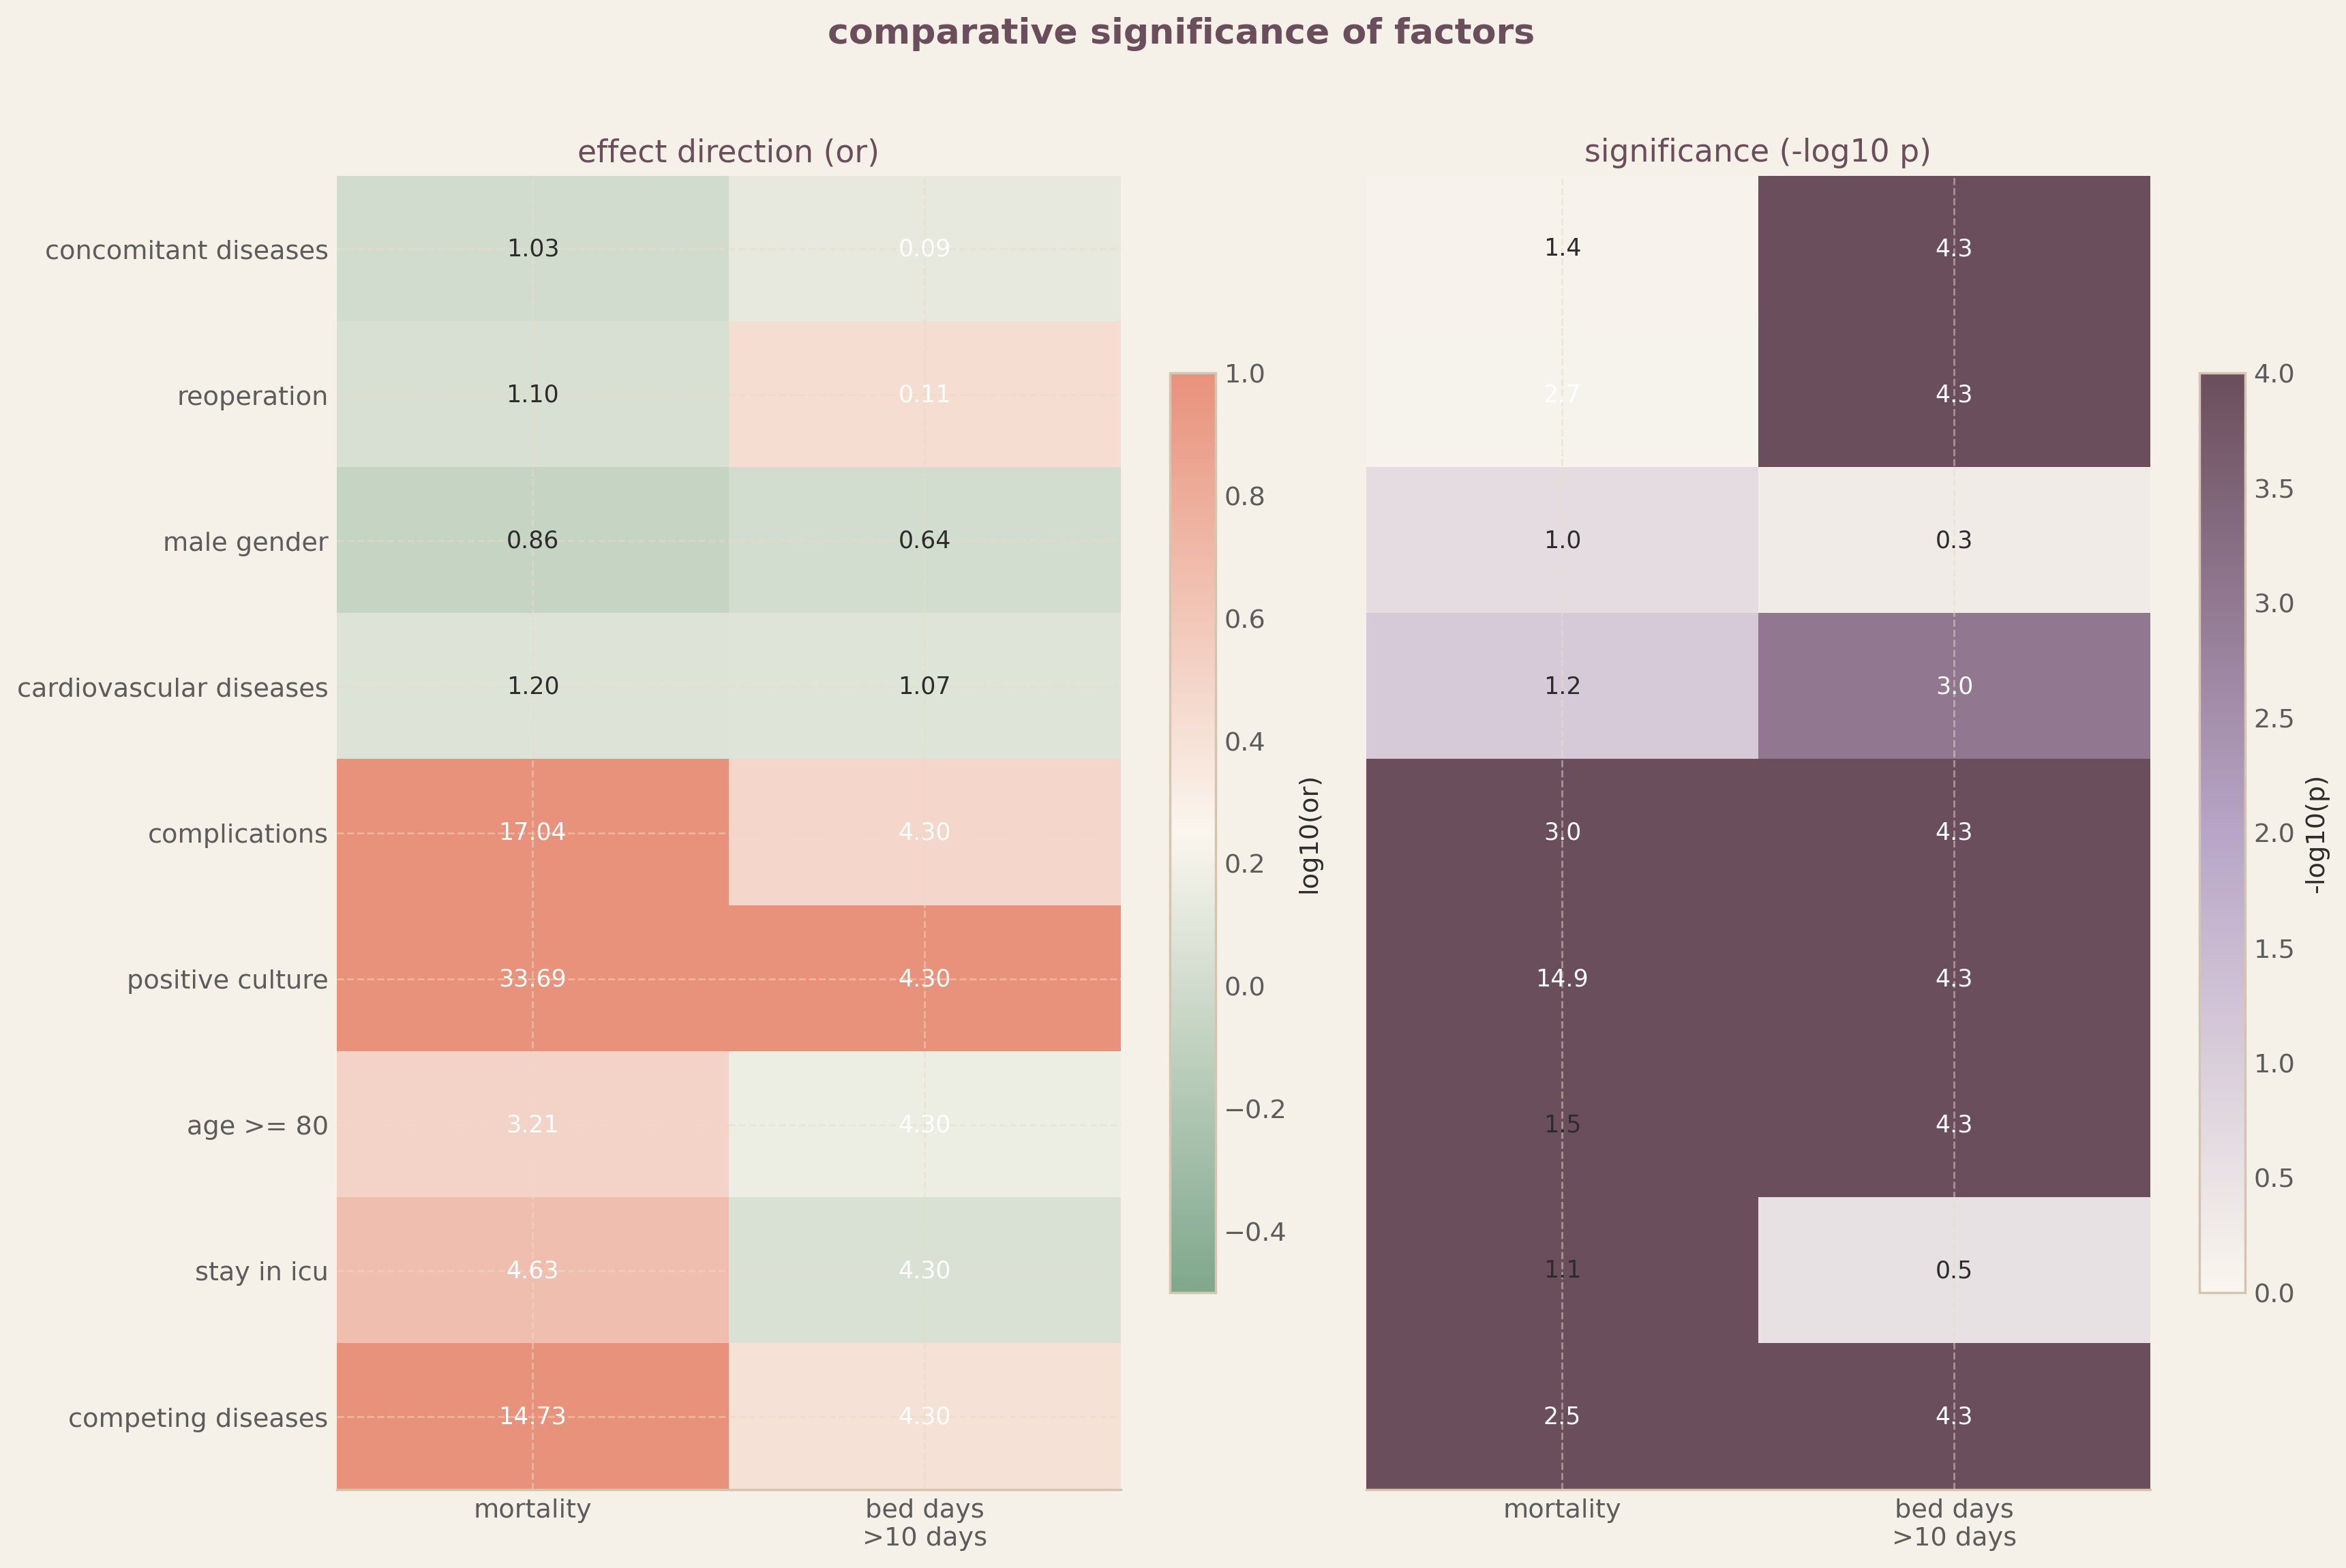

In [35]:
from IPython.display import Image, display

print("displaying saved charts:\n")

for fname in ['mortality_prox.png', 'longstay_prox.png', 'forest_mo_mort.png', 'forest_mo_ls.png', 'heatmap_factors.png']:
    try:
        print(f"--- {fname} ---")
        display(Image(filename=fname))
        print()
    except FileNotFoundError:
        print(f"  file {fname} not found - run the plotting code first\n")

### distal

In [38]:
df=pd.read_excel('dist_dataset.xlsx', engine='openpyxl')
df.head()

,ehr_case_id_dashb,ib_number_dashb,emias_id_dashb,age_dashb,facility_name_dashb,date_hosp_dashb,orit_dashb,one_prof_bed_dashb,leave_date_dashb,main_diagnosis_dashb,time_to_oper_dashb,oper_code_dashb,oper_v_tech_cel_perioda_dashb,is_oper_dashb,operations_dashb,bed_days_dashb,bed_days_orit_dashb,death_dashb,epicrisis_diagnosis_dashb,hospitalization_id,facility_id,lpu_name,last_dept_name,dept_name_list,emias_id,erz_number,birth,age,sex,ib_number,hospitalization_type,channel,input_date,leave_date,bed_days,hospitalization_result,hospitalization_outcome,transfer_flag,death_in_hospitalization,death_date_in_hospitalization,death_within_30_days,death_date_within_30_days,epicrisis_main_diagnoses,epicrisis_complication_diagnoses,epicrisis_competing_diagnoses,epicrisis_concomitant_diagnoses,cad,dad,chss,repeat_hosp_30d_info,first_operation_start_dt,first_operation_end_dt,operation_osteo_flag,operation_endoprotez_flag,other_operation_flag,operations_timeline,repeated_operations_one_hosp,repeated_operations_others_hosp_30d,repeated_operations_ambulat_30d,has_analgesics,analgesics_given_cnt,analgesics_unique_mnn_cnt,analgesics_mnn_list,has_opioids,opioids_given_cnt,opioids_unique_mnn_cnt,opioids_mnn_list,has_antibiotics,antibiotics_given_cnt,antibiotics_unique_mnn_cnt,antibiotics_mnn_list,has_anticoagulants,anticoagulants_given_cnt,anticoagulants_unique_mnn_cnt,anticoagulants_mnn_list,has_blockers,blockers_given_cnt,blockers_unique_mnn_cnt,blockers_mnn_list,has_urine_biomaterial,has_blood_biomaterial,has_wound_biomaterial,has_op_material_biomaterial,has_other_biomaterial,has_pseudomonas,has_klebsiella,has_staphylococcus,has_microorg_list,microorg_details,koe_urine,koe_urine_name_microorg_list,koe_blood,koe_blood_name_microorg_list,koe_wound,koe_wound_name_microorg_list,koe_op_material,koe_op_material_name_microorg_list,koe_others_biomaterial,koe_others_biomaterial_name_microorg_list,run_dt,has_complication,has_concomitant,has_competing
0,0cca5e36-2c83-4a0a-8023-8c007918b796,1186-25,3.094054e+07,75,НИИ СП им. Н.В. Склифосовского,2025-01-06 16:45:32,NaN,Кардиохирургические,2025-01-14,S72.30,10.0,A16.03.022.006,Да,Да,2025-01-07 02:40:00 | A16.03.022.006 | Интраме...,7.697546,"0,935787",Нет,NaN,0cca5e36-2c83-4a0a-8023-8c007918b796,10394853,ГБУЗ «НИИ СП им. Н.В.Склифосовского ДЗМ»,Травматологическое отделение №2,Отделение реанимации и интенсивной терапии для...,3.094054e+07,19935715,1949-09-14,76,Ж,1186-25,Экстренно,103,2025-01-06 16:41:21.000 +0300,2025-01-14 09:30:00.000 +0300,8,Выписан из стационара,улучшение,0,0,NaN,0,NaN,S72.30,NaN,NaN,NaN,130.0,80.0,76.0,"2025-01-14 12:31:23, 83a89ae3-4ab5-464d-abd9-d...",2025-01-07 02:40:00,2025-01-07 05:50:36.000 +0300,1,0,0,"(2025-01-07 02:40:00, A16.03.022.006, Остеосин...",NaN,NaN,NaN,1,25,2,"Кетопрофен, Диклофенак",1,4,1,Тримеперидин,1,1,1,Цефазолин,1,6,2,"Эноксапарин натрия, Ривароксабан",1,1,1,Левобупивакаин,0,0,0,0,0,0,0,0,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,2026-06-05 14:49:29.000 +0300,0,0,0
1,c6910272-259b-415c-8023-f733faefcf53,27801-2025,2.606060e+07,55,НИИ СП им. Н.В. Склифосовского,2025-04-22 09:18:53,NaN,Травматолого-ортопедические,2025-04-28,S72.80,24.0,A16.03.063.003,Да,Да,2025-04-23 08:50:00 | A16.03.063.003 | Эндопро...,5.874572,NaN,Нет,NaN,c6910272-259b-415c-8023-f733faefcf53,10394853,ГБУЗ «НИИ СП им. Н.В.Склифосовского ДЗМ»,Травматологическое отделение №1,Травматологическое отделение №1,2.606060e+07,19445399,1969-06-27,56,М,27801-2025,Экстренно,103 Поликлиника,2025-04-22 09:15:41.000 +0300,2025-04-28 06:18:16.000 +0300,6,Выписан из стационара,улучшение,0,0,NaN,0,NaN,S72.80,NaN,NaN,NaN,160.0,80.0,65.0,NaN,2025-04-23 08:50:00,2025-04-23 09:40:00.000 +0300,0,1,0,"(2025-04-23 08:50:00, A16.03.063.003, Эндопрот...",NaN,NaN,NaN,1,28,1,Кеторолак,1,4,2,"Тримеперидин, Морфин",0,0,0,NaN,1,8,1,Гепарин натрия,1,2,2,"Ропивакаин, Левобупивакаин",0,0,0,0,0,0,0,0,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,2026-06-05 14:49:29.000 +0300,0,0,0
2,847baebf-f8d9-49e3-80ba-1e181fd9d792,77453-2025,7.065522e+07,38,Н

In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1332 entries, 0 to 1331
Columns: 103 entries, ehr_case_id_dashb to has_competing
dtypes: datetime64[us](3), float64(9), int64(42), str(49)
memory usage: 1.0 MB


In [40]:
# age
df['age_dashb'] = pd.to_numeric(df['age_dashb'],errors='coerce')
df['age_80_plus'] = (df['age_dashb'] >= 80).astype(int)

# check
print ("AGE")
print(f" age>= 80: {df['age_80_plus'].sum()} ({df['age_80_plus'].mean()*100:.1f}%)")
print(f" NaN age_dashb: {df['age_dashb'].isna().sum()}")
print(f" NaN age>= 80: {df['age_80_plus'].isna().sum()}")
print(f" done!\n")

AGE
 age>= 80: 405 (30.4%)
 NaN age_dashb: 0
 NaN age>= 80: 0
 doneE!



In [41]:
#outcome flags

df['death_flag'] = df['death_in_hospitalization'].astype(int)
df['long_stay_10'] = (df['bed_days_dashb']> 10).astype(int)

#check
print("outcome flags")
print(f" mortality: {df['death_flag'].sum()} ({df['death_flag'].mean()*100:.1f}%)")
print(f" longstay> 10days: {df['long_stay_10'].sum()} ({df['long_stay_10'].mean()*100:.1f}%)")
print(f" NaN death_flag: {df['death_flag'].isna().sum()}")
print(f" NaN long_stay_10: {df['long_stay_10'].isna().sum()}")
print(f" done!\n")

outcome flags
 mortality: 56 (4.2%)
 longstay> 10days: 282 (21.2%)
 NaN death_flag: 0
 NaN long_stay_10: 0
 done!



In [42]:
#demography
df['is_male'] = (df['sex'] == 'М').astype(int)
df['was_in_orit'] = df['orit_dashb'].notna().astype(int)

#check
print("DEMOGRAPHY")
print(f"   male: {df['is_male'].sum()} ({df['is_male'].mean()*100:.1f}%)")
print(f"   was in ORIT: {df['was_in_orit'].sum()} ({df['was_in_orit'].mean()*100:.1f}%)")
print(f"   NaN  is_male: {df['is_male'].isna().sum()}")
print(f"   NaN  was_in_orit: {df['was_in_orit'].isna().sum()}")
print(f"   done\n")

DEMOGRAPHY
   male: 481 (36.1%)
   was in ORIT: 224 (16.8%)
   NaN  is_male: 0
   NaN  was_in_orit: 0
   done



In [43]:
# COMPLICATION / CONCOMITANT / COMPETING FLAGS

df['has_complication'] = df['epicrisis_complication_diagnoses'].notna().astype(int)
df['has_concomitant'] = df['epicrisis_concomitant_diagnoses'].notna().astype(int)
df['has_competing'] = df['epicrisis_competing_diagnoses'].notna().astype(int)

# check

print("DIAGNOSES FLAGS")
print(f"   has complication: {df['has_complication'].sum()} ({df['has_complication'].mean()*100:.1f}%)")
print(f"   has concomitant: {df['has_concomitant'].sum()} ({df['has_concomitant'].mean()*100:.1f}%)")
print(f"   has competing: {df['has_competing'].sum()} ({df['has_competing'].mean()*100:.1f}%)")
print(f"   NaN in flags: {df[['has_complication','has_concomitant','has_competing']].isna().sum().sum()}")
print(f"   done\n")

DIAGNOSES FLAGS
   has complication: 158 (11.9%)
   has concomitant: 674 (50.6%)
   has competing: 99 (7.4%)
   NaN in flags: 0
   done



In [44]:
# REOPERATION

df['has_any_reoperation'] = (
    df['repeated_operations_one_hosp'].notna() | 
    df['repeated_operations_others_hosp_30d'].notna()
).astype(int)

# check
print("REOPERATION")
print(f"   has any reoperation: {df['has_any_reoperation'].sum()} ({df['has_any_reoperation'].mean()*100:.1f}%)")
print(f"   NaN has_any_reoperation: {df['has_any_reoperation'].isna().sum()}")
print(f"   done\n")

REOPERATION
   has any reoperation: 308 (23.1%)
   NaN has_any_reoperation: 0
   done



In [45]:
# MICROBIOLOGY

micro_cols = ['koe_urine', 'koe_blood', 'koe_wound', 'koe_op_material', 'koe_others_biomaterial']
existing_micro = [c for c in micro_cols if c in df.columns]
df['has_positive_culture'] = df[existing_micro].gt(0).any(axis=1).astype(int) if existing_micro else 0

# check
print("MICROBIOLOGY")
print(f"   microbiology columns: {len(existing_micro)} from {len(micro_cols)}")
print(f"   has positive culture: {df['has_positive_culture'].sum()} ({df['has_positive_culture'].mean()*100:.1f}%)")
print(f"   NaN has_positive_culture: {df['has_positive_culture'].isna().sum()}")
print(f"   done\n")


MICROBIOLOGY
   microbiology columns: 5 from 5
   has positive culture: 34 (2.6%)
   NaN has_positive_culture: 0
   done



In [46]:
# SEASON AND CATEGORIES

def get_season(m):
    if pd.isna(m): return 'unknown'
    if m in [12, 1, 2]: return 'winter'
    if m in [3, 4, 5]: return 'spring'
    if m in [6, 7, 8]: return 'summer'
    return 'fall'

df['season'] = df['date_hosp_dashb'].dt.month.apply(get_season)
df['hosp_type_clean'] = df['hospitalization_type'].fillna('unknown')
df['channel_clean'] = df['channel'].fillna('unknown')

# check
print("SEASON AND CATEGORIES")
print(f"   seasonal distribution:\n{df['season'].value_counts()}")
print(f"   types of hospitalization:\n{df['hosp_type_clean'].value_counts().head()}")
print(f"   channels:\n{df['channel_clean'].value_counts().head()}")
print(f"   done\n")

SEASON AND CATEGORIES
   seasonal distribution:
season
winter    529
spring    320
summer    254
fall      229
Name: count, dtype: int64
   types of hospitalization:
hosp_type_clean
Экстренно    1287
Планово        45
Name: count, dtype: int64
   channels:
channel_clean
103                1172
самотек              89
103 Поликлиника      48
план                 23
Name: count, dtype: int64
   done



In [47]:
# CARDIOVASCULAR DISEASES concomitant + competing

cvd_prefixes = [
    'I10', 'I11', 'I12', 'I13', 'I14', 'I15',   
    'I20', 'I21', 'I22', 'I23', 'I24', 'I25',   
    'I60', 'I61', 'I62', 'I63', 'I64', 'I65', 'I66', 'I67', 'I68', 'I69'  
]

diagnosis_cols = ['epicrisis_concomitant_diagnoses', 'epicrisis_competing_diagnoses']

def has_cvd(row):
    combined = ''
    for col in diagnosis_cols:
        val = row.get(col, '')
        if pd.notna(val):
            combined += str(val).upper() + ' '
    if not combined.strip():
        return 0
    return 1 if any(p in combined for p in cvd_prefixes) else 0

df['has_cvd'] = df.apply(has_cvd, axis=1)

# check
print("CARDIOVASCULAR DISEASES")
print(f"   in columns: {diagnosis_cols}")
print(f"   has CVD: {df['has_cvd'].sum()} ({df['has_cvd'].mean()*100:.1f}%)")
print(f"   NaN в has_cvd: {df['has_cvd'].isna().sum()}")

# example
cvd_examples = df[df['has_cvd'] == 1][['epicrisis_concomitant_diagnoses', 'epicrisis_competing_diagnoses']].head(3)
print(f"\n  example CVD:")
print(cvd_examples.to_string())
print(f"   done\n")

CARDIOVASCULAR DISEASES
   in columns: ['epicrisis_concomitant_diagnoses', 'epicrisis_competing_diagnoses']
   has CVD: 533 (40.0%)
   NaN в has_cvd: 0

  example CVD:
   epicrisis_concomitant_diagnoses epicrisis_competing_diagnoses
8                     D64.9, I11.9                         I25.1
12                           I11.9                         I25.1
13                    I11.9, K29.9                         I25.1
   done



In [48]:
# color settings
plt.rcParams.update({
    'figure.facecolor': '#F5F0E8', 'axes.facecolor': '#FAF6EE',
    'axes.edgecolor': '#D4C5B0', 'axes.labelcolor': '#2C2C2C',
    'xtick.color': '#5C5C5C', 'ytick.color': '#5C5C5C',
    'text.color': '#2C2C2C', 'font.family': 'DejaVu Sans',
    'font.size': 11, 'axes.grid': True, 'grid.color': '#E8DCC4',
    'grid.linestyle': '--', 'grid.alpha': 0.5,
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.spines.left': False,
})

# Палитра
CORAL_SUNSET = '#E8927C'
SAGE_GREEN = '#7FA78C'
DUSTY_LAVENDER = '#B8A5C7'
SOFT_TEAL = '#7FB5B0'
DEEP_PLUM = '#6B4E5C'
WARM_SAND = '#D4B896'

print("colors are added")

colors are added


In [49]:
# binary factors -> mortality

print("binary factors -> mortality")

binary_factors = [
    ('age_80_plus', 'age >= 80'),
    ('is_male', 'male gender'),
    ('was_in_orit', 'stay in the icu'),
    ('has_cvd', 'cardiovascular diseases'),
    ('has_complication', 'complications'),
    ('has_concomitant', 'concomitant diseases'),
    ('has_competing', 'competing diseases'),
    ('has_any_reoperation', 'reoperation'),
    ('has_positive_culture', 'positive culture'),
]

results_death = []
for f_col, f_name in binary_factors:
    print(f"\nanalysis: {f_name}")
    try:
        res = calc_or_binary(f_col, 'death_flag', f_name, verbose=True)
        results_death.append(res)
    except Exception as e:
        print(f"  error: {e}\n")

df_death_results = pd.DataFrame(results_death)
print("\nsummary: mortality")
print(df_death_results.to_string(index=False))

binary factors -> mortality

analysis: age >= 80
   2x2 table: a=38, b=367, c=18, d=909
   with factor: 38/405 (9.4%) | without: 18/927 (1.9%)
   or = 5.23 | 95% ci: [2.95-9.28]
   chi2 | p = <0.0001 -> significant


analysis: male gender
   2x2 table: a=14, b=467, c=42, d=809
   with factor: 14/481 (2.9%) | without: 42/851 (4.9%)
   or = 0.58 | 95% ci: [0.31-1.07]
   chi2 | p = 0.0770 -> not significant


analysis: stay in the icu
   2x2 table: a=18, b=206, c=38, d=1070
   with factor: 18/224 (8.0%) | without: 38/1108 (3.4%)
   or = 2.46 | 95% ci: [1.38-4.40]
   chi2 | p = 0.0017 -> significant


analysis: cardiovascular diseases
   2x2 table: a=29, b=504, c=27, d=772
   with factor: 29/533 (5.4%) | without: 27/799 (3.4%)
   or = 1.65 | 95% ci: [0.96-2.81]
   chi2 | p = 0.0662 -> not significant


analysis: complications
   2x2 table: a=31, b=127, c=25, d=1149
   with factor: 31/158 (19.6%) | without: 25/1174 (2.1%)
   or = 11.22 | 95% ci: [6.42-19.60]
   chi2 | p = <0.0001 -> signifi

In [50]:
# binary factors -> long-term hospitalization

print("binary factors -> long-term hospitalization (long_stay_10)")

results_stay = []
for f_col, f_name in binary_factors:
    print(f"\nanalysis: {f_name}")
    try:
        res = calc_or_binary(f_col, 'long_stay_10', f_name, verbose=True)
        results_stay.append(res)
        print(f"  the result has been added to the table\n")
    except Exception as e:
        print(f"  error: {e}\n")

df_stay_results = pd.DataFrame(results_stay)
print("\nsummary table: long-term hospitalization")
if len(df_stay_results) > 0:
    print(df_stay_results.to_string(index=False))
else:
    print("   table is empty! error!")

binary factors -> long-term hospitalization (long_stay_10)

analysis: age >= 80
   2x2 table: a=84, b=321, c=198, d=729
   with factor: 84/405 (20.7%) | without: 198/927 (21.4%)
   or = 0.96 | 95% ci: [0.72-1.28]
   chi2 | p = 0.7994 -> not significant

  the result has been added to the table


analysis: male gender
   2x2 table: a=95, b=386, c=187, d=664
   with factor: 95/481 (19.8%) | without: 187/851 (22.0%)
   or = 0.87 | 95% ci: [0.66-1.15]
   chi2 | p = 0.3400 -> not significant

  the result has been added to the table


analysis: stay in the icu
   2x2 table: a=37, b=187, c=245, d=863
   with factor: 37/224 (16.5%) | without: 245/1108 (22.1%)
   or = 0.70 | 95% ci: [0.48-1.02]
   chi2 | p = 0.0616 -> not significant

  the result has been added to the table


analysis: cardiovascular diseases
   2x2 table: a=119, b=414, c=163, d=636
   with factor: 119/533 (22.3%) | without: 163/799 (20.4%)
   or = 1.12 | 95% ci: [0.86-1.46]
   chi2 | p = 0.3992 -> not significant

  the resu

In [51]:
# other analyses

print("categorical factors -> mortality")

categorical_results_death = []

print("\nseason")
res = calc_categorical('season', 'death_flag', 'season', ref='winter', verbose=True)
categorical_results_death.extend(res)

print("\ntype of hospitalization")
res = calc_categorical('hosp_type_clean', 'death_flag', 'type of hospitalization', verbose=True)
categorical_results_death.extend(res)

print("\nchannel")
res = calc_categorical('channel_clean', 'death_flag', 'channel', verbose=True)
categorical_results_death.extend(res)

df_cat_death = pd.DataFrame(categorical_results_death)
print("\nsummary table: categorical factors -> mortality")
print(df_cat_death.to_string(index=False))


print("categorical factors -> long-term hospitalization")

categorical_results_stay = []

print("\nseason")
res = calc_categorical('season', 'long_stay_10', 'season', ref='winter', verbose=True)
categorical_results_stay.extend(res)

print("\ntype of hospitalization")
res = calc_categorical('hosp_type_clean', 'long_stay_10', 'type of hospitalization', verbose=True)
categorical_results_stay.extend(res)

print("\nchannel")
res = calc_categorical('channel_clean', 'long_stay_10', 'channel', verbose=True)
categorical_results_stay.extend(res)

df_cat_stay = pd.DataFrame(categorical_results_stay)
print("\nsummary table: categorical factors -> long-term hospitalization")
print(df_cat_stay.to_string(index=False))


print("analysis by facility -> mortality")

mo_death = calc_mo_table('death_flag', 'mortality', verbose=True)
print("\nsummary table: mortality top 15")
print(mo_death.head(16).to_string(index=False))


print("analysis: facility -> long-term hospitalization")

mo_stay = calc_mo_table('long_stay_10', 'long-term hosp', verbose=True)
print("\nsummary table: long-term hospitalization top 15")
print(mo_stay.head(16).to_string(index=False))


print("final summary")

print("\nsignificant mortality factors (p < 0.05):")
if len(df_death_results) > 0:
    sig_death = df_death_results[df_death_results['p-value'].apply(lambda x: x != '<0.0001' and float(x) < 0.05)]
    if len(sig_death) > 0:
        print(sig_death[['factor', 'or', '95% ci', 'p-value']].to_string(index=False))
    else:
        print("   there are no factors p<0.05")
else:
    print("   error: no data")

print("\nsignificant long-term hosp factors (p < 0.05):")
if len(df_stay_results) > 0:
    sig_stay = df_stay_results[df_stay_results['p-value'].apply(lambda x: x != '<0.0001' and float(x) < 0.05)]
    if len(sig_stay) > 0:
        print(sig_stay[['factor', 'or', '95% ci', 'p-value']].to_string(index=False))
    else:
        print("   there are no factors p<0.05")
else:
    print("   error: no data")

categorical factors -> mortality

season
   categories: ['winter', 'spring', 'summer', 'fall'] | reference: 'winter'
   - spring vs winter: 13/320 (4.1%) | or=1.08 [0.53-2.20] | p=0.8369 (chi2)
   - summer vs winter: 12/254 (4.7%) | or=1.26 [0.61-2.62] | p=0.5324 (chi2)
   - fall vs winter: 11/229 (4.8%) | or=1.28 [0.60-2.73] | p=0.5139 (chi2)

type of hospitalization
   categories: ['Экстренно', 'Планово'] | reference: 'Экстренно'
   - Планово vs Экстренно: 1/45 (2.2%) | or=0.51 [0.07-3.76] | p=1.0000 (fisher)

channel
   categories: ['103', 'самотек', '103 Поликлиника', 'план'] | reference: '103'
   - самотек vs 103: 4/89 (4.5%) | or=1.03 [0.37-2.93] | p=0.7923 (fisher)
   - 103 Поликлиника vs 103: 0/48 (0.0%) | or=0.00 [0.00-nan] | p=0.2599 (fisher)
   - план vs 103: 1/23 (4.3%) | or=1.00 [0.13-7.56] | p=1.0000 (fisher)

summary table: categorical factors -> mortality
                                   factor  with factor (total) outcome+ with factor (n, %) without factor (total) ou

In [52]:
all_mort, all_ls = [], []

binary_f = [
    ('age_80_plus', 'age >= 80'),
    ('is_male', 'male gender'),
    ('was_in_orit', 'stay in icu'),
    ('has_cvd', 'cardiovascular diseases'),
    ('has_complication', 'complications'),
    ('has_concomitant', 'concomitant diseases'),
    ('has_competing', 'competing diseases'),
    ('has_positive_culture', 'positive culture'),
    ('has_any_reoperation', 'reoperation')
]

for c, n in binary_f:
    if c in df.columns:
        all_mort.append(calc_or_binary(c, 'death_flag', n))
        all_ls.append(calc_or_binary(c, 'long_stay_10', n))

cat_f = [
    ('fracture_type', 'fracture type'),
    ('time_cohort', 'time to surgery'),
    ('season', 'season'),
    ('hosp_type_clean', 'type of hospitalization'),
    ('channel_clean', 'admission channel')
]

for c, n in cat_f:
    if c in df.columns:
        all_mort.extend(calc_categorical(c, 'death_flag', n))
        all_ls.extend(calc_categorical(c, 'long_stay_10', n))

table_mortality = pd.DataFrame(all_mort)
table_longstay = pd.DataFrame(all_ls)

# check
print("checking:")
print(f"   mortality: {len(table_mortality)} rows")
print(f"   long hospitalization > 10 days: {len(table_longstay)} rows")
print("  example of rows or and p-value:")
display(table_mortality[['factor', 'or', 'p-value', 'test']].head(4))
print("factor tables are collected")

   2x2 table: a=38, b=367, c=18, d=909
   with factor: 38/405 (9.4%) | without: 18/927 (1.9%)
   or = 5.23 | 95% ci: [2.95-9.28]
   chi2 | p = <0.0001 -> significant

   2x2 table: a=84, b=321, c=198, d=729
   with factor: 84/405 (20.7%) | without: 198/927 (21.4%)
   or = 0.96 | 95% ci: [0.72-1.28]
   chi2 | p = 0.7994 -> not significant

   2x2 table: a=14, b=467, c=42, d=809
   with factor: 14/481 (2.9%) | without: 42/851 (4.9%)
   or = 0.58 | 95% ci: [0.31-1.07]
   chi2 | p = 0.0770 -> not significant

   2x2 table: a=95, b=386, c=187, d=664
   with factor: 95/481 (19.8%) | without: 187/851 (22.0%)
   or = 0.87 | 95% ci: [0.66-1.15]
   chi2 | p = 0.3400 -> not significant

   2x2 table: a=18, b=206, c=38, d=1070
   with factor: 18/224 (8.0%) | without: 38/1108 (3.4%)
   or = 2.46 | 95% ci: [1.38-4.40]
   chi2 | p = 0.0017 -> significant

   2x2 table: a=37, b=187, c=245, d=863
   with factor: 37/224 (16.5%) | without: 245/1108 (22.1%)
   or = 0.70 | 95% ci: [0.48-1.02]
   chi2 | p =

,factor,or,p-value,test
0,age >= 80,5.23,<0.0001,chi2
1,male gender,0.58,0.0770,chi2
2,stay in icu,2.46,0.0017,chi2
3,cardiovascular diseases,1.65,0.0662,chi2


factor tables are collected


In [53]:
table_mort_mo = calc_mo_table('death_flag', 'mortality')
table_ls_mo = calc_mo_table('long_stay_10', 'long-term hosp')

# check
print("checking facilities:")
assert table_mort_mo.iloc[0]['total number of patients'] == len(df), "error: the total number of patients by facilities does not match the total sample!"
print(f"   total number of patients matches: {len(df)}")
print(f"   total number of facilities: {len(table_mort_mo)-1}")
print("   top-3 mortality:")
display(table_mort_mo[table_mort_mo['facility'] != 'average for all facilities'].head(4))
print("facilities analysis completed.")

   total number of facilities: 17 | number of patients: 1332 | average frequency of mortality: 4.20%
   - НИИ СП им. Н.В. Склифосовского           |   5/ 122 (  4.1%) | or=  0.97
   - ММНКЦ им. С.П. Боткина                   |   5/  99 (  5.1%) | or=  1.21
   - ГКБ № 15 им. О.М. Филатова               |   8/ 107 (  7.5%) | or=  1.84
   - ГКБ им. Ф.И. Иноземцева                  |   0/  51 (  0.0%) | or=—
   - ГКБ им. В.М. Буянова                     |   8/ 125 (  6.4%) | or=  1.56
   - ГКБ № 1 им. Н.И. Пирогова                |   1/  84 (  1.2%) | or=  0.27
   - ГКБ им. М.Е. Жадкевича                   |   1/  40 (  2.5%) | or=  0.58
   - ГКБ им. М.П. Кончаловского               |   1/  44 (  2.3%) | or=  0.53
   - ММКЦ Коммунарка                          |   0/  71 (  0.0%) | or=—
   - ГКБ им. В.П. Демихова                    |   6/  97 (  6.2%) | or=  1.50
   - ГКБ им. С.С. Юдина                       |   0/  84 (  0.0%) | or=—
   - ГКБ № 31 им. Г.М. Савельевой             |   1/  61

,facility,total number of patients,mortality (abs),mortality (%),or (vs average),95% ci,p-value
1,ГКБ № 29 им. Н.Э. Баумана,19,3,15.8%,4.27,[0.33–55.13],0.0435
2,ГКБ № 67 им. Л.А. Ворохобова,111,14,12.6%,3.29,[1.11–9.72],0.0002
3,ГКБ № 15 им. О.М. Филатова,107,8,7.5%,1.84,[0.56–6.04],0.0921
4,ГКБ им. В.М. Буянова,125,8,6.4%,1.56,[0.50–4.82],0.2568


facilities analysis completed.


In [54]:
output_file = 'distal_table_factor_analysis.xlsx'
with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    table_mortality.to_excel(writer, sheet_name='mortality', index=False)
    table_longstay.to_excel(writer, sheet_name='long stay >10', index=False)
    table_mort_mo.to_excel(writer, sheet_name='mortality by facilities', index=False)
    table_ls_mo.to_excel(writer, sheet_name='long stay by facilities', index=False)
print(f"file: {output_file}")

# parse function
def parse_or(s):
    if pd.isna(s) or s == '—' or 'ref.' in str(s):
        return np.nan
    try:
        return float(s)
    except:
        return np.nan

def parse_ci(s):
    if pd.isna(s) or s == '—':
        return np.nan, np.nan
    try:
        clean = s.strip('[]').replace('–', '-').replace('—', '-')
        p = clean.split('-')
        return float(p[0]), float(p[1])
    except:
        return np.nan, np.nan

def parse_p(s):
    if pd.isna(s) or s == '—':
        return np.nan
    if '<0.0001' in str(s):
        return 0.00005
    try:
        return float(s)
    except:
        return np.nan

for t in [table_mortality, table_longstay]:
    t['or_num'] = t['or'].apply(parse_or)
    ci_df = pd.DataFrame(t['95% ci'].apply(parse_ci).tolist(), index=t.index, columns=['ci_low', 'ci_high'])
    t[['ci_low', 'ci_high']] = ci_df
    t['p_num'] = t['p-value'].apply(parse_p)

# check
print("check:")
valid_or = table_mortality['or_num'].notna().sum()
print(f"  or successfully parsed: {valid_or} from {len(table_mortality)}")
print(f"  example of numerical values:\n{table_mortality[['factor', 'or_num', 'ci_low', 'ci_high', 'p_num']].dropna().head(2)}")
print("data is saved and ready for visualization.")

file: distal_table_factor_analysis.xlsx
check:
  or successfully parsed: 16 from 19
  example of numerical values:
        factor  or_num  ci_low  ci_high    p_num
0    age >= 80    5.23    2.95     9.28  0.00005
1  male gender    0.58    0.31     1.07  0.07700
data is saved and ready for visualization.


In [55]:
print("plotting charts")

# 1. mortality
df_m = table_mortality[(table_mortality['or_num'].notna()) & (~table_mortality['factor'].str.contains(':', na=False))].copy().sort_values('or_num')
fig, ax = plt.subplots(figsize=(12, 9))
cols = [CORAL_SUNSET if v > 1 else SAGE_GREEN for v in df_m['or_num']]
y = range(len(df_m))
ax.barh(y, df_m['or_num'], color=cols, alpha=0.85, height=0.6, edgecolor='white', linewidth=1.5)
for i, r in df_m.iterrows():
    idx = df_m.index.get_loc(i)
    if pd.notna(r['ci_low']) and pd.notna(r['ci_high']):
        ax.plot([r['ci_low'], r['ci_high']], [idx, idx], color=DEEP_PLUM, linewidth=2, alpha=0.7)
        ax.plot([r['ci_low'], r['ci_high']], [idx, idx], '|', color=DEEP_PLUM, markersize=10, markeredgewidth=2)
ax.axvline(1, color='#2C2C2C', linestyle='-', linewidth=1.2, alpha=0.5)
ax.set_yticks(y)
ax.set_yticklabels(df_m['factor'])
ax.set_xlabel('or')
ax.set_title('mortality risk factors', color=DEEP_PLUM)
ax.legend(handles=[
    mpatches.Patch(facecolor=CORAL_SUNSET, label='or > 1'),
    mpatches.Patch(facecolor=SAGE_GREEN, label='or < 1'),
    plt.Line2D([0], [0], color=DEEP_PLUM, lw=2, label='95% ci')
], loc='lower right')
ax.set_xscale('log')
ax.set_xlim(max(0.05, df_m['ci_low'].min() * 0.5), df_m['ci_high'].max() * 1.5)
plt.tight_layout()
plt.savefig('mortality_dist.png', dpi=250, bbox_inches='tight')
plt.close()
print("  mortality_dist.png")

# 2. long hospitalization
df_l = table_longstay[(table_longstay['or_num'].notna()) & (~table_longstay['factor'].str.contains(':', na=False))].copy().sort_values('or_num')
fig, ax = plt.subplots(figsize=(12, 9))
cols = [CORAL_SUNSET if v > 1 else SAGE_GREEN for v in df_l['or_num']]
y = range(len(df_l))
ax.barh(y, df_l['or_num'], color=cols, alpha=0.85, height=0.6, edgecolor='white', linewidth=1.5)
for i, r in df_l.iterrows():
    idx = df_l.index.get_loc(i)
    if pd.notna(r['ci_low']) and pd.notna(r['ci_high']):
        ax.plot([r['ci_low'], r['ci_high']], [idx, idx], color=DEEP_PLUM, linewidth=2, alpha=0.7)
        ax.plot([r['ci_low'], r['ci_high']], [idx, idx], '|', color=DEEP_PLUM, markersize=10, markeredgewidth=2)
ax.axvline(1, color='#2C2C2C', linestyle='-', linewidth=1.2, alpha=0.5)
ax.set_yticks(y)
ax.set_yticklabels(df_l['factor'])
ax.set_xlabel('or')
ax.set_title('factors of long-term hospitalization (>10 days)', color=DEEP_PLUM)
ax.legend(handles=[
    mpatches.Patch(facecolor=CORAL_SUNSET, label='or > 1'),
    mpatches.Patch(facecolor=SAGE_GREEN, label='or < 1'),
    plt.Line2D([0], [0], color=DEEP_PLUM, lw=2, label='95% ci')
], loc='lower right')
ax.set_xscale('log')
ax.set_xlim(max(0.05, df_l['ci_low'].min() * 0.5), df_l['ci_high'].max() * 1.5)
plt.tight_layout()
plt.savefig('longstay_dist.png', dpi=250, bbox_inches='tight')
plt.close()
print("  longstay_dist.png")

# 3 & 4. facilities (mortality and hospital days)
for tbl, name, out_name in [
    (table_mort_mo, 'forest_mo_mort_dist', 'mortality (%)'),
    (table_ls_mo, 'forest_mo_ls_dist', 'long-term hosp (%)')
]:
    t = tbl[tbl['facility'] != 'average for all facilities'].copy()
    t['_or'] = t['or (vs average)'].apply(parse_or).dropna().sort_values()
    if len(t) == 0:
        continue
    fig, ax = plt.subplots(figsize=(12, 10))
    cols = [CORAL_SUNSET if v > 1 else SAGE_GREEN for v in t['_or']]
    y = range(len(t))
    ax.barh(y, t['_or'], color=cols, alpha=0.85, height=0.65, edgecolor='white', linewidth=1.5)
    for i, (_, r) in enumerate(t.iterrows()):
        c1, c2 = parse_ci(r['95% ci'])
        if pd.notna(c1) and pd.notna(c2):
            ax.plot([c1, c2], [i, i], color=DEEP_PLUM, lw=2, alpha=0.6)
            ax.plot([c1, c2], [i, i], '|', color=DEEP_PLUM, ms=10, mew=2)
        ax.text(r['_or'] * 1.05, i, r[out_name], va='center', ha='left', fontsize=10, color='#5C5C5C')
    ax.axvline(1, color='#2C2C2C', linestyle='-', linewidth=1.2, alpha=0.5)
    ax.set_yticks(y)
    ax.set_yticklabels(t['facility'])
    ax.set_xlabel('or vs average by facility')
    ax.set_title(f'{out_name} by medical facilities', color=DEEP_PLUM)
    ax.legend(handles=[
        mpatches.Patch(facecolor=CORAL_SUNSET, label='above average'),
        mpatches.Patch(facecolor=SAGE_GREEN, label='below average')
    ], loc='lower right')
    plt.tight_layout()
    plt.savefig(f'{name}.png', dpi=250, bbox_inches='tight')
    plt.close()
    print(f"  {name}.png")

# 5. heatmap
common = set(df_m['factor']) & set(df_l['factor'])
hm = []
for f in common:
    mr = df_m[df_m['factor'] == f].iloc[0]
    lr = df_l[df_l['factor'] == f].iloc[0]
    hm.append({
        'factor': f,
        'mortality: or': mr['or_num'],
        'mortality: -log10(p)': -np.log10(mr['p_num']) if mr['p_num'] > 0 else 4,
        'bed days: or': lr['or_num'],
        'bed days: -log10(p)': -np.log10(lr['p_num']) if lr['p_num'] > 0 else 4
    })
df_h = pd.DataFrame(hm).sort_values('mortality: -log10(p)')
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 9), gridspec_kw={'width_ratios': [1, 1]})
cmap1 = LinearSegmentedColormap.from_list('div', [SAGE_GREEN, '#FAF6EE', CORAL_SUNSET])
im1 = a1.imshow(np.log10(df_h[['mortality: or', 'bed days: or']].values), aspect='auto', cmap=cmap1, vmin=-0.5, vmax=1.0)
a1.set_xticks([0, 1])
a1.set_xticklabels(['mortality', 'bed days\n>10 days'])
a1.set_yticks(range(len(df_h)))
a1.set_yticklabels(df_h['factor'])
a1.set_title('effect direction (or)', color=DEEP_PLUM)
for i in range(len(df_h)):
    for j in range(2):
        v = df_h.iloc[i, j + 1]
        tc = 'white' if v > 3 or v < 0.5 else '#2C2C2C'
        a1.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=10, color=tc)
plt.colorbar(im1, ax=a1, shrink=0.7).set_label('log10(or)')

cmap2 = LinearSegmentedColormap.from_list('seq', ['#FAF6EE', DUSTY_LAVENDER, DEEP_PLUM])
im2 = a2.imshow(df_h[['mortality: -log10(p)', 'bed days: -log10(p)']].values, aspect='auto', cmap=cmap2, vmin=0, vmax=4)
a2.set_xticks([0, 1])
a2.set_xticklabels(['mortality', 'bed days\n>10 days'])
a2.set_yticks([])
a2.set_title('significance (-log10 p)', color=DEEP_PLUM)
for i in range(len(df_h)):
    for j in range(2):
        v = df_h.iloc[i, j + 3]
        tc = 'white' if v > 2.5 else '#2C2C2C'
        a2.text(j, i, f'{v:.1f}', ha='center', va='center', fontsize=10, color=tc)
plt.colorbar(im2, ax=a2, shrink=0.7).set_label('-log10(p)')
fig.suptitle('comparative significance of factors', fontsize=15, fontweight='bold', color=DEEP_PLUM, y=1.02)
plt.tight_layout()
plt.savefig('heatmap_factors_dist.png', dpi=250, bbox_inches='tight')
plt.close()
print("  heatmap_factors_dist.png")
print("all charts saved")

plotting charts
  mortality_dist.png
  longstay_dist.png
  forest_mo_mort_dist.png
  forest_mo_ls_dist.png
  heatmap_factors_dist.png
all charts saved


displaying saved charts:

--- mortality_dist.png ---


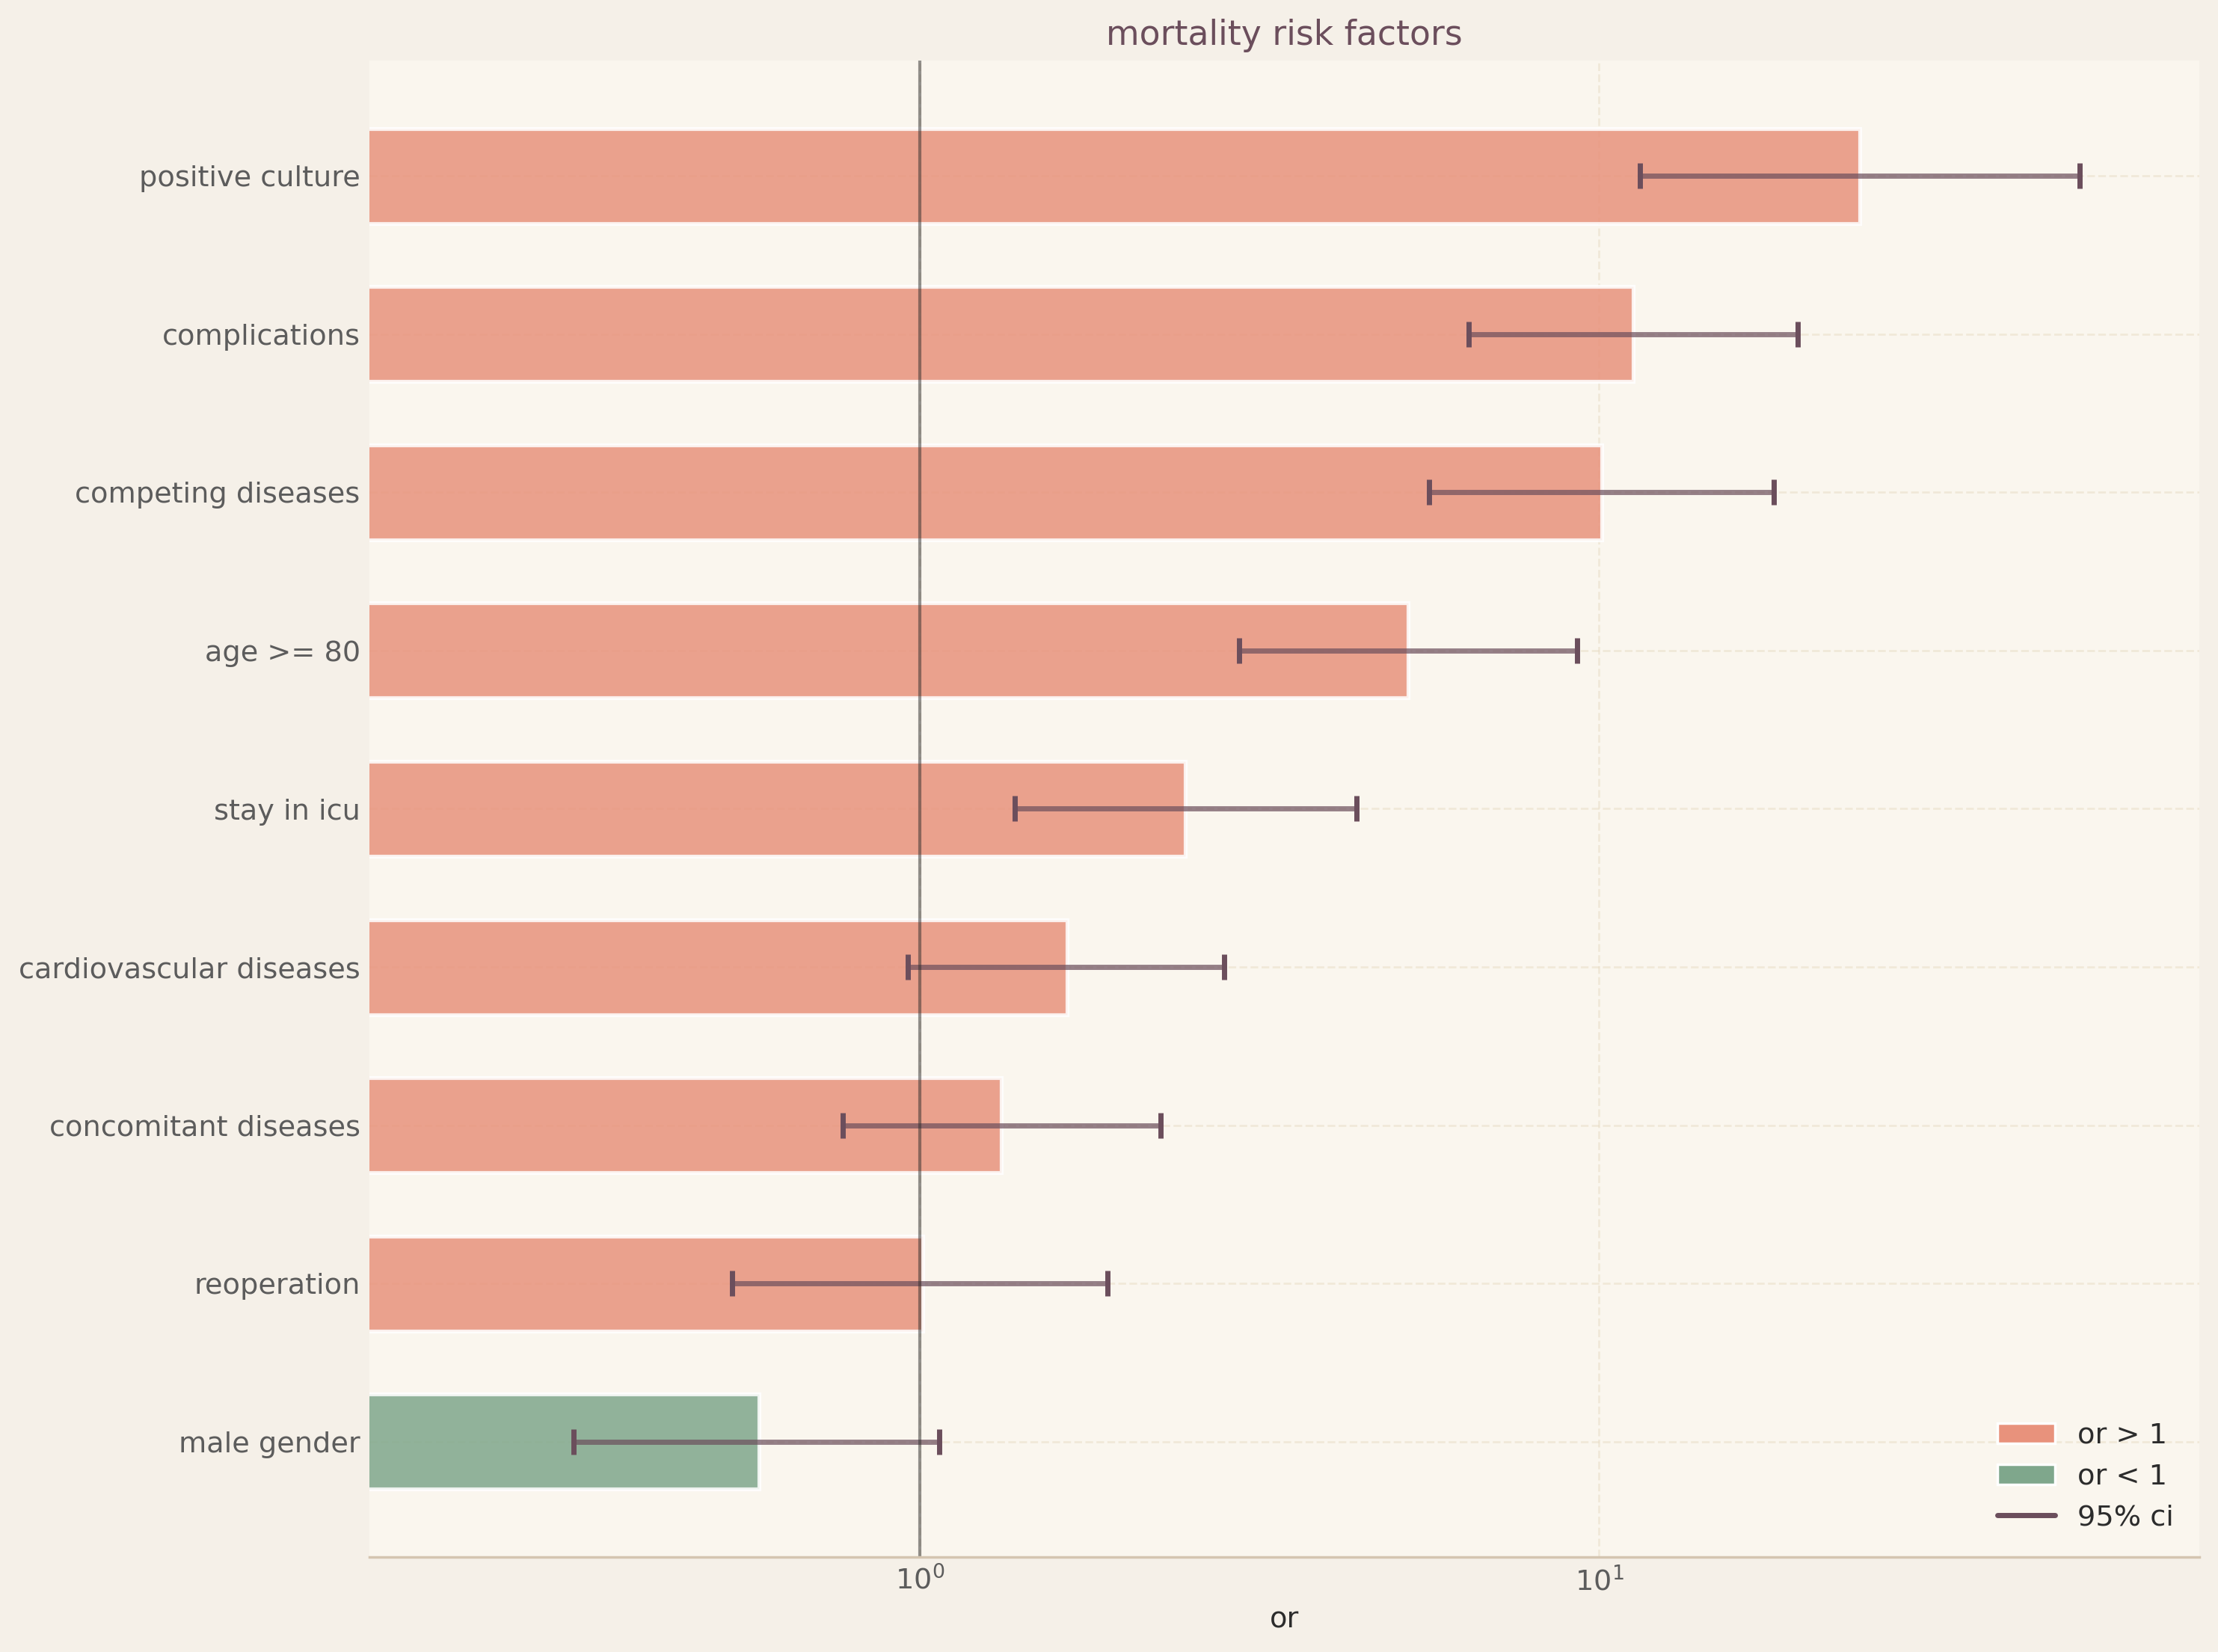


--- longstay_dist.png ---


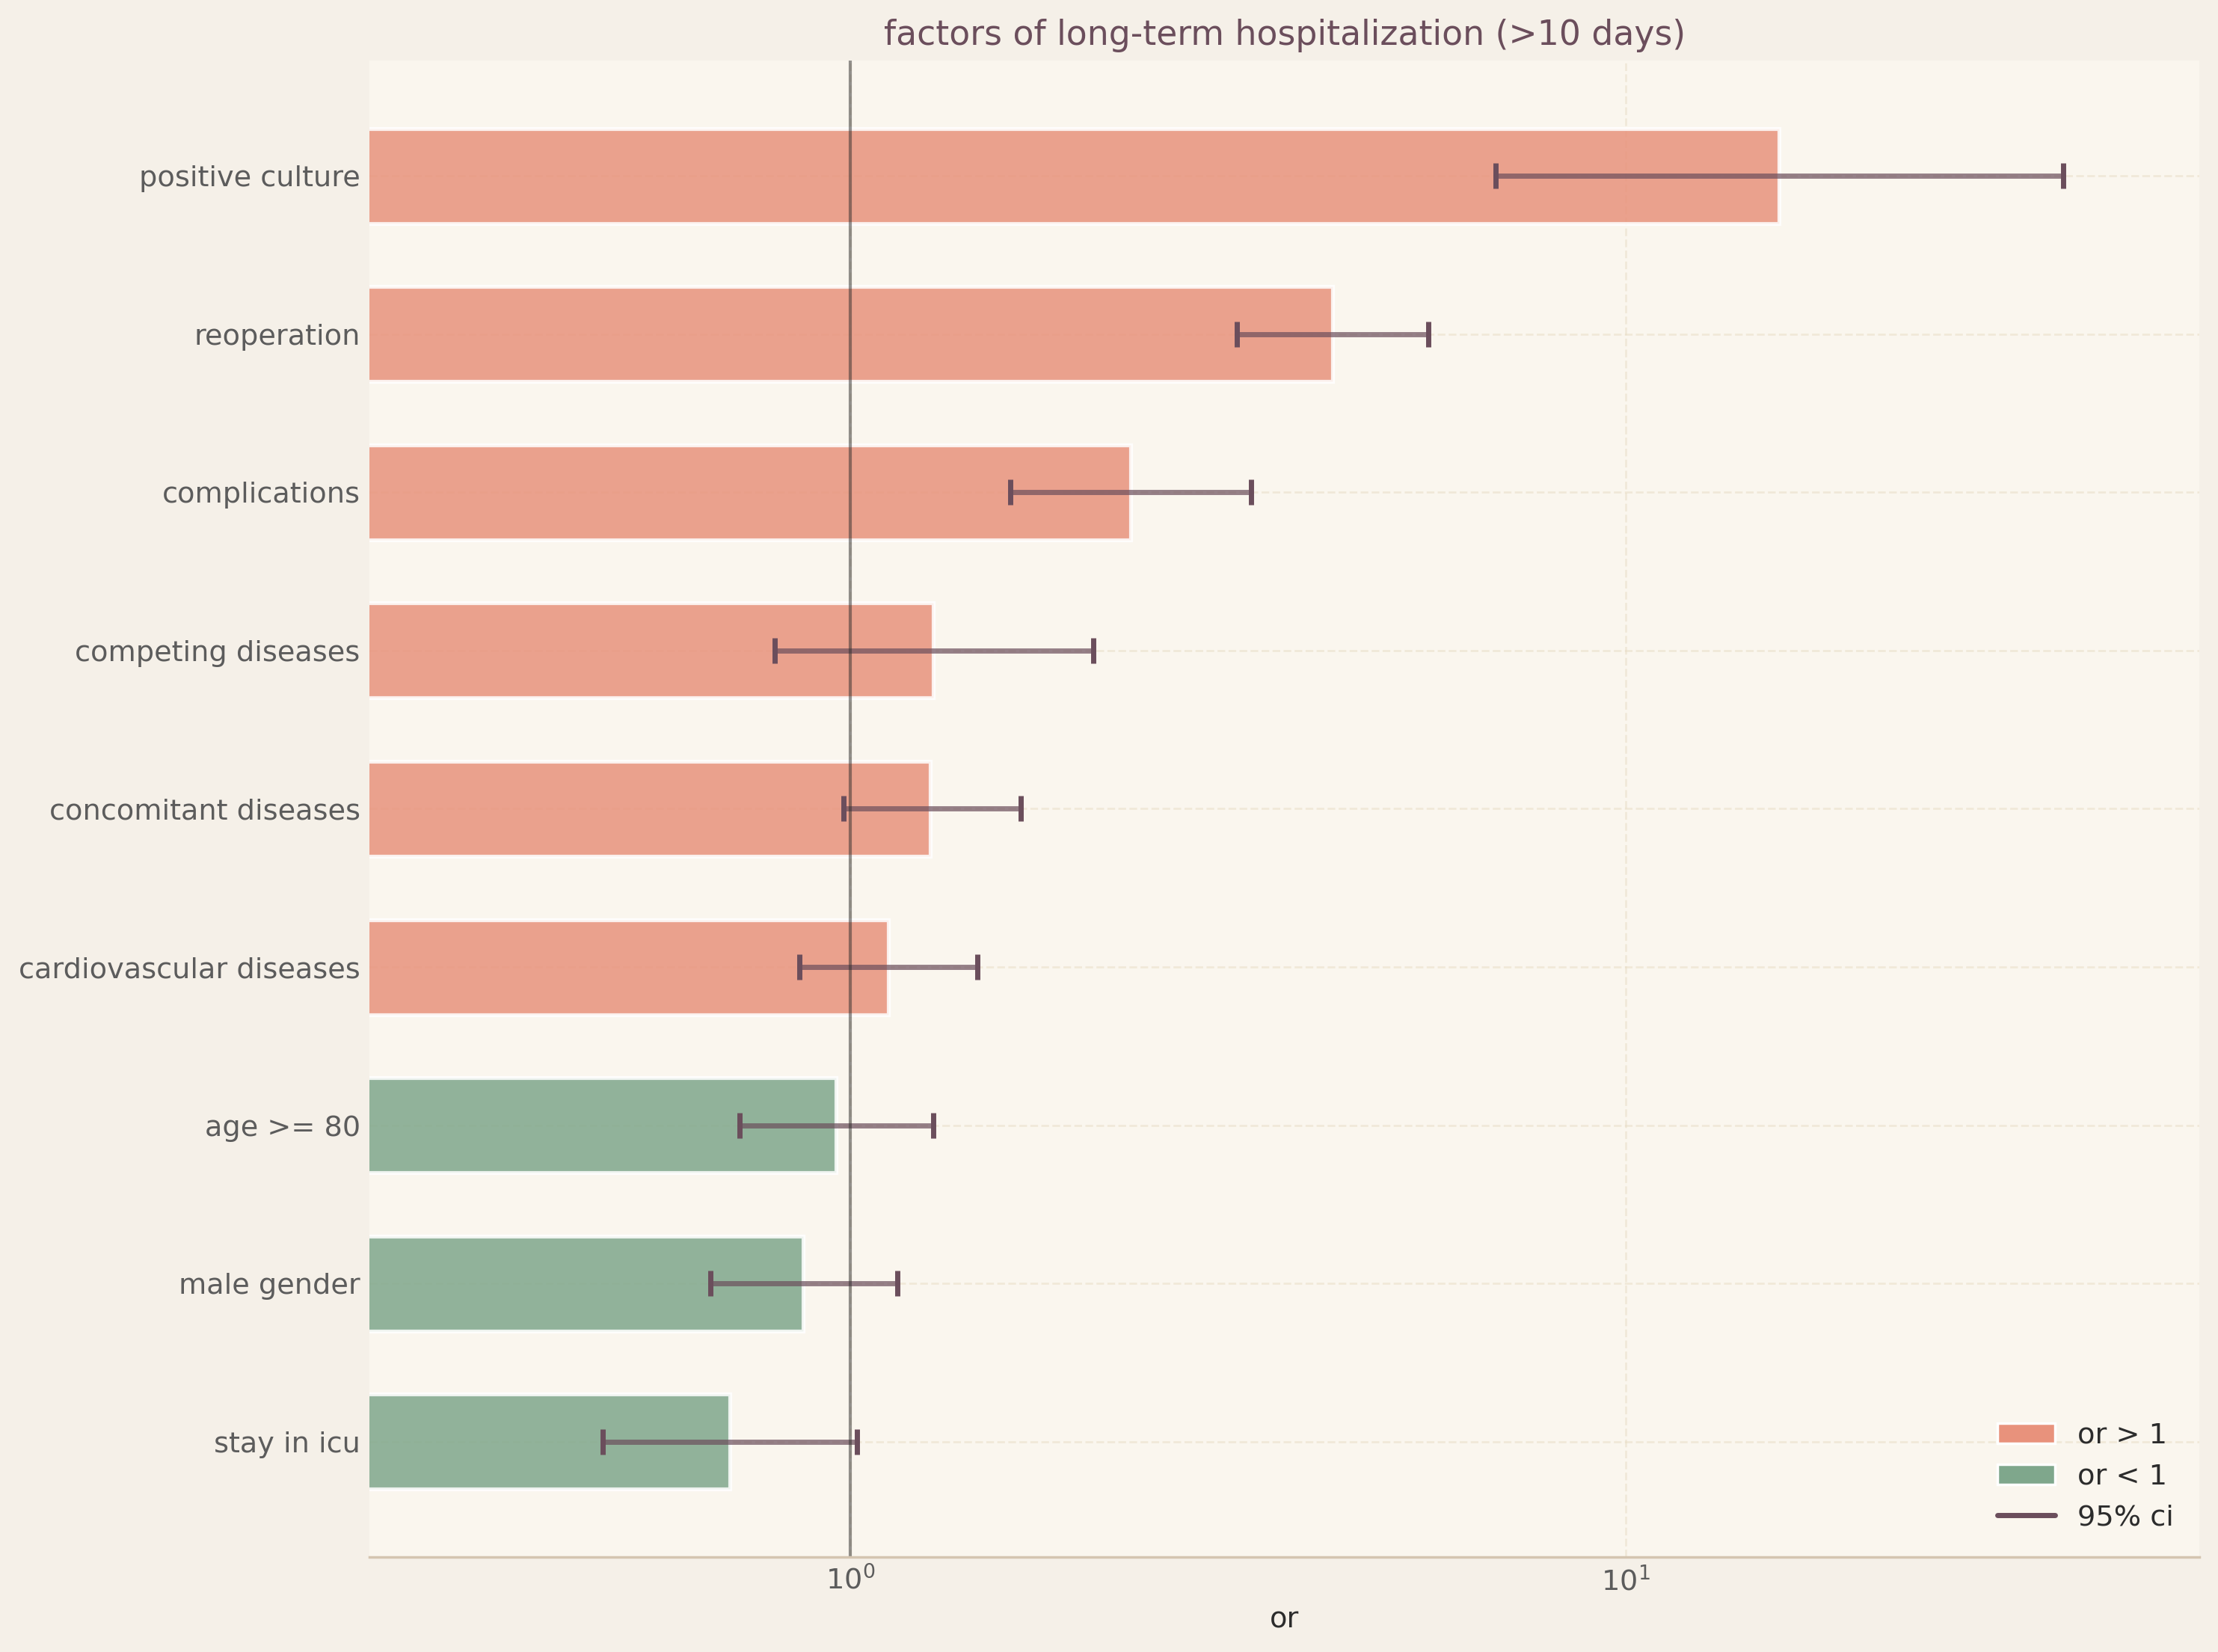


--- forest_mo_mort_dist.png ---


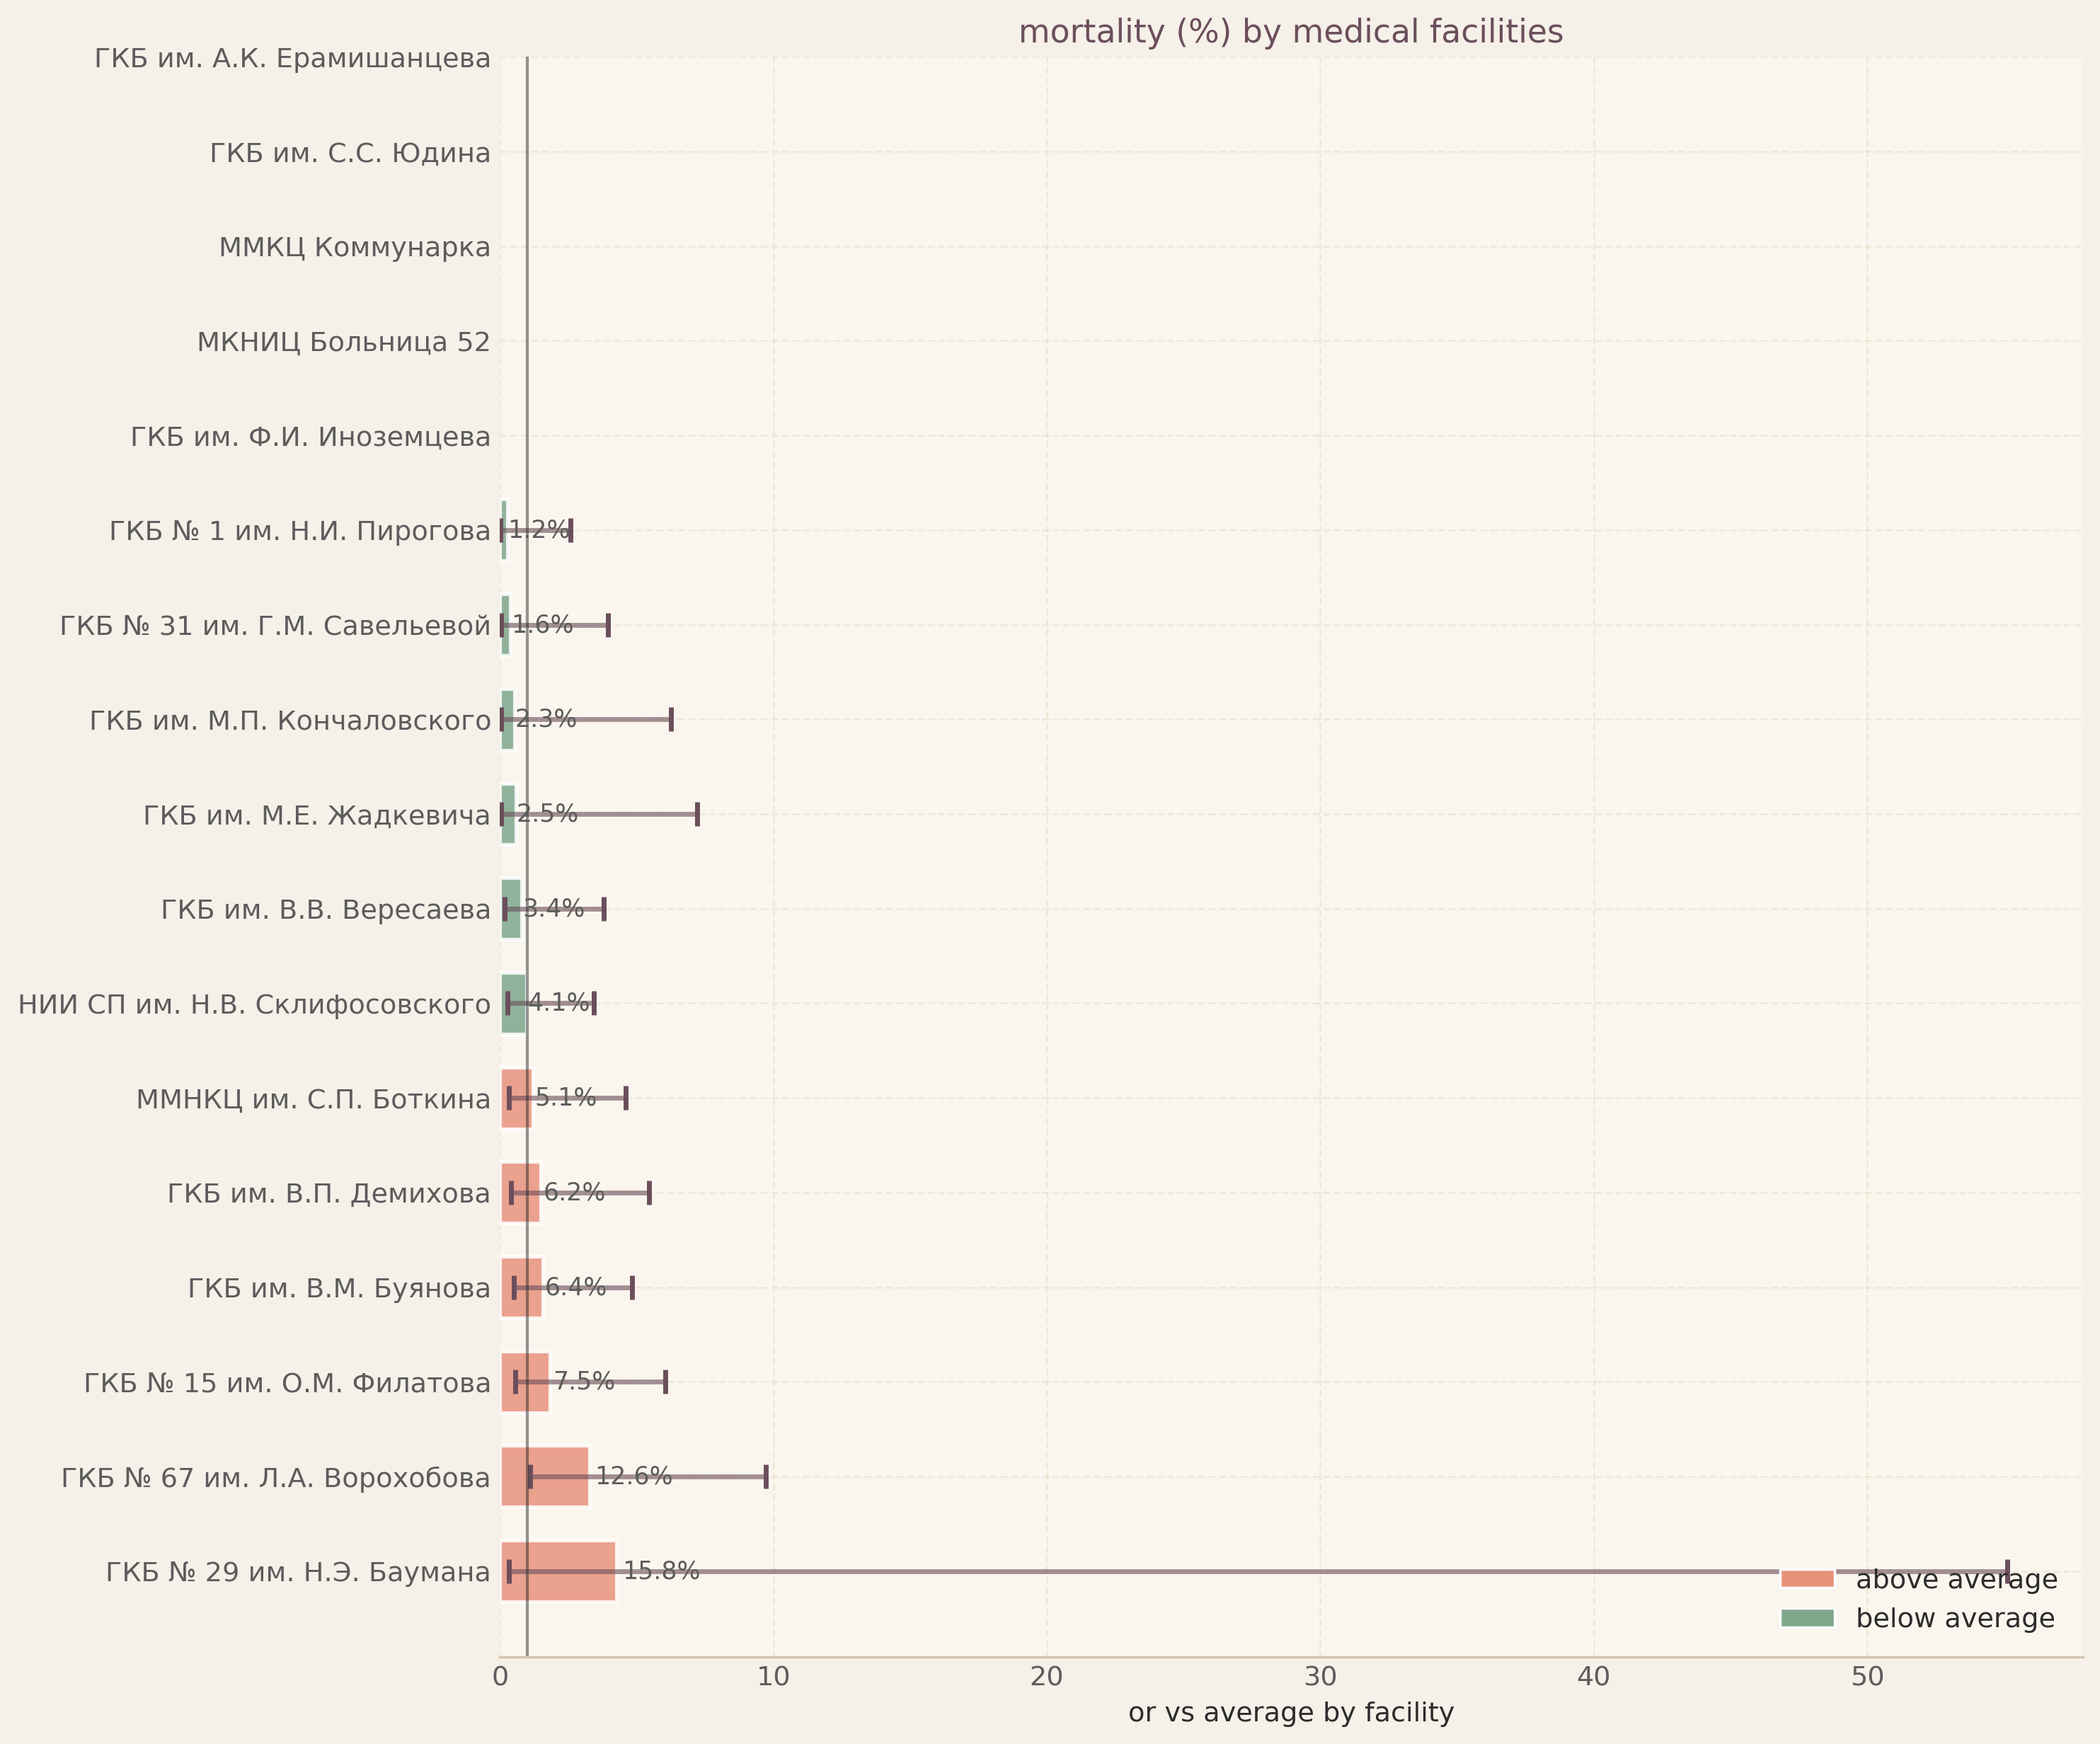


--- forest_mo_ls_dist.png ---


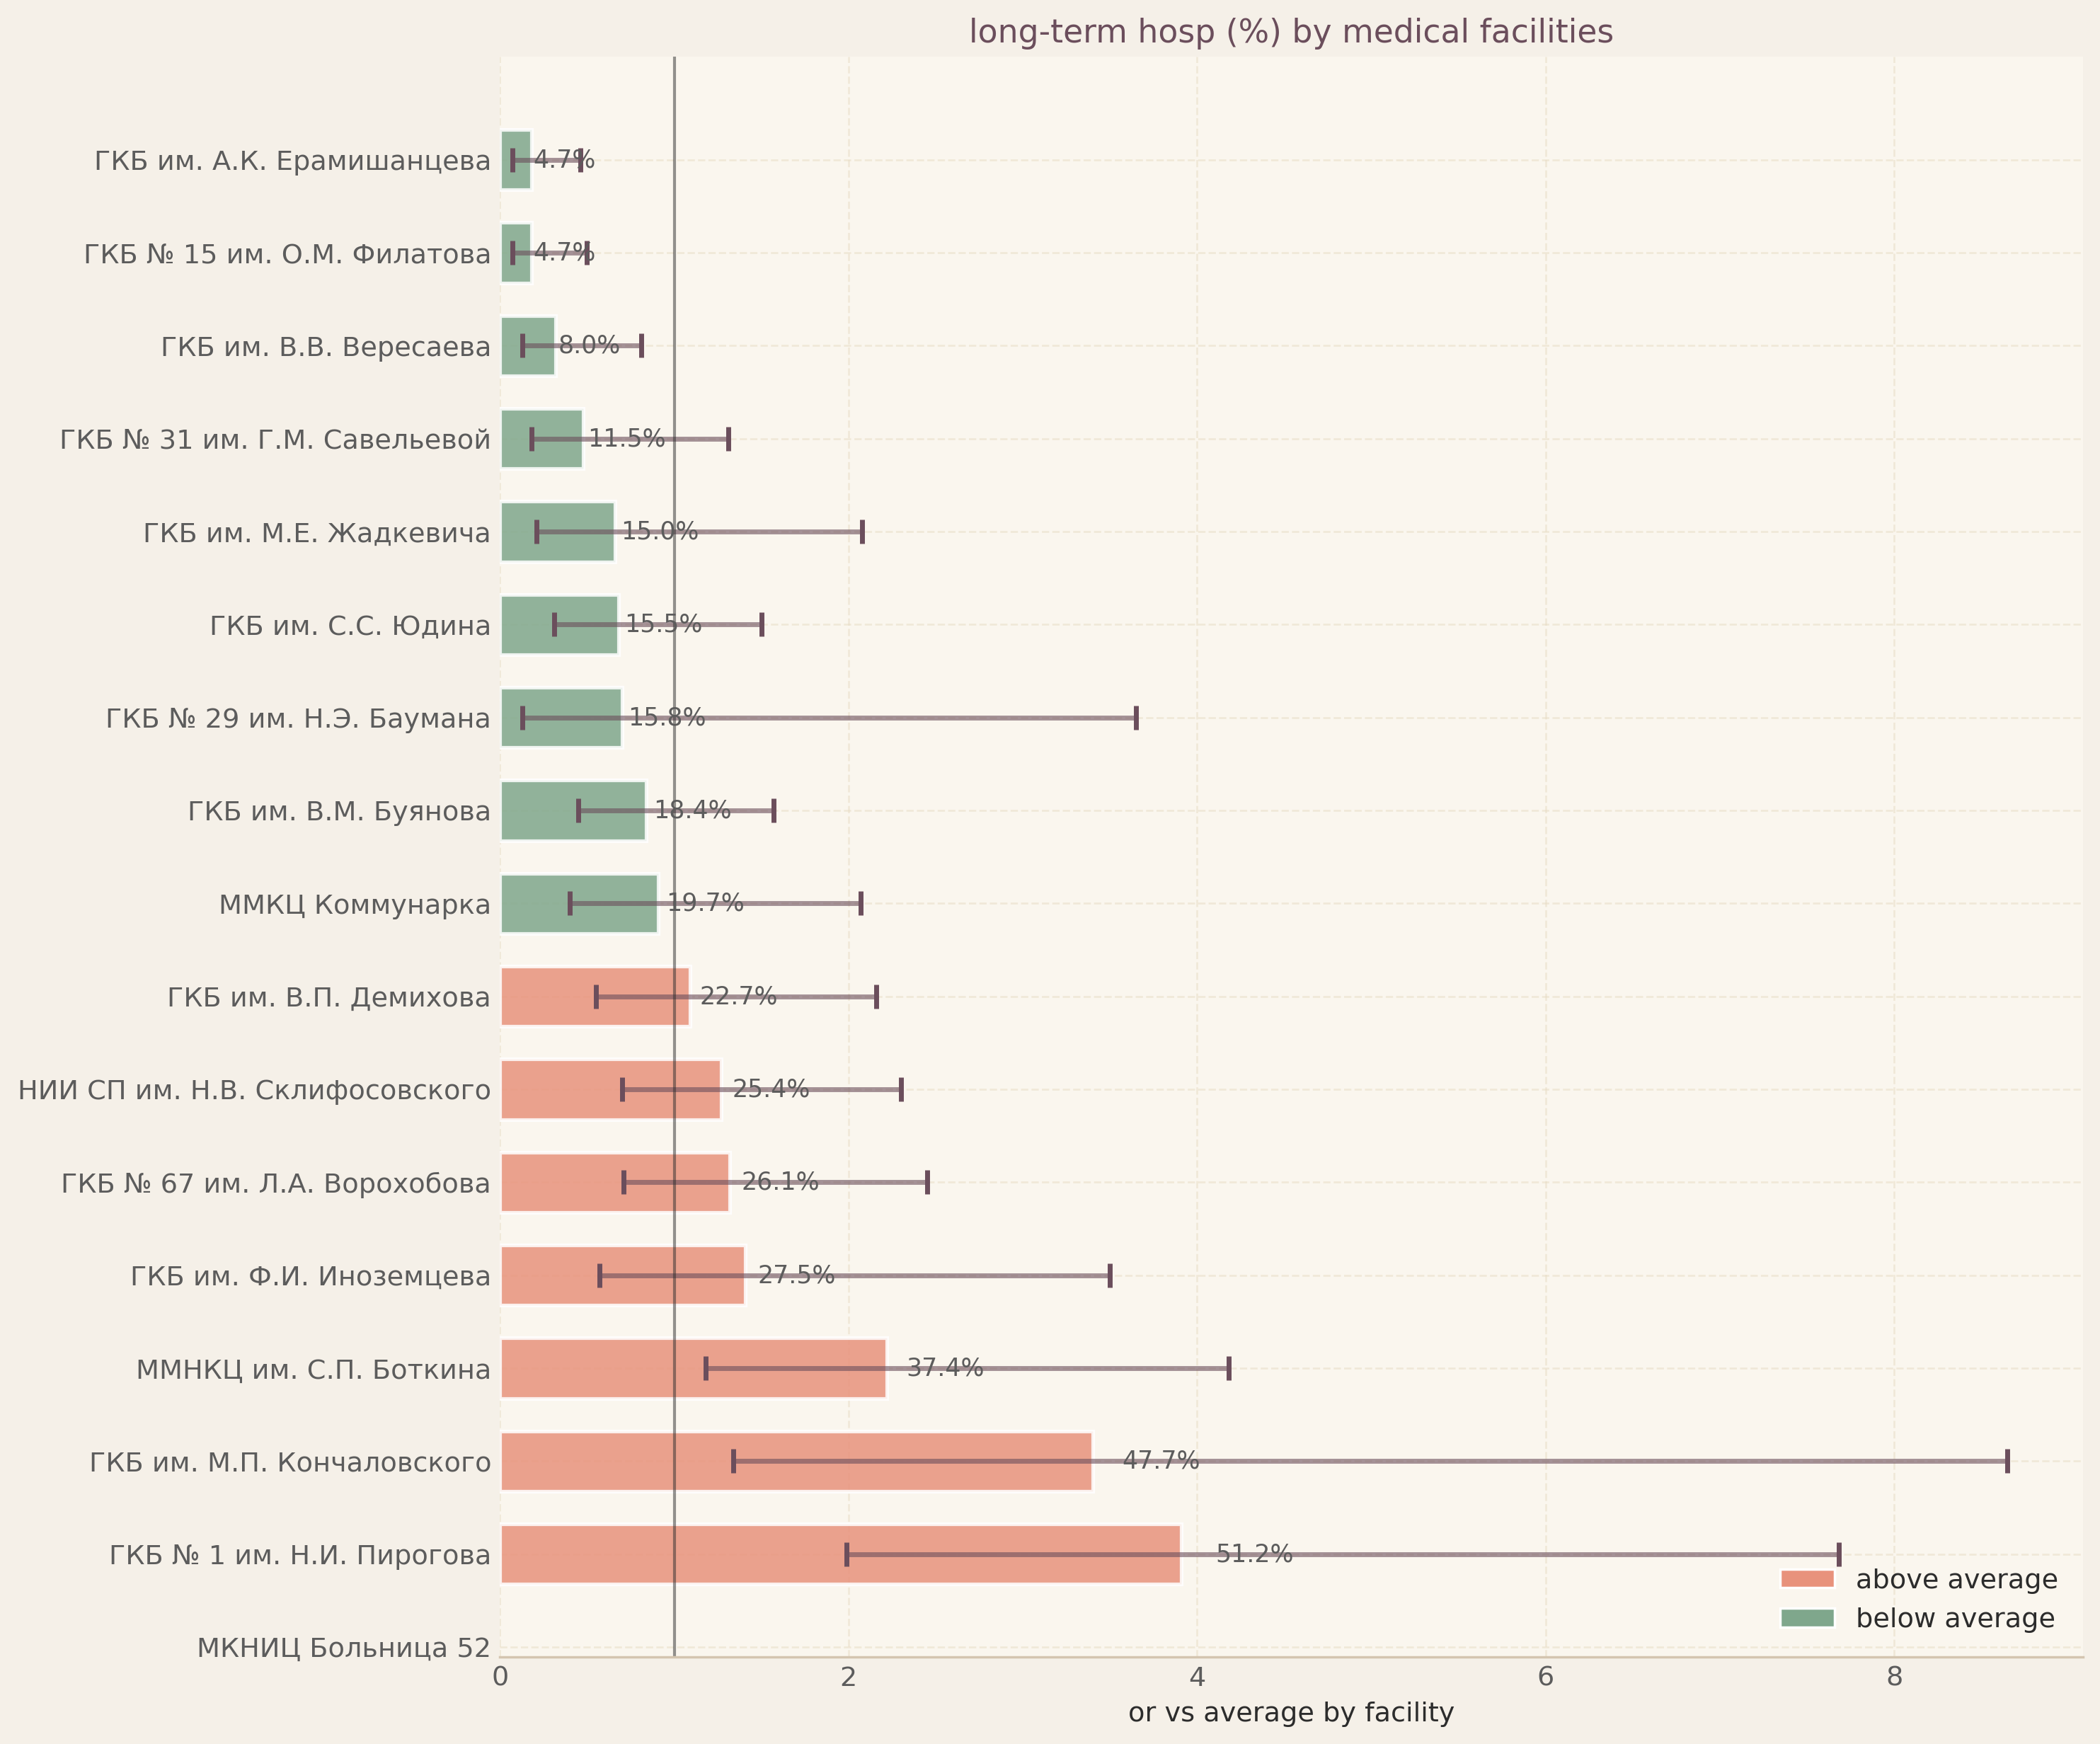


--- heatmap_factors_dist.png ---


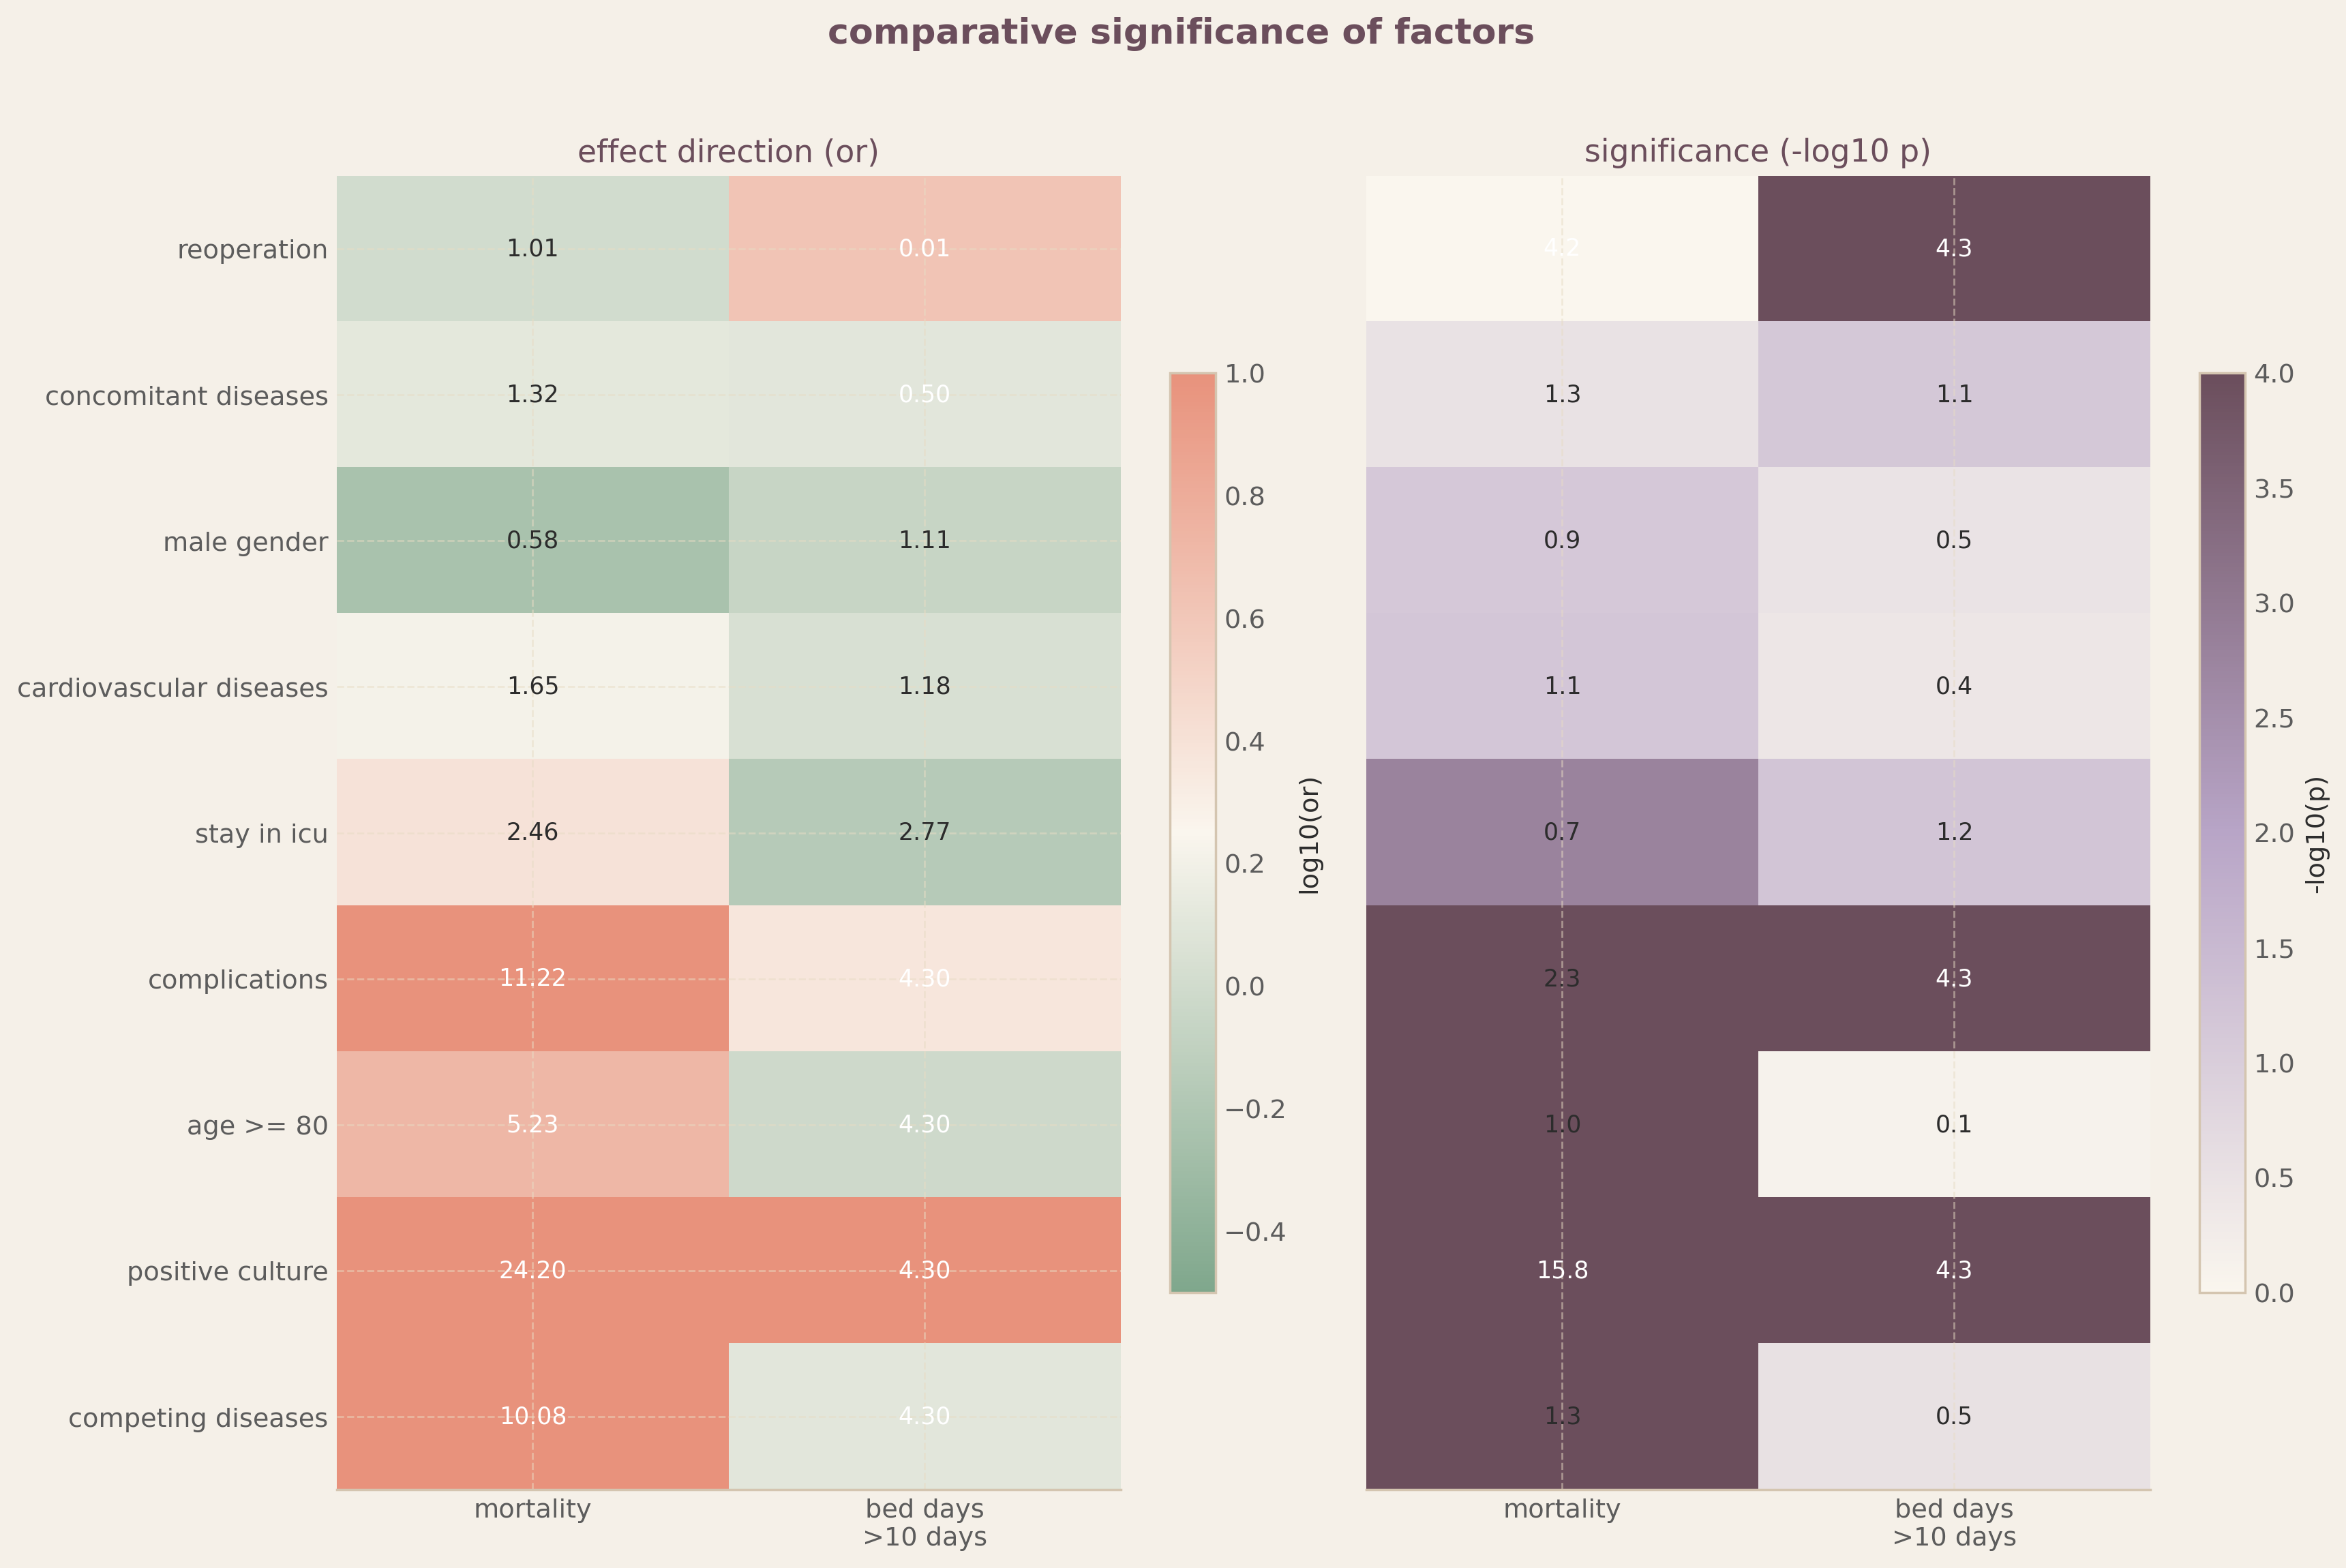

In [56]:
from IPython.display import Image, display

print("displaying saved charts:\n")

for fname in ['mortality_dist.png', 'longstay_dist.png', 'forest_mo_mort_dist.png', 'forest_mo_ls_dist.png', 'heatmap_factors_dist.png']:
    try:
        print(f"--- {fname} ---")
        display(Image(filename=fname))
        print()
    except FileNotFoundError:
        print(f"  file {fname} not found - run the plotting code first\n")

### benjamini-hochberg procedure

In [61]:
# cell 1: imports and helper function

import pandas as pd
import numpy as np
from statsmodels.stats.multitest import multipletests


print("multiple comparison correction: benjamini-hochberg (fdr)")


def apply_bh_correction(df_table, outcome_name, exclude_pattern=None, or_col='or'):
    """
    applies benjamini-hochberg correction to a table of factors.
    
    parameters:
    - df_table: dataframe with factor analysis results
    - outcome_name: name of the outcome (for messages)
    - exclude_pattern: regex pattern to exclude rows from correction (e.g., 'ref\\.' or 'average')
    - or_col: name of the column with OR values
    
    returns:
    - corrected dataframe with added columns 'p-value (adj)' and 'significant (adj)'
    """
    df_work = df_table.copy()
    
    # parse p-values
    def parse_pvalue(p_str):
        if pd.isna(p_str):
            return np.nan
        p_str = str(p_str).strip()
        if p_str.startswith('<'):
            return 0.00005
        try:
            return float(p_str)
        except:
            return np.nan
    
    df_work['_p_num'] = df_work['p-value'].apply(parse_pvalue)
    
    # determine which rows to correct
    if exclude_pattern:
        mask_exclude = df_work['factor'].str.contains(exclude_pattern, na=False, regex=True)
    else:
        mask_exclude = pd.Series([False] * len(df_work), index=df_work.index)
    
    mask_valid = df_work['_p_num'].notna() & ~mask_exclude
    
    print(f"\n--- {outcome_name} ---")
    print(f"   total rows: {len(df_work)}")
    print(f"   rows excluded from correction: {mask_exclude.sum()}")
    print(f"   rows with valid p-value: {mask_valid.sum()}")
    
    if mask_valid.sum() == 0:
        print("   no valid p-values to correct")
        df_work['p-value (adj)'] = '—'
        df_work['significant (adj)'] = 'no'
        df_work = df_work.drop('_p_num', axis=1)
        return df_work
    
    # apply correction
    pvals = df_work.loc[mask_valid, '_p_num'].values
    reject, pvals_corrected, _, _ = multipletests(pvals, alpha=0.05, method='fdr_bh')
    
    # create new columns initialized with '—'
    df_work['p-value (adj)'] = '—'
    df_work['significant (adj)'] = 'no'
    
    # format corrected p-values
    def format_p(p_val):
        if isinstance(p_val, str):
            return p_val
        if pd.isna(p_val):
            return '—'
        if float(p_val) < 0.0001:
            return '<0.0001'
        return f"{float(p_val):.4f}"
    
    # assign corrected values only to valid rows
    for idx, p_corr in zip(df_work[mask_valid].index, pvals_corrected):
        df_work.loc[idx, 'p-value (adj)'] = format_p(p_corr)
        df_work.loc[idx, 'significant (adj)'] = 'yes' if reject[df_work[mask_valid].index.get_loc(idx)] else 'no'
    
    # summary
    n_sig = (df_work['significant (adj)'] == 'yes').sum()
    print(f"   significant after correction: {n_sig} ({n_sig/len(df_work)*100:.1f}%)")
    
    df_work = df_work.drop('_p_num', axis=1)
    return df_work

multiple comparison correction: benjamini-hochberg (fdr)


In [62]:
# cell 2: correction for proximal mortality

# check if proximal tables exist
if 'table_mortality' in dir() and len(table_mortality) > 0:
    print("applying correction to proximal mortality...")
    prox_mort_corrected = apply_bh_correction(
        table_mortality, 
        'proximal mortality',
        exclude_pattern=r'\(ref\.\)|average'
    )
    print("\nsignificant factors (proximal mortality):")
    sig = prox_mort_corrected[prox_mort_corrected['significant (adj)'] == 'yes']
    if len(sig) > 0:
        display(sig[['factor', 'or', '95% ci', 'p-value', 'p-value (adj)', 'significant (adj)']])
    else:
        print("   no significant factors after correction")
else:
    print("proximal mortality table not found - skipping")
    prox_mort_corrected = None

applying correction to proximal mortality...

--- proximal mortality ---
   total rows: 19
   rows excluded from correction: 3
   rows with valid p-value: 16
   significant after correction: 5 (26.3%)

significant factors (proximal mortality):


,factor,or,95% ci,p-value,p-value (adj),significant (adj)
0,age >= 80,5.23,[2.95-9.28],<0.0001,0.0002,yes
2,stay in icu,2.46,[1.38-4.40],0.0017,0.0054,yes
4,complications,11.22,[6.42-19.60],<0.0001,0.0002,yes
6,competing diseases,10.08,[5.62-18.06],<0.0001,0.0002,yes
7,positive culture,24.20,[11.49-50.99],<0.0001,0.0002,yes


In [63]:
# cell 3: correction for proximal long-stay

if 'table_longstay' in dir() and len(table_longstay) > 0:
    print("applying correction to proximal long-stay...")
    prox_stay_corrected = apply_bh_correction(
        table_longstay,
        'proximal long-stay',
        exclude_pattern=r'\(ref\.\)|average'
    )
    print("\nsignificant factors (proximal long-stay):")
    sig = prox_stay_corrected[prox_stay_corrected['significant (adj)'] == 'yes']
    if len(sig) > 0:
        display(sig[['factor', 'or', '95% ci', 'p-value', 'p-value (adj)', 'significant (adj)']])
    else:
        print("   no significant factors after correction")
else:
    print("proximal long-stay table not found - skipping")
    prox_stay_corrected = None

applying correction to proximal long-stay...

--- proximal long-stay ---
   total rows: 19
   rows excluded from correction: 3
   rows with valid p-value: 16
   significant after correction: 4 (21.1%)

significant factors (proximal long-stay):


,factor,or,95% ci,p-value,p-value (adj),significant (adj)
4,complications,2.30,[1.61-3.29],<0.0001,0.0003,yes
7,positive culture,15.78,[6.79-36.64],<0.0001,0.0003,yes
8,reoperation,4.19,[3.15-5.57],<0.0001,0.0003,yes
11,season: summer,0.59,[0.40-0.88],0.0091,0.0364,yes


In [64]:
# cell 4: correction for distal mortality

if 'table_mortality' in dir() and len(table_mortality) > 0:
    print("applying correction to distal mortality...")
    dist_mort_corrected = apply_bh_correction(
        table_mortality,
        'distal mortality',
        exclude_pattern=r'\(ref\.\)|average'
    )
    print("\nsignificant factors (distal mortality):")
    sig = dist_mort_corrected[dist_mort_corrected['significant (adj)'] == 'yes']
    if len(sig) > 0:
        display(sig[['factor', 'or', '95% ci', 'p-value', 'p-value (adj)', 'significant (adj)']])
    else:
        print("   no significant factors after correction")
else:
    print("distal mortality table not found - skipping")
    dist_mort_corrected = None

applying correction to distal mortality...

--- distal mortality ---
   total rows: 19
   rows excluded from correction: 3
   rows with valid p-value: 16
   significant after correction: 5 (26.3%)

significant factors (distal mortality):


,factor,or,95% ci,p-value,p-value (adj),significant (adj)
0,age >= 80,5.23,[2.95-9.28],<0.0001,0.0002,yes
2,stay in icu,2.46,[1.38-4.40],0.0017,0.0054,yes
4,complications,11.22,[6.42-19.60],<0.0001,0.0002,yes
6,competing diseases,10.08,[5.62-18.06],<0.0001,0.0002,yes
7,positive culture,24.20,[11.49-50.99],<0.0001,0.0002,yes


In [65]:
# cell 5: correction for distal long-stay

if 'table_longstay' in dir() and len(table_longstay) > 0:
    print("applying correction to distal long-stay...")
    dist_stay_corrected = apply_bh_correction(
        table_longstay,
        'distal long-stay',
        exclude_pattern=r'\(ref\.\)|average'
    )
    print("\nsignificant factors (distal long-stay):")
    sig = dist_stay_corrected[dist_stay_corrected['significant (adj)'] == 'yes']
    if len(sig) > 0:
        display(sig[['factor', 'or', '95% ci', 'p-value', 'p-value (adj)', 'significant (adj)']])
    else:
        print("   no significant factors after correction")
else:
    print("distal long-stay table not found - skipping")
    dist_stay_corrected = None

applying correction to distal long-stay...

--- distal long-stay ---
   total rows: 19
   rows excluded from correction: 3
   rows with valid p-value: 16
   significant after correction: 4 (21.1%)

significant factors (distal long-stay):


,factor,or,95% ci,p-value,p-value (adj),significant (adj)
4,complications,2.30,[1.61-3.29],<0.0001,0.0003,yes
7,positive culture,15.78,[6.79-36.64],<0.0001,0.0003,yes
8,reoperation,4.19,[3.15-5.57],<0.0001,0.0003,yes
11,season: summer,0.59,[0.40-0.88],0.0091,0.0364,yes


In [66]:
# cell 6: save all corrected tables to excel

output_file = 'correction_results.xlsx'

try:
    with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
        if prox_mort_corrected is not None:
            prox_mort_corrected.to_excel(writer, sheet_name='proximal mortality', index=False)
            print(f"   proximal mortality: {len(prox_mort_corrected)} rows")
        
        if prox_stay_corrected is not None:
            prox_stay_corrected.to_excel(writer, sheet_name='proximal long-stay', index=False)
            print(f"   proximal long-stay: {len(prox_stay_corrected)} rows")
        
        if dist_mort_corrected is not None:
            dist_mort_corrected.to_excel(writer, sheet_name='distal mortality', index=False)
            print(f"   distal mortality: {len(dist_mort_corrected)} rows")
        
        if dist_stay_corrected is not None:
            dist_stay_corrected.to_excel(writer, sheet_name='distal long-stay', index=False)
            print(f"   distal long-stay: {len(dist_stay_corrected)} rows")
    
    print(f"\nall corrected tables saved to: {output_file}")
    
except Exception as e:
    print(f"error saving to excel: {e}")
    print("trying to save as csv...")
    
    if prox_mort_corrected is not None:
        prox_mort_corrected.to_csv('proximal_mortality_corrected.csv', index=False, encoding='utf-8-sig')
    if prox_stay_corrected is not None:
        prox_stay_corrected.to_csv('proximal_longstay_corrected.csv', index=False, encoding='utf-8-sig')
    if dist_mort_corrected is not None:
        dist_mort_corrected.to_csv('distal_mortality_corrected.csv', index=False, encoding='utf-8-sig')
    if dist_stay_corrected is not None:
        dist_stay_corrected.to_csv('distal_longstay_corrected.csv', index=False, encoding='utf-8-sig')
    
    print("csv files saved")

print("\n" + "=" * 70)
print("correction complete")
print("=" * 70)

   proximal mortality: 19 rows
   proximal long-stay: 19 rows
   distal mortality: 19 rows
   distal long-stay: 19 rows

all corrected tables saved to: correction_results.xlsx

correction complete


In [68]:
# cell 7: factors that lost significance after correction

def find_lost_significance(df_corrected, outcome_name):
    """
    finds factors that were significant before correction but not after.
    
    parameters:
    - df_corrected: dataframe with correction applied
    - outcome_name: name of the outcome (for messages)
    
    returns:
    - dataframe with factors that lost significance
    """
    if df_corrected is None or len(df_corrected) == 0:
        return None
    
    df_work = df_corrected.copy()
    
    # parse original p-values
    def parse_pvalue(p_str):
        if pd.isna(p_str):
            return np.nan
        p_str = str(p_str).strip()
        if p_str.startswith('<'):
            return 0.00005
        try:
            return float(p_str)
        except:
            return np.nan
    
    df_work['_p_orig'] = df_work['p-value'].apply(parse_pvalue)
    
    # find factors: significant before (p < 0.05) but not after
    mask_sig_before = df_work['_p_orig'] < 0.05
    mask_not_sig_after = df_work['significant (adj)'] == 'no'
    mask_lost = mask_sig_before & mask_not_sig_after
    
    df_lost = df_work[mask_lost].copy()
    df_lost = df_lost.drop('_p_orig', axis=1)
    
    print(f"\n--- {outcome_name} ---")
    print(f"   factors that lost significance: {len(df_lost)}")
    
    if len(df_lost) > 0:
        display(df_lost[['factor', 'or', '95% ci', 'p-value', 'p-value (adj)', 'significant (adj)']])
    
    return df_lost

# apply to all tables

print("factors that lost significance after benjamini-hochberg correction")


prox_mort_lost = find_lost_significance(prox_mort_corrected, 'proximal mortality')
prox_stay_lost = find_lost_significance(prox_stay_corrected, 'proximal long-stay')
dist_mort_lost = find_lost_significance(dist_mort_corrected, 'distal mortality')
dist_stay_lost = find_lost_significance(dist_stay_corrected, 'distal long-stay')

# summary

print("summary")

print(f"   proximal mortality: {len(prox_mort_lost) if prox_mort_lost is not None else 0} factors lost significance")
print(f"   proximal long-stay: {len(prox_stay_lost) if prox_stay_lost is not None else 0} factors lost significance")
print(f"   distal mortality: {len(dist_mort_lost) if dist_mort_lost is not None else 0} factors lost significance")
print(f"   distal long-stay: {len(dist_stay_lost) if dist_stay_lost is not None else 0} factors lost significance")

# save to excel
output_file = 'factors_lost_significance.xlsx'

try:
    with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
        if prox_mort_lost is not None and len(prox_mort_lost) > 0:
            prox_mort_lost.to_excel(writer, sheet_name='proximal mortality', index=False)
        if prox_stay_lost is not None and len(prox_stay_lost) > 0:
            prox_stay_lost.to_excel(writer, sheet_name='proximal long-stay', index=False)
        if dist_mort_lost is not None and len(dist_mort_lost) > 0:
            dist_mort_lost.to_excel(writer, sheet_name='distal mortality', index=False)
        if dist_stay_lost is not None and len(dist_stay_lost) > 0:
            dist_stay_lost.to_excel(writer, sheet_name='distal long-stay', index=False)
    
    print(f"\nresults saved to: {output_file}")
    
except Exception as e:
    print(f"error saving to excel: {e}")


print("done")


factors that lost significance after benjamini-hochberg correction

--- proximal mortality ---
   factors that lost significance: 0

--- proximal long-stay ---
   factors that lost significance: 0

--- distal mortality ---
   factors that lost significance: 0

--- distal long-stay ---
   factors that lost significance: 0
summary
   proximal mortality: 0 factors lost significance
   proximal long-stay: 0 factors lost significance
   distal mortality: 0 factors lost significance
   distal long-stay: 0 factors lost significance
error saving to excel: At least one sheet must be visible
done
